# **Introduction**

**Describe the types of tasks for which recurrent neural networks are useful**

Recurrent Neural Networks (RNNs) are designed for **sequential data**, where order, context, and dependencies over time (or position) matter. Unlike feedforward networks, RNNs maintain a hidden state that carries information from previous steps.

### **Give 2 examples of one-to-many, many-to-many, and many-to-one formulations of the problem**

| Task Type                                     | Input → Output                     | Example 1                                              | Example 2                                                   |
| --------------------------------------------- | ---------------------------------- | ------------------------------------------------------ | ----------------------------------------------------------- |
| 🔁 **Sequence → Sequence (different length)** | Sequence → Sequence (T_in ≠ T_out) | **Machine Translation**<br>“I love AI” → “J’aime l’IA” | **Summarization**<br>Long article → short summary           |
| 📝 **Sequence → One (Many-to-One)**           | Sequence → Single label            | **Sentiment Analysis**<br>“Great movie!” → Positive    | **Spam Detection**<br>Email → Spam / Not spam               |
| 🔤 **One → Sequence (One-to-Many)**           | Single input → Sequence            | **Image Captioning**<br>Image → “A dog running”        | **Music Generation (seed)**<br>“C” → “C E G A…”             |
| 🔄 **Sequence → Sequence (same length)**      | Sequence → Sequence (aligned)      | **POS Tagging**<br>“Dog runs” → (NOUN, VERB)           | **NER**<br>“John lives in Paris” → (PERSON, O, O, LOCATION) |
| ⏳ **Time Series Prediction**                  | Past sequence → Future value(s)    | **Stock Forecasting**<br>[100,102,101] → 103           | **Temperature Prediction**<br>Past 24h → next hour          |
| 🗣️ **Speech & Audio Processing**             | Audio sequence → Text/Label        | **Speech Recognition**<br>Audio → “hello”              | **Speaker ID**<br>Voice → “Speaker A”                       |
| 🧬 **Biological Sequences**                   | Sequence → Label / Sequence        | **DNA Classification**<br>“ATCG…” → Gene               | **Protein Structure**<br>Sequence → Helix/Sheet/Coil        |
| 🎵 **Generative Sequence Modeling**           | Partial sequence → Next sequence   | **Text Generation**<br>“The sky is” → “blue…”          | **Code Generation**<br>`def add(a,b):` → `return a+b`       |


###  **Imagine you have an RNN that classifies the language of incoming words. Illustrate (in Paint, Drawio, etc.) with blocks how this model will process the word "Hello". Draw each input and output. Define each block with its parameters. Illustrate what the initial value of the hidden state will be**

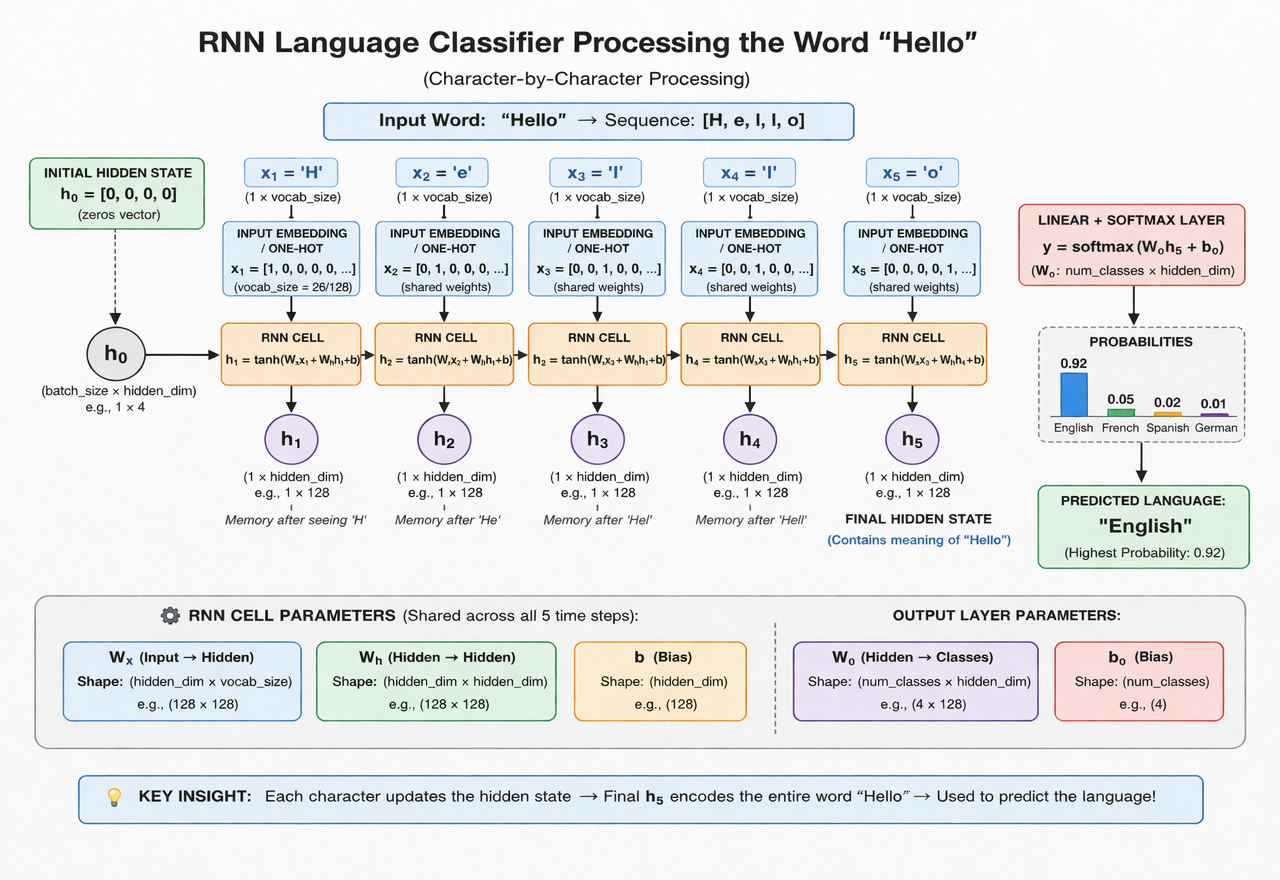

### **Explain the main difference between vanilla RNN, LSTM, and GRU. Draw LSTM or GRU similar to RNN**

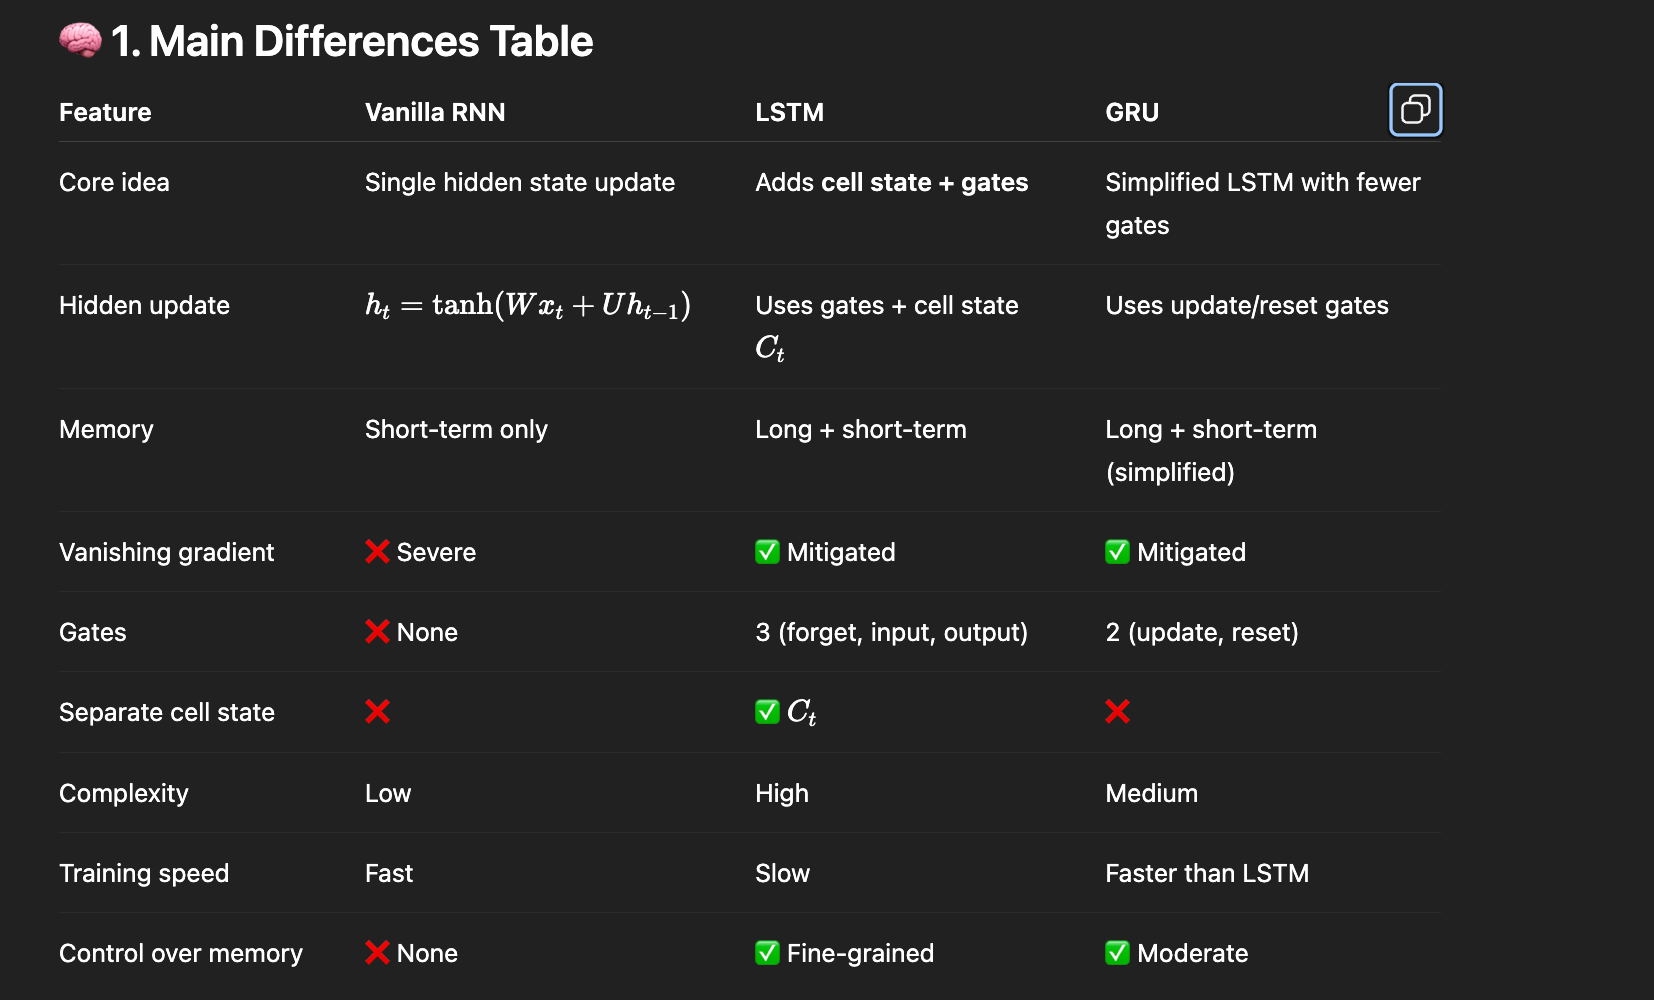

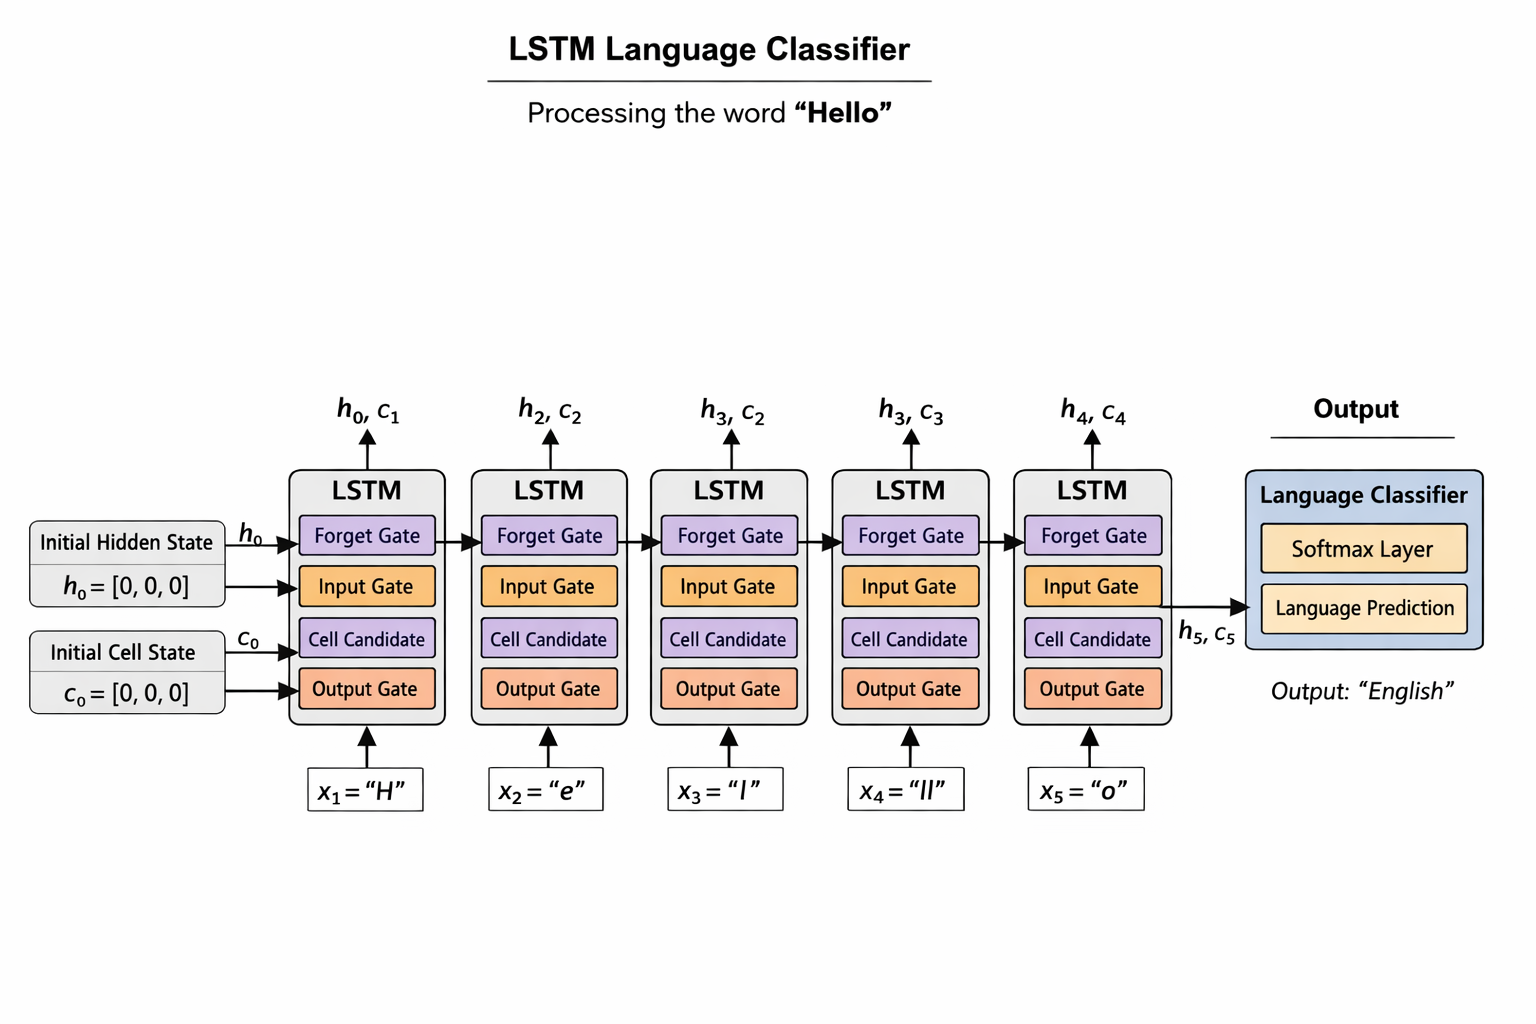

# **Data Analysis**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
gender_data = pd.read_csv('./data/babynames-clean.csv', header=None)
gender_data = gender_data.rename(columns={0 : 'Name'})
gender_data = gender_data.rename(columns={1 : 'Gender'})

In [3]:
gender_data['letters'] = gender_data['Name'].str.lower()
gender_data['letters'] = gender_data['letters'].str.split(pat = '')

In [4]:
remove = ['', ' ']
for i in range(len(gender_data)):
    new_lst = gender_data.iloc[i, 2]
    lst = [elem for elem in new_lst if elem not in remove]
    gender_data.at[i, 'letters'] = lst


In [5]:
gender_data['name_length'] = None

In [6]:
for i in range(len(gender_data)):
    gender_data.at[i, 'name_length']= len(gender_data['letters'][i])

In [7]:
gender_data

,Name,Gender,letters,name_length
0,John,boy,"[j, o, h, n]",4
1,William,boy,"[w, i, l, l, i, a, m]",7
2,James,boy,"[j, a, m, e, s]",5
3,Charles,boy,"[c, h, a, r, l, e, s]",7
4,George,boy,"[g, e, o, r, g, e]",6
...,...,...,...,...
6777,Laylah,girl,"[l, a, y, l, a, h]",6
6778,Carleigh,girl,"[c, a, r, l, e, i, g, h]",8
6779,Kenley,girl,"[k, e, n, l, e, y]",6
6780,Sloane,girl,"[s, l, o, a, n, e]",6


**Name length**

<Axes: xlabel='name_length', ylabel='Count'>

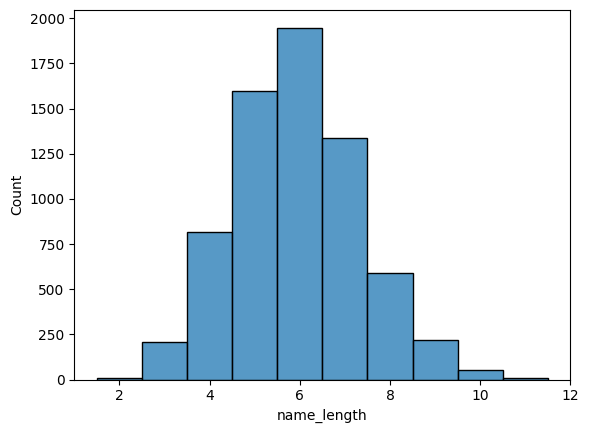

In [8]:
sns.histplot(gender_data['name_length'], stat = 'count', discrete=True)

mode = 6
min = 2
max = 11

**Gender balance**

<Axes: xlabel='Gender', ylabel='Count'>

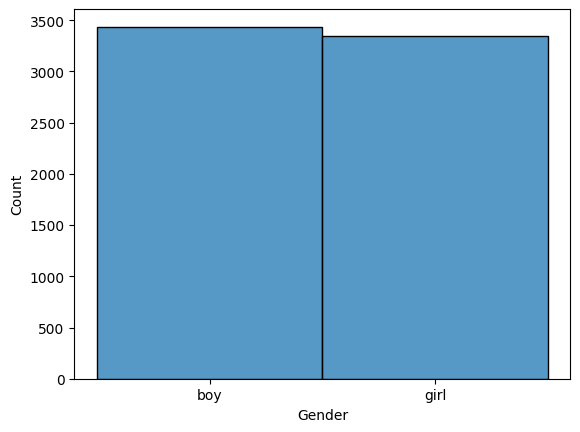

In [9]:
sns.histplot(gender_data['Gender'], stat = 'count', discrete=True)

In [10]:
gender_data['Gender'].value_counts()

,count
Gender,
boy,3437
girl,3345


**frequency of each letter**

In [11]:
alphabet = np.array(list('abcdefghijklmnopqrstuvwxyz'))

def count_letters(lst):
    return [(np.array(lst) == letter).sum() for letter in alphabet]

counts = gender_data['letters'].apply(count_letters)

counts_df = pd.DataFrame(counts.tolist(), columns=alphabet)

gender_data = pd.concat([gender_data, counts_df], axis=1)

In [12]:
counts

,letters
0,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, ..."
1,"[1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, 0, 0, ..."
2,"[1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, ..."
3,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, ..."
4,"[0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, ..."
...,...
6777,"[2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, ..."
6778,"[1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, ..."
6779,"[0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, ..."
6780,"[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, ..."


In [13]:
letters_count = {}
alphabet = 'abcdefghijklmnopqrstuvwxyz'

for letter in alphabet:
    letters_count[letter] = np.array(gender_data[letter]).sum()

In [14]:
letters_count

{'a': np.int64(5593),
 'b': np.int64(673),
 'c': np.int64(1063),
 'd': np.int64(1532),
 'e': np.int64(5038),
 'f': np.int64(302),
 'g': np.int64(526),
 'h': np.int64(1206),
 'i': np.int64(3264),
 'j': np.int64(502),
 'k': np.int64(616),
 'l': np.int64(3255),
 'm': np.int64(1245),
 'n': np.int64(3524),
 'o': np.int64(2071),
 'p': np.int64(265),
 'q': np.int64(61),
 'r': np.int64(3070),
 's': np.int64(1674),
 't': np.int64(1745),
 'u': np.int64(707),
 'v': np.int64(490),
 'w': np.int64(271),
 'x': np.int64(71),
 'y': np.int64(1243),
 'z': np.int64(199)}

In [15]:
categories = list(letters_count.keys())
counts = list(letters_count.values())

<BarContainer object of 26 artists>

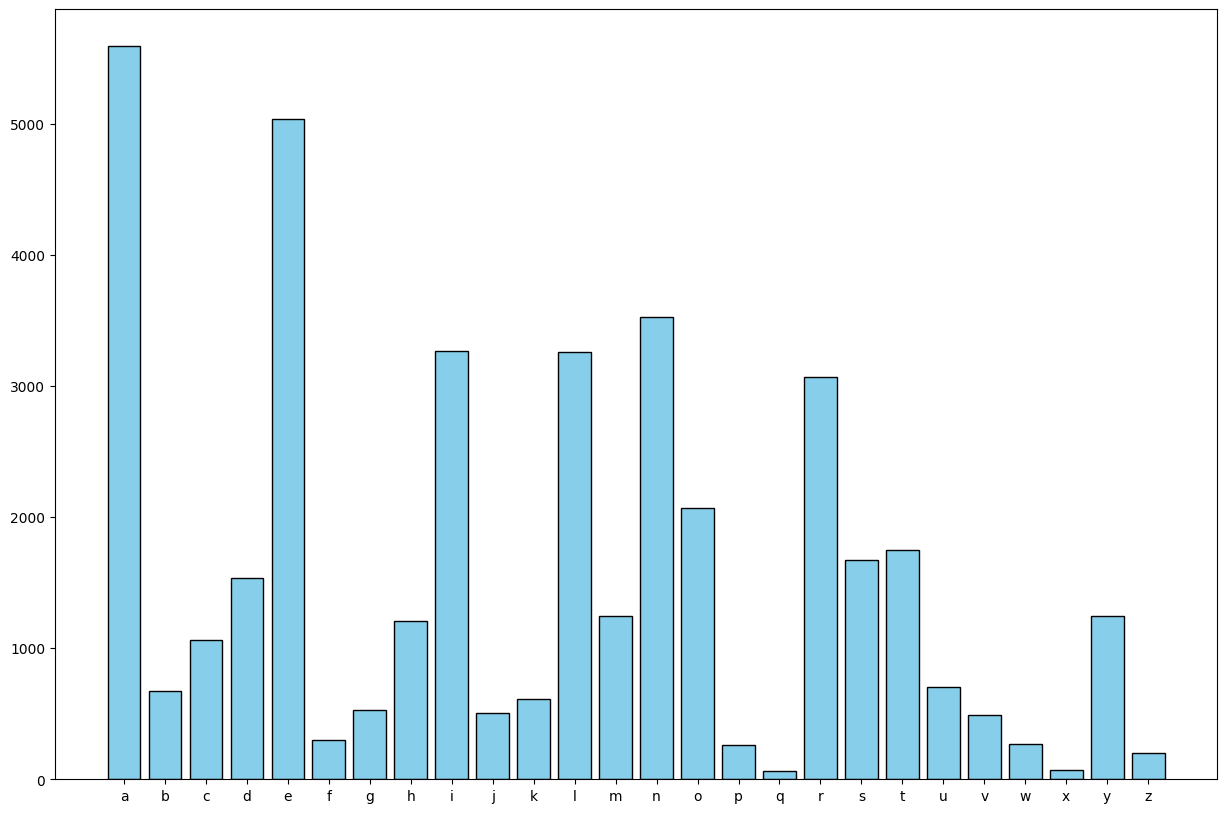

In [16]:
plt.figure(figsize=(15, 10))
plt.bar(categories, counts, color='skyblue', edgecolor='black')

In [17]:
gender_data.drop(columns=list(alphabet), inplace=True)

# **Data preparation**

In [18]:
gender_data

,Name,Gender,letters,name_length
0,John,boy,"[j, o, h, n]",4
1,William,boy,"[w, i, l, l, i, a, m]",7
2,James,boy,"[j, a, m, e, s]",5
3,Charles,boy,"[c, h, a, r, l, e, s]",7
4,George,boy,"[g, e, o, r, g, e]",6
...,...,...,...,...
6777,Laylah,girl,"[l, a, y, l, a, h]",6
6778,Carleigh,girl,"[c, a, r, l, e, i, g, h]",8
6779,Kenley,girl,"[k, e, n, l, e, y]",6
6780,Sloane,girl,"[s, l, o, a, n, e]",6


In [19]:
def coding(gender):
  return float(gender == 'boy')

gender_data['gen_code'] = gender_data['Gender'].apply(coding)

In [20]:
gender_data['Name'] = gender_data['Name'].str.lower()

In [21]:
gender_data

,Name,Gender,letters,name_length,gen_code
0,john,boy,"[j, o, h, n]",4,1.0
1,william,boy,"[w, i, l, l, i, a, m]",7,1.0
2,james,boy,"[j, a, m, e, s]",5,1.0
3,charles,boy,"[c, h, a, r, l, e, s]",7,1.0
4,george,boy,"[g, e, o, r, g, e]",6,1.0
...,...,...,...,...,...
6777,laylah,girl,"[l, a, y, l, a, h]",6,0.0
6778,carleigh,girl,"[c, a, r, l, e, i, g, h]",8,0.0
6779,kenley,girl,"[k, e, n, l, e, y]",6,0.0
6780,sloane,girl,"[s, l, o, a, n, e]",6,0.0


In [22]:
max_length = gender_data['name_length'].max() + 2

In [23]:
tokens = [' ', '<SOS>', '<EOS>']
tokens.extend(list(alphabet))

In [24]:
tokens

[' ',
 '<SOS>',
 '<EOS>',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [25]:
tokens_to_id = {tok: i for i, tok in enumerate(tokens)}

In [26]:
id_to_tokens = {i: tok for tok, i in tokens_to_id.items()}

In [27]:
id_to_tokens

{0: ' ',
 1: '<SOS>',
 2: '<EOS>',
 3: 'a',
 4: 'b',
 5: 'c',
 6: 'd',
 7: 'e',
 8: 'f',
 9: 'g',
 10: 'h',
 11: 'i',
 12: 'j',
 13: 'k',
 14: 'l',
 15: 'm',
 16: 'n',
 17: 'o',
 18: 'p',
 19: 'q',
 20: 'r',
 21: 's',
 22: 't',
 23: 'u',
 24: 'v',
 25: 'w',
 26: 'x',
 27: 'y',
 28: 'z'}

In [28]:
names = np.array(gender_data['Name'])

In [29]:
gender_data

,Name,Gender,letters,name_length,gen_code
0,john,boy,"[j, o, h, n]",4,1.0
1,william,boy,"[w, i, l, l, i, a, m]",7,1.0
2,james,boy,"[j, a, m, e, s]",5,1.0
3,charles,boy,"[c, h, a, r, l, e, s]",7,1.0
4,george,boy,"[g, e, o, r, g, e]",6,1.0
...,...,...,...,...,...
6777,laylah,girl,"[l, a, y, l, a, h]",6,0.0
6778,carleigh,girl,"[c, a, r, l, e, i, g, h]",8,0.0
6779,kenley,girl,"[k, e, n, l, e, y]",6,0.0
6780,sloane,girl,"[s, l, o, a, n, e]",6,0.0


In [30]:
def encoding(name, tokens_to_id, max_length):
  tokens = ['<SOS>']+list(name)+['<EOS>']
  tokens += [' ']*(max_length-len(tokens))
  return([tokens_to_id[t] for t in tokens])

encoded_names = [encoding(name, tokens_to_id, max_length) for name in names]

In [31]:
def name_extender(name):
  return '<SOS>'+name+'<EOS>'+(' '*(max_length-len(name)-2))

gender_data['Name'] = gender_data['Name'].apply(name_extender)

In [32]:
gender_data['encoded_names'] = encoded_names

In [33]:
train_data, test_val_data = train_test_split(gender_data, test_size=0.2, train_size=0.8)

In [34]:
test_data, val_data =  train_test_split(test_val_data, test_size=0.5, train_size=0.5)

In [ ]:
train_data.to_csv('./data/train_data.csv')
val_data.to_csv('./data/val_data.csv')
test_data.to_csv('./data/test_data.csv')

In [ ]:
gender_data.to_csv('./data/gender_data.csv')

#  **DataSet wrapping**

In [37]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [38]:
import torch
import torch.nn as nn

In [39]:
from ast import literal_eval

In [40]:
class CustomDataset(Dataset):
  def __init__(self, src_file):
    self.gender_data = pd.read_csv(src_file, converters={'encoded_names': literal_eval})[['encoded_names', 'gen_code']]

  def __len__(self):
    return len(self.gender_data)

  def __getitem__(self, idx):
    feature = torch.tensor(self.gender_data['encoded_names'][idx], dtype=torch.float32)
    label = torch.tensor(self.gender_data['gen_code'][idx], dtype=torch.float32)
    return feature, label


In [ ]:
dataset_train = CustomDataset(src_file='./data/train_data.csv')
dataset_val = CustomDataset(src_file='./data/val_data.csv')
dataset_test = CustomDataset(src_file='./data/test_data.csv')

In [42]:
dataset_train[0]

(tensor([ 1., 21.,  3., 16., 22., 11., 16., 17.,  2.,  0.,  0.,  0.,  0.]),
 tensor(1.))

In [43]:
train_dataloader = DataLoader(dataset_train, batch_size=32, shuffle=True)
validation_dataloader = DataLoader(dataset_val, batch_size=32, shuffle=True)
test_dataloader = DataLoader(dataset_train, batch_size=32, shuffle=True)

In [44]:
next(iter(train_dataloader))

[tensor([[ 1., 21.,  3., 14., 17., 15.,  7.,  2.,  0.,  0.,  0.,  0.,  0.],
         [ 1., 12., 17., 27.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 1., 12.,  7., 20.,  3., 14.,  6., 11., 16.,  7.,  2.,  0.,  0.],
         [ 1.,  3., 16.,  9.,  7., 14., 11., 19., 23.,  7.,  2.,  0.,  0.],
         [ 1.,  7., 21., 14.,  7., 27.,  2.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 1.,  4., 20., 11.,  9., 11.,  6.,  2.,  0.,  0.,  0.,  0.,  0.],
         [ 1., 14., 23., 15.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 1., 14.,  3., 24., 17., 16.,  2.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 1., 12.,  7., 20., 11., 14., 27., 16., 16.,  2.,  0.,  0.,  0.],
         [ 1.,  3., 14.,  7., 26., 11., 21.,  2.,  0.,  0.,  0.,  0.,  0.],
         [ 1.,  7., 15., 11., 14.,  7.,  2.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 1.,  3., 21., 10., 14.,  7.,  3.,  2.,  0.,  0.,  0.,  0.,  0.],
         [ 1.,  9.,  7., 16.,  3.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 1

In [45]:
len(train_dataloader)

170

# **Recurrent Neural Network**

In [46]:
class rnn_custom(nn.Module):

  def __init__(self, voc_size, in_dim, hidden_dim, out_dim, device='cpu', random_state = None):
    super().__init__()

    self.voc_size = voc_size
    self.in_dim = in_dim
    self.hidden_dim = hidden_dim
    self.out_dim = out_dim
    self.device = torch.device(device)
    self.random_state = random_state
    if self.random_state is not None:
      torch.manual_seed(self.random_state)
    self.weights_x = nn.Parameter(torch.empty((in_dim, hidden_dim), dtype=torch.float32, device=device))
    self.weights_h = torch.empty((hidden_dim, hidden_dim), dtype=torch.float32)
    self.weights_voc = nn.Parameter(torch.empty((hidden_dim, voc_size), dtype=torch.float32, device=device))
    self.weights_y = nn.Parameter(torch.empty((hidden_dim, out_dim), dtype=torch.float32, device=device))
    self.bias_h = nn.Parameter(torch.zeros(hidden_dim, dtype=torch.float32, device=device))
    self.bias_y = nn.Parameter(torch.zeros(out_dim, dtype=torch.float32, device=device))
    self.bias_voc = nn.Parameter(torch.zeros(voc_size, dtype=torch.float32, device=device))
    self.weights_bias_initialization()
    self.embed_matrix = nn.Parameter(self.embed_matrix_initialization())

  def sigmoid(self, x):
    return torch.sigmoid(x)

  def input_transform(self, x):
    if isinstance(x, pd.DataFrame) or isinstance(x, pd.Series) or isinstance(x, np.ndarray) or isinstance(x, list) or isinstance(x, torch.Tensor):
      if not isinstance(x, torch.Tensor):
        x = torch.tensor(x, dtype=torch.long)
    else:
      raise TypeError("input should be pandas, numpy, list, or torch.Tensor")

    if len(x.shape) < 2:
      x = x.unsqueeze(0)

    return x.to(self.device)

  def embed_matrix_initialization(self):
    if self.random_state is not None:
      rng = np.random.RandomState(self.random_state)
      embed_matrix = rng.uniform(low=-1/self.hidden_dim**0.5, high=1/self.hidden_dim**0.5, size=(self.voc_size, self.in_dim))
    else:
      embed_matrix = np.random.uniform(low=-1/self.hidden_dim**0.5, high=1/self.hidden_dim**0.5, size=(self.voc_size, self.in_dim))

    embed_matrix = torch.tensor(embed_matrix, dtype=torch.float32).to(self.device)

    return embed_matrix

  def weights_bias_initialization(self) -> None:

    nn.init.xavier_uniform_(self.weights_x)
    nn.init.xavier_uniform_(self.weights_y)
    nn.init.xavier_uniform_(self.weights_voc)

    nn.init.orthogonal_(self.weights_h)
    self.weights_h = nn.Parameter(self.weights_h.to(self.device))

    nn.init.zeros_(self.bias_h)
    nn.init.zeros_(self.bias_y)
    nn.init.zeros_(self.bias_voc)

  def rnn_block(self, tok, h) -> torch.Tensor:
    h = torch.tanh(tok @ self.weights_x + h @ self.weights_h + self.bias_h)
    return h

  def tok_output_log(self, h):
    logit = h @ self.weights_voc + self.bias_voc
    return logit

  def fin_output(self, h):
    logit = h @ self.weights_y + self.bias_y
    return logit

  def rnn_sequential(self, tok, h):
    h = self.rnn_block(tok, h)
    logit = self.tok_output_log(h)

    return logit, h

  def forward(self, x) -> torch.Tensor:
    x = self.input_transform(x)
    x = self.embed_matrix[x.long()]

    batch_size, seq_len, _ = x.shape
    h = torch.zeros(batch_size, self.hidden_dim, dtype=x.dtype, device=x.device)

    for t in range(seq_len):
        h = self.rnn_block(x[:, t, :], h)

    logit = self.fin_output(h)
    return logit, h

  def predict_proba(self, logit):
    return self.sigmoid(logit)

  def name_gen(self, name_nums, seq_len, beg_sym: str, temperature: float):
      if temperature <= 0:
          raise ValueError("temperature must be > 0")

      tokens = [' ', '<SOS>', '<EOS>']
      tokens.extend(list('abcdefghijklmnopqrstuvwxyz'))
      tokens_to_id = {tok: i for i, tok in enumerate(tokens)}
      id_to_tokens = {i: tok for tok, i in tokens_to_id.items()}

      self.eval()
      with torch.no_grad():
          sos_id = tokens_to_id['<SOS>']
          beg_sym_id = torch.full(
              (name_nums,),
              tokens_to_id[beg_sym],
              dtype=torch.long,
              device=self.device
          )

          h = torch.zeros(name_nums, self.hidden_dim, dtype=torch.float32, device=self.device)
          sos_x = self.embed_matrix[torch.full((name_nums,), sos_id, dtype=torch.long, device=self.device)]
          h = self.rnn_block(sos_x, h)

          x = self.embed_matrix[beg_sym_id]
          h = self.rnn_block(x, h)


          names = np.empty((name_nums, seq_len), dtype=object)
          names[:, 0] = '<SOS>'
          names[:, 1] = beg_sym

          finished = torch.zeros(name_nums, dtype=torch.bool, device=self.device)

          for t in range(2, seq_len):
              logit, h = self.rnn_sequential(x, h)   # logit: (name_nums, voc_size)
              probs = torch.softmax(logit / temperature, dim=1)

              sym_id = torch.multinomial(probs, num_samples=1).squeeze(1)
              #sym_id = torch.argmax(probs, dim=1)

              eos_id = tokens_to_id['<EOS>']
              sym_id = torch.where(
                  finished,
                  torch.full_like(sym_id, eos_id),
                  sym_id
              )

              x = self.embed_matrix[sym_id]

              sym_list = [id_to_tokens[i] for i in sym_id.cpu().tolist()]
              names[:, t] = sym_list

              finished = finished | (sym_id == eos_id)

              if finished.all():
                  break

      result = []
      for row in names:
        chars = []
        for char in row:
          if char == '<SOS>':
            continue
          if char == '<EOS>':
            break
          if char != ' ':
            chars.append(char)
        result.append(''.join(chars))


      return result

In [47]:
def train_loop_rnn_name(dataloader, model, optimizer, loss_fn, device) -> None:

    size = len(dataloader.dataset)
    model.train()
    current_loss = 0.0
    for batch, (X, y) in enumerate(dataloader):

          X = model.input_transform(X) # ?

          batch_tokens = X

          x_batch = model.embed_matrix[batch_tokens.long()]
          batch_size, seq_len, _ = x_batch.shape

          h = torch.zeros(batch_size, model.weights_h.shape[0], dtype=x_batch.dtype, device=x_batch.device)
          total_loss = 0.0

          pad_token_id = 0
          validation_steps = 0

          for t in range(seq_len - 1):
              logit, h = model.rnn_sequential(x_batch[:, t, :], h)
              target = batch_tokens[:, t + 1].to(torch.long)
              mask = target != pad_token_id

              if mask.any():
                loss = loss_fn(logit[mask], target[mask])
                total_loss = total_loss + loss
                validation_steps += 1

          # Backpropagation
          optimizer.zero_grad()
          total_loss.backward()
          optimizer.step()

          if batch % 24 == 0:
            loss, current  = total_loss.item()/ validation_steps, batch * dataloader.batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

          current_loss = total_loss.item() / validation_steps

    return current_loss

def validation_loop_rnn_name(dataloader, model, loss_fn, device) -> None:

    size = len(dataloader.dataset)
    model.eval()
    current_loss = 0.0
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            total_loss = 0.0
            X = model.input_transform(X) # ?

            batch_tokens = X

            x_batch = model.embed_matrix[batch_tokens.long()]
            batch_size, seq_len, _ = x_batch.shape

            h = torch.zeros(batch_size, model.weights_h.shape[0], dtype=x_batch.dtype, device=x_batch.device)

            pad_token_id = 0
            validation_steps = 0

            for t in range(seq_len - 1):
              logit, h = model.rnn_sequential(x_batch[:, t, :], h)
              target = batch_tokens[:, t + 1].to(torch.long)
              mask = target != pad_token_id

              if mask.any():
                loss = loss_fn(logit[mask], target[mask])
                total_loss = total_loss + loss.item()
                validation_steps += 1

            if batch == len(dataloader) - 1:
                print(f"total loss on validation data: {total_loss / validation_steps:>7f}")

            current_loss = total_loss / validation_steps

    return current_loss

In [48]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [49]:
data_train = torch.tensor([seq for seq in train_data['encoded_names'].values])

### **model training and validation**

In [50]:
voc_size = 26 + 3
in_dim = 128
hidden_dim = 32
out_dim = 1

In [51]:
custom_rnn_model_name = rnn_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [52]:
custom_rnn_model_name.embed_matrix

Parameter containing:
tensor([[-0.1595, -0.0746,  0.0781,  ..., -0.1192,  0.0922,  0.1011],
        [ 0.0844, -0.0959, -0.0600,  ...,  0.0915,  0.1395,  0.0890],
        [ 0.1436,  0.0852,  0.1432,  ..., -0.1645,  0.1346, -0.0426],
        ...,
        [-0.1200,  0.0369,  0.0639,  ...,  0.0772,  0.1446,  0.1644],
        [-0.1658,  0.1426, -0.1737,  ..., -0.0062,  0.0044,  0.1347],
        [-0.1632,  0.0673, -0.1284,  ...,  0.1579,  0.1661, -0.0882]],
       requires_grad=True)

In [53]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(custom_rnn_model_name.parameters(), lr=0.01)

In [54]:
epochs = 80
train_loss_rnn = []
validation_loss_rnn = []

for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_loss_rnn.append(train_loop_rnn_name(model=custom_rnn_model_name, dataloader=train_dataloader, optimizer=optimizer, loss_fn=loss_fn, device=device))
    validation_loss_rnn.append(validation_loop_rnn_name(model=custom_rnn_model_name, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))
print("Done!")

Epoch 1
-------------------------------
loss: 3.387603  [   32/ 5425]
loss: 2.485775  [  800/ 5425]
loss: 2.432505  [ 1568/ 5425]
loss: 2.205837  [ 2336/ 5425]
loss: 2.371883  [ 3104/ 5425]
loss: 2.405201  [ 3872/ 5425]
loss: 2.141645  [ 4640/ 5425]
loss: 2.345535  [ 5408/ 5425]
total loss on validation data: 2.779703
Epoch 2
-------------------------------
loss: 2.221536  [   32/ 5425]
loss: 2.255754  [  800/ 5425]
loss: 2.106548  [ 1568/ 5425]
loss: 2.178139  [ 2336/ 5425]
loss: 2.071479  [ 3104/ 5425]
loss: 2.216387  [ 3872/ 5425]
loss: 2.204610  [ 4640/ 5425]
loss: 2.164029  [ 5408/ 5425]
total loss on validation data: 2.074532
Epoch 3
-------------------------------
loss: 2.034995  [   32/ 5425]
loss: 2.192171  [  800/ 5425]
loss: 1.938160  [ 1568/ 5425]
loss: 2.203453  [ 2336/ 5425]
loss: 1.969318  [ 3104/ 5425]
loss: 2.047555  [ 3872/ 5425]
loss: 1.988655  [ 4640/ 5425]
loss: 1.922776  [ 5408/ 5425]
total loss on validation data: 2.073274
Epoch 4
-------------------------------


In [55]:
losses = pd.DataFrame(columns=['train_loss', 'validation_loss'])

In [56]:
losses['train_loss'] = train_loss_rnn
losses['validation_loss'] = validation_loss_rnn

In [57]:
losses

,train_loss,validation_loss
0,2.349836,2.779703
1,2.190611,2.074532
2,2.140825,2.073274
3,2.134408,2.328886
4,1.974563,1.870341
...,...,...
75,1.807503,2.038269
76,1.620138,2.056385
77,1.549371,1.825157
78,1.585831,1.828363


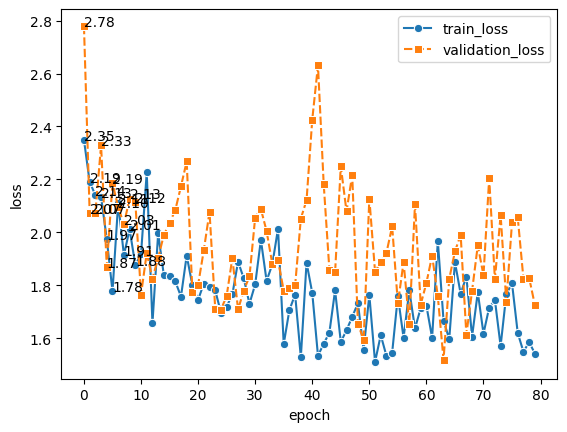

In [58]:
epochs = np.arange(10)
ax = sns.lineplot(losses, markers=['o', 's'])
ax.set(xlabel='epoch', ylabel='loss')
for x, y in zip(epochs, losses['validation_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
for x, y in zip(epochs, losses['train_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
plt.show()

### **model name generation**

In [59]:
names = custom_rnn_model_name.name_gen(name_nums=10, seq_len = 13, beg_sym='r', temperature=0.9)

In [60]:
names

['rivand',
 'roman',
 'redette',
 'rysas',
 'riagne',
 'rous',
 'richilyn',
 'renda',
 'rych',
 'ritten']

### **model gender prediction**

In [61]:
from sklearn.metrics import roc_auc_score

In [62]:
data_train = torch.tensor([seq for seq in train_data['encoded_names'].values])
data_val = torch.tensor([seq for seq in val_data['encoded_names'].values])
data_test = torch.tensor([seq for seq in test_data['encoded_names'].values])

In [63]:
custom_rnn_model_name.embed_matrix

Parameter containing:
tensor([[-0.1595, -0.0746,  0.0781,  ..., -0.1192,  0.0922,  0.1011],
        [-0.0312, -0.0692,  0.0656,  ...,  0.3372,  0.1819,  0.0673],
        [ 0.1436,  0.0852,  0.1432,  ..., -0.1645,  0.1346, -0.0426],
        ...,
        [-0.1277,  0.1739, -0.0200,  ..., -0.1892,  0.1013,  0.1539],
        [-0.2646,  0.2464, -0.3549,  ...,  0.2308,  0.1208, -0.0073],
        [-0.1024,  0.0518, -0.0706,  ...,  0.1608,  0.0302, -0.0576]],
       requires_grad=True)

In [64]:
data_test

tensor([[ 1, 22, 20,  ...,  0,  0,  0],
        [ 1,  5, 10,  ...,  0,  0,  0],
        [ 1, 12, 11,  ...,  0,  0,  0],
        ...,
        [ 1,  3,  7,  ...,  0,  0,  0],
        [ 1, 12,  3,  ...,  0,  0,  0],
        [ 1, 15,  3,  ...,  0,  0,  0]])

In [65]:
f_logit, h = custom_rnn_model_name.forward(data_test)

In [66]:
f_logit

tensor([[ 4.4939e-01],
        [ 7.4614e-02],
        [ 1.4035e-01],
        [ 6.0862e-01],
        [ 5.8020e-02],
        [ 4.8202e-01],
        [ 1.7445e-01],
        [-4.1373e-01],
        [ 5.3355e-01],
        [-8.0202e-01],
        [ 1.6461e-01],
        [ 6.2541e-02],
        [ 1.8150e-01],
        [ 1.7167e-01],
        [ 2.7712e-01],
        [ 5.1564e-01],
        [ 9.3896e-02],
        [ 1.6626e-01],
        [-1.7565e-01],
        [ 5.5139e-01],
        [ 1.3707e-01],
        [ 4.1807e-01],
        [ 6.7843e-02],
        [ 1.7847e-01],
        [ 3.6825e-01],
        [ 2.7510e-01],
        [ 4.2396e-01],
        [ 1.7428e-01],
        [ 3.5208e-01],
        [ 4.8545e-01],
        [ 6.0180e-02],
        [ 1.9272e-01],
        [ 1.2247e-01],
        [ 3.8385e-02],
        [ 1.9273e-01],
        [ 3.3256e-01],
        [ 3.0040e-01],
        [ 1.5046e-01],
        [ 3.7021e-01],
        [ 1.9461e-01],
        [ 3.6278e-01],
        [-2.1535e-01],
        [ 3.2241e-01],
        [ 2

In [67]:
probas = custom_rnn_model_name.predict_proba(f_logit)

In [68]:
probas

tensor([[0.6105],
        [0.5186],
        [0.5350],
        [0.6476],
        [0.5145],
        [0.6182],
        [0.5435],
        [0.3980],
        [0.6303],
        [0.3096],
        [0.5411],
        [0.5156],
        [0.5453],
        [0.5428],
        [0.5688],
        [0.6261],
        [0.5235],
        [0.5415],
        [0.4562],
        [0.6345],
        [0.5342],
        [0.6030],
        [0.5170],
        [0.5445],
        [0.5910],
        [0.5683],
        [0.6044],
        [0.5435],
        [0.5871],
        [0.6190],
        [0.5150],
        [0.5480],
        [0.5306],
        [0.5096],
        [0.5480],
        [0.5824],
        [0.5745],
        [0.5375],
        [0.5915],
        [0.5485],
        [0.5897],
        [0.4464],
        [0.5799],
        [0.5643],
        [0.5441],
        [0.5303],
        [0.6528],
        [0.5408],
        [0.5449],
        [0.5103],
        [0.4999],
        [0.5780],
        [0.5998],
        [0.5950],
        [0.5479],
        [0

In [69]:
roc_auc = roc_auc_score(test_data['gen_code'].values,probas.detach().cpu().numpy())

In [70]:
roc_auc

np.float64(0.5953447434467374)

# **LSTM**

In [71]:
class lstm_custom(nn.Module):

  def __init__(self, voc_size, in_dim, hidden_dim, out_dim, device='cpu', random_state = None):
    super().__init__()

    self.voc_size = voc_size
    self.in_dim = in_dim
    self.hidden_dim = hidden_dim
    self.out_dim = out_dim
    self.device = torch.device(device)
    self.random_state = random_state
    if self.random_state is not None:
      torch.manual_seed(self.random_state)

    self.weights_f = nn.Parameter(torch.empty((hidden_dim + in_dim, hidden_dim), dtype=torch.float32, device=device))
    self.weights_i = nn.Parameter(torch.empty((hidden_dim + in_dim, hidden_dim), dtype=torch.float32, device=device))
    self.weights_C = torch.empty((hidden_dim + in_dim, hidden_dim), dtype=torch.float32)
    self.weights_o = nn.Parameter(torch.empty((hidden_dim + in_dim, hidden_dim), dtype=torch.float32, device=device))
    self.weights_voc = nn.Parameter(torch.empty((hidden_dim, voc_size), dtype=torch.float32, device=device))
    self.weights_y = nn.Parameter(torch.empty((hidden_dim, out_dim), dtype=torch.float32, device=device))

    self.bias_f = nn.Parameter(torch.zeros(hidden_dim, dtype=torch.float32, device=device))
    self.bias_i = nn.Parameter(torch.zeros(hidden_dim, dtype=torch.float32, device=device))
    self.bias_C = nn.Parameter(torch.zeros(hidden_dim, dtype=torch.float32, device=device))
    self.bias_o = nn.Parameter(torch.zeros(hidden_dim, dtype=torch.float32, device=device))
    self.bias_voc = nn.Parameter(torch.zeros(voc_size, dtype=torch.float32, device=device))
    self.bias_y = nn.Parameter(torch.zeros(out_dim, dtype=torch.float32, device=device))

    self.weights_bias_initialization()
    self.embed_matrix = nn.Parameter(self.embed_matrix_initialization())

  def sigmoid(self, x):
    return torch.sigmoid(x)

  def input_transform(self, x):
    if isinstance(x, pd.DataFrame) or isinstance(x, pd.Series) or isinstance(x, np.ndarray) or isinstance(x, list) or isinstance(x, torch.Tensor):
      if not isinstance(x, torch.Tensor):
        x = torch.tensor(x, dtype=torch.long)
    else:
      raise TypeError("input should be pandas, numpy, list, or torch.Tensor")

    if len(x.shape) < 2:
      x = x.unsqueeze(0)

    return x.to(self.device)

  def embed_matrix_initialization(self):
    if self.random_state is not None:
      rng = np.random.RandomState(self.random_state)
      embed_matrix = rng.uniform(low=-1/self.hidden_dim**0.5, high=1/self.hidden_dim**0.5, size=(self.voc_size, self.in_dim))
    else:
      embed_matrix = np.random.uniform(low=-1/self.hidden_dim**0.5, high=1/self.hidden_dim**0.5, size=(self.voc_size, self.in_dim))

    embed_matrix = torch.tensor(embed_matrix, dtype=torch.float32).to(self.device)

    return embed_matrix

  def weights_bias_initialization(self) -> None:

    nn.init.xavier_uniform_(self.weights_f)
    nn.init.xavier_uniform_(self.weights_i)
    nn.init.xavier_uniform_(self.weights_o)
    nn.init.xavier_uniform_(self.weights_y)
    nn.init.xavier_uniform_(self.weights_voc)

    nn.init.orthogonal_(self.weights_C)
    self.weights_C = nn.Parameter(self.weights_C.to(self.device))

    nn.init.ones_(self.bias_f)
    nn.init.zeros_(self.bias_i)
    nn.init.zeros_(self.bias_o)
    nn.init.zeros_(self.bias_C)
    nn.init.zeros_(self.bias_y)
    nn.init.zeros_(self.bias_voc)

  def forget_gate(self, tok, h):
    return torch.sigmoid(torch.cat((h, tok), dim = 1) @ self.weights_f + self.bias_f) # (H, )

  def input_gate(self, tok, h):
    return torch.sigmoid(torch.cat((h, tok), dim = 1) @ self.weights_i + self.bias_i) # (H, )

  def candidate_val(self, tok ,h):
    return torch.tanh(torch.cat((h, tok), dim = 1) @ self.weights_C + self.bias_C)

  def cell_state(self, cand, c_prev, fog, inp):
    return fog * c_prev + inp * cand

  def output_gate(self, tok, h):
    return torch.sigmoid(torch.cat((h, tok), dim = 1) @ self.weights_o + self.bias_o) # (H, )

  def tok_output_log(self, h):
    logit = h @ self.weights_voc + self.bias_voc
    return logit

  def fin_output(self, h):
    logit = h @ self.weights_y + self.bias_y
    return logit

  def lstm_block(self, tok, h, c):
    fog = self.forget_gate(tok, h)
    inp = self.input_gate(tok, h)
    cand = self.candidate_val(tok, h)
    c = self.cell_state(cand=cand, c_prev=c, fog=fog, inp=inp) #self.c here
    out = self.output_gate(tok , h)
    h = out * torch.tanh(c)
    logit = self.tok_output_log(h)
    return logit, h, c

  def forward(self, x) -> torch.Tensor:
    x = self.input_transform(x)
    x = self.embed_matrix[x.long()]

    batch_size, seq_len, _ = x.shape
    h = torch.zeros(batch_size, self.hidden_dim, dtype=x.dtype, device=x.device)
    c = torch.zeros(batch_size, self.hidden_dim, dtype=x.dtype, device=x.device)

    for t in range(seq_len):
        logit, h, c = self.lstm_block(x[:, t, :], h, c)

    logit = self.fin_output(h)
    return logit, h

  def predict_proba(self, logit):
      return self.sigmoid(logit)

  def name_gen(self, name_nums, seq_len, beg_sym: str, temperature: float):
      if temperature <= 0:
          raise ValueError("temperature must be > 0")

      tokens = [' ', '<SOS>', '<EOS>']
      tokens.extend(list('abcdefghijklmnopqrstuvwxyz'))
      tokens_to_id = {tok: i for i, tok in enumerate(tokens)}
      id_to_tokens = {i: tok for tok, i in tokens_to_id.items()}

      self.eval()
      with torch.no_grad():
          beg_sym_id = torch.full(
              (name_nums,),
              tokens_to_id[beg_sym],
              dtype=torch.long,
              device=self.device
          )

          sos_id = tokens_to_id['<SOS>']

          h = torch.zeros(name_nums, self.hidden_dim, dtype=torch.float32, device=self.device)
          c = torch.zeros(name_nums, self.hidden_dim, dtype=torch.float32, device=self.device)

          sos_x = self.embed_matrix[torch.full((name_nums,), sos_id, dtype=torch.long, device=self.device)]
          _, h, c = self.lstm_block(sos_x, h, c)

          x = self.embed_matrix[beg_sym_id]
          _, h, c = self.lstm_block(x, h, c)

          names = np.empty((name_nums, seq_len), dtype=object)
          names[:, 0] = '<SOS>'
          names[:, 1] = beg_sym

          finished = torch.zeros(name_nums, dtype=torch.bool, device=self.device)

          for t in range(2, seq_len):
              logit, h, c = self.lstm_block(x, h, c)   # logit: (name_nums, voc_size)
              probs = torch.softmax(logit / temperature, dim=1)

              sym_id = torch.multinomial(probs, num_samples=1).squeeze(1)
              #sym_id = torch.argmax(probs, dim=1)

              eos_id = tokens_to_id['<EOS>']
              sym_id = torch.where(
                  finished,
                  torch.full_like(sym_id, eos_id),
                  sym_id
              )

              x = self.embed_matrix[sym_id]

              sym_list = [id_to_tokens[i] for i in sym_id.cpu().tolist()]
              names[:, t] = sym_list

              finished = finished | (sym_id == eos_id)

              if finished.all():
                  break

      result = []
      for row in names:
        chars = []
        for char in row:
          if char == '<SOS>':
            continue
          if char == '<EOS>':
            break
          if char != ' ':
            chars.append(char)
        result.append(''.join(chars))


      return result

In [72]:
def train_loop_lstm_name(dataloader, model, optimizer, loss_fn, device) -> None:

    size = len(dataloader.dataset)
    model.train()
    current_loss = 0.0
    for batch, (X, y) in enumerate(dataloader):

          X = model.input_transform(X) # ?

          batch_tokens = X

          x_batch = model.embed_matrix[batch_tokens.long()]
          batch_size, seq_len, _ = x_batch.shape

          h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          c = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          total_loss = 0.0

          pad_token_id = 0
          validation_steps = 0

          for t in range(seq_len - 1):
              logit, h, c = model.lstm_block(x_batch[:, t, :], h , c)
              target = batch_tokens[:, t + 1].to(torch.long)
              mask = target != pad_token_id

              if mask.any():
                loss = loss_fn(logit[mask], target[mask])
                total_loss = total_loss + loss
                validation_steps += 1

          # Backpropagation
          optimizer.zero_grad()
          total_loss = total_loss/validation_steps
          total_loss.backward()
          optimizer.step()

          if batch % 24 == 0:
            loss, current  = total_loss.item(), batch * dataloader.batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

          current_loss = total_loss.item()

    return current_loss

def validation_loop_lstm_name(dataloader, model, loss_fn, device) -> None:

    size = len(dataloader.dataset)
    model.eval()
    current_loss = 0.0
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            total_loss = 0.0
            X = model.input_transform(X) # ?

            batch_tokens = X

            x_batch = model.embed_matrix[batch_tokens.long()]
            batch_size, seq_len, _ = x_batch.shape

            h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
            c = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)

            pad_token_id = 0
            validation_steps = 0

            for t in range(seq_len - 1):
                logit, h, c = model.lstm_block(x_batch[:, t, :], h , c)
                target = batch_tokens[:, t + 1].to(torch.long)
                mask = target != pad_token_id

                if mask.any():
                  loss = loss_fn(logit[mask], target[mask])
                  total_loss = total_loss + loss.item()
                  validation_steps += 1

            if batch == len(dataloader) - 1:
                print(f"total loss on validation data: {total_loss/validation_steps:>7f}")

            current_loss = total_loss / validation_steps

    return current_loss

In [73]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### **model training and validation**

In [443]:
voc_size = 26 + 3
in_dim = 128
hidden_dim = 24
out_dim = 1

In [444]:
custom_lstm_model_name = lstm_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [445]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(custom_lstm_model_name.parameters(), lr=0.01)

In [446]:
epochs = 100 # total = 270
train_loss_lstm = []
validation_loss_lstm = []

for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_loss_lstm.append(train_loop_lstm_name(model=custom_lstm_model_name, dataloader=train_dataloader, optimizer=optimizer, loss_fn=loss_fn, device=device))
    validation_loss_lstm.append(validation_loop_lstm_name(model=custom_lstm_model_name, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))
print("Done!")

Epoch 1
-------------------------------
loss: 3.390314  [   32/ 5425]
loss: 3.335519  [  800/ 5425]
loss: 3.279486  [ 1568/ 5425]
loss: 3.229488  [ 2336/ 5425]
loss: 3.181149  [ 3104/ 5425]
loss: 3.138256  [ 3872/ 5425]
loss: 3.094788  [ 4640/ 5425]
loss: 3.019184  [ 5408/ 5425]
total loss on validation data: 3.112505
Epoch 2
-------------------------------
loss: 3.031454  [   32/ 5425]
loss: 3.013569  [  800/ 5425]
loss: 2.986617  [ 1568/ 5425]
loss: 2.911654  [ 2336/ 5425]
loss: 2.919181  [ 3104/ 5425]
loss: 2.800925  [ 3872/ 5425]
loss: 2.831280  [ 4640/ 5425]
loss: 2.780123  [ 5408/ 5425]
total loss on validation data: 2.889770
Epoch 3
-------------------------------
loss: 2.900346  [   32/ 5425]
loss: 2.697603  [  800/ 5425]
loss: 2.634709  [ 1568/ 5425]
loss: 2.681509  [ 2336/ 5425]
loss: 2.689267  [ 3104/ 5425]
loss: 2.720155  [ 3872/ 5425]
loss: 2.743876  [ 4640/ 5425]
loss: 2.718316  [ 5408/ 5425]
total loss on validation data: 2.754827
Epoch 4
-------------------------------


In [508]:
losses = pd.DataFrame(columns=['train_loss', 'validation_loss'])

In [509]:
losses['train_loss'] = train_loss_lstm
losses['validation_loss'] = validation_loss_lstm

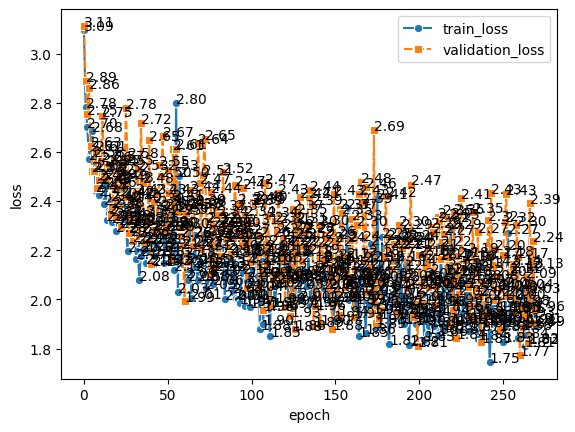

In [510]:
epochs = np.arange(270)
ax = sns.lineplot(losses, markers=['o', 's'])
ax.set(xlabel='epoch', ylabel='loss')
for x, y in zip(epochs, losses['validation_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
for x, y in zip(epochs, losses['train_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
plt.show()

### **model name generation**

In [511]:
names = custom_lstm_model_name.name_gen(name_nums=10, seq_len = 13, beg_sym='d', temperature=0.9)

In [512]:
names

['diccra',
 'dirina',
 'darie',
 'diles',
 'deler',
 'dine',
 'dailhe',
 'detia',
 'da',
 'dinen']

### **model gender prediction**

In [513]:
f_logit, h = custom_lstm_model_name.forward(data_test)

In [514]:
probas = custom_lstm_model_name.predict_proba(f_logit)

In [515]:
roc_auc = roc_auc_score(test_data['gen_code'].values,probas.detach().cpu().numpy())

In [516]:
roc_auc

np.float64(0.31799881483547127)

# **Gated Recurrent Unit**

In [87]:
class gru_custom(nn.Module):

  def __init__(self, voc_size, in_dim, hidden_dim, out_dim, device='cpu', random_state = None):
    super().__init__()

    self.voc_size = voc_size
    self.in_dim = in_dim
    self.hidden_dim = hidden_dim
    self.out_dim = out_dim
    self.device = torch.device(device)
    self.random_state = random_state
    if self.random_state is not None:
      torch.manual_seed(self.random_state)

    self.weights_z = nn.Parameter(torch.empty((hidden_dim + in_dim, hidden_dim), dtype=torch.float32, device=device))
    self.weights_r = nn.Parameter(torch.empty((hidden_dim + in_dim, hidden_dim), dtype=torch.float32, device=device))
    self.weights_h = nn.Parameter(torch.empty((hidden_dim + in_dim, hidden_dim), dtype=torch.float32, device=device))
    self.weights_voc = nn.Parameter(torch.empty((hidden_dim, voc_size), dtype=torch.float32, device=device))
    self.weights_y = nn.Parameter(torch.empty((hidden_dim, out_dim), dtype=torch.float32, device=device))

    self.bias_z = nn.Parameter(torch.zeros(hidden_dim, dtype=torch.float32, device=device))
    self.bias_r = nn.Parameter(torch.zeros(hidden_dim, dtype=torch.float32, device=device))
    self.bias_h = nn.Parameter(torch.zeros(hidden_dim, dtype=torch.float32, device=device))
    self.bias_voc = nn.Parameter(torch.zeros(voc_size, dtype=torch.float32, device=device))
    self.bias_y = nn.Parameter(torch.zeros(out_dim, dtype=torch.float32, device=device))

    self.weights_bias_initialization()
    self.embed_matrix = nn.Parameter(self.embed_matrix_initialization())

  def sigmoid(self, x):
    return torch.sigmoid(x)

  def input_transform(self, x):
    if isinstance(x, pd.DataFrame) or isinstance(x, pd.Series) or isinstance(x, np.ndarray) or isinstance(x, list) or isinstance(x, torch.Tensor):
      if not isinstance(x, torch.Tensor):
        x = torch.tensor(x, dtype=torch.long)
    else:
      raise TypeError("input should be pandas, numpy, list, or torch.Tensor")

    if len(x.shape) < 2:
      x = x.unsqueeze(0)

    return x.to(self.device)

  def embed_matrix_initialization(self):
    if self.random_state is not None:
      rng = np.random.RandomState(self.random_state)
      embed_matrix = rng.uniform(low=-1/self.hidden_dim**0.5, high=1/self.hidden_dim**0.5, size=(self.voc_size, self.in_dim))
    else:
      embed_matrix = np.random.uniform(low=-1/self.hidden_dim**0.5, high=1/self.hidden_dim**0.5, size=(self.voc_size, self.in_dim))

    embed_matrix = torch.tensor(embed_matrix, dtype=torch.float32).to(self.device)

    return embed_matrix

  def weights_bias_initialization(self) -> None:

    nn.init.xavier_uniform_(self.weights_z)
    nn.init.xavier_uniform_(self.weights_r)
    nn.init.xavier_uniform_(self.weights_h)
    nn.init.xavier_uniform_(self.weights_y)
    nn.init.xavier_uniform_(self.weights_voc)

    nn.init.zeros_(self.bias_z)
    nn.init.zeros_(self.bias_r)
    nn.init.zeros_(self.bias_h)
    nn.init.zeros_(self.bias_y)
    nn.init.zeros_(self.bias_voc)

  def update_gate(self, tok, h):
    return torch.sigmoid(torch.cat((h, tok), dim = 1) @ self.weights_z + self.bias_z) # (H, )

  def remove_gate(self, tok, h):
    return torch.sigmoid(torch.cat((h, tok), dim = 1) @ self.weights_r + self.bias_r) # (H, )

  def candidate_val(self, tok, h):
    return torch.tanh(torch.cat((self.remove_gate(tok, h) * h, tok), dim = 1) @ self.weights_h + self.bias_h)

  def tok_output_log(self, h):
    logit = h @ self.weights_voc + self.bias_voc
    return logit

  def fin_output(self, h):
    logit = h @ self.weights_y + self.bias_y
    return logit

  def gru_block(self, tok, h):
    upt = self.update_gate(tok, h)
    cand = self.candidate_val(tok, h)
    h = (torch.ones(h.shape[1], device=self.device) - upt) * h + upt * cand
    logit = self.tok_output_log(h)
    return logit, h

  def forward(self, x) -> torch.Tensor:
    x = self.input_transform(x)
    x = self.embed_matrix[x.long()]

    batch_size, seq_len, _ = x.shape
    h = torch.zeros(batch_size, self.hidden_dim, dtype=x.dtype, device=x.device)

    for t in range(seq_len):
        logit, h = self.gru_block(x[:, t, :], h)

    logit = self.fin_output(h)
    return logit, h

  def predict_proba(self, logit):
      return self.sigmoid(logit)

  def name_gen(self, name_nums, seq_len, beg_sym: str, temperature: float):
      if temperature <= 0:
          raise ValueError("temperature must be > 0")

      tokens = [' ', '<SOS>', '<EOS>']
      tokens.extend(list('abcdefghijklmnopqrstuvwxyz'))
      tokens_to_id = {tok: i for i, tok in enumerate(tokens)}
      id_to_tokens = {i: tok for tok, i in tokens_to_id.items()}

      self.eval()
      with torch.no_grad():
          beg_sym_id = torch.full(
              (name_nums,),
              tokens_to_id[beg_sym],
              dtype=torch.long,
              device=self.device
          )

          sos_id = tokens_to_id['<SOS>']

          h = torch.zeros(name_nums, self.hidden_dim, dtype=torch.float32, device=self.device)

          sos_x = self.embed_matrix[torch.full((name_nums,), sos_id, dtype=torch.long, device=self.device)]
          _, h = self.gru_block(sos_x, h)

          x = self.embed_matrix[beg_sym_id]
          _, h = self.gru_block(x, h)

          names = np.empty((name_nums, seq_len), dtype=object)
          names[:, 0] = '<SOS>'
          names[:, 1] = beg_sym

          finished = torch.zeros(name_nums, dtype=torch.bool, device=self.device)

          for t in range(2, seq_len):
              logit, h = self.gru_block(x, h)   # logit: (name_nums, voc_size)
              probs = torch.softmax(logit / temperature, dim=1)

              sym_id = torch.multinomial(probs, num_samples=1).squeeze(1)
              #sym_id = torch.argmax(probs, dim=1)

              eos_id = tokens_to_id['<EOS>']
              sym_id = torch.where(
                  finished,
                  torch.full_like(sym_id, eos_id),
                  sym_id
              )

              x = self.embed_matrix[sym_id]

              sym_list = [id_to_tokens[i] for i in sym_id.cpu().tolist()]
              names[:, t] = sym_list

              finished = finished | (sym_id == eos_id)

              if finished.all():
                  break

      result = []
      for row in names:
        chars = []
        for char in row:
          if char == '<SOS>':
            continue
          if char == '<EOS>':
            break
          if char != ' ':
            chars.append(char)
        result.append(''.join(chars))


      return result

In [88]:
def train_loop_gru_name(dataloader, model, optimizer, loss_fn, device) -> None:

    size = len(dataloader.dataset)
    model.train()
    current_loss = 0.0
    for batch, (X, y) in enumerate(dataloader):

          X = model.input_transform(X) # ?

          batch_tokens = X

          x_batch = model.embed_matrix[batch_tokens.long()]
          batch_size, seq_len, _ = x_batch.shape

          h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          total_loss = 0.0

          pad_token_id = 0
          validation_steps = 0

          for t in range(seq_len - 1):
              logit, h = model.gru_block(x_batch[:, t, :], h)
              target = batch_tokens[:, t + 1].to(torch.long)
              mask = target != pad_token_id

              if mask.any():
                loss = loss_fn(logit[mask], target[mask])
                total_loss = total_loss + loss
                validation_steps +=1

          # Backpropagation
          optimizer.zero_grad()
          total_loss = total_loss/validation_steps
          total_loss.backward()
          optimizer.step()

          if batch % 24 == 0:
            loss, current  = total_loss.item(), batch * dataloader.batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

          current_loss = total_loss.item()

    return current_loss

def validation_loop_gru_name(dataloader, model, loss_fn, device) -> None:

    size = len(dataloader.dataset)
    model.eval()
    current_loss = 0.0
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            total_loss = 0.0
            X = model.input_transform(X) # ?

            batch_tokens = X

            x_batch = model.embed_matrix[batch_tokens.long()]
            batch_size, seq_len, _ = x_batch.shape

            h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)

            pad_token_id = 0
            validation_steps = 0

            for t in range(seq_len - 1):
                logit, h = model.gru_block(x_batch[:, t, :], h)
                target = batch_tokens[:, t + 1].to(torch.long)
                mask = target != pad_token_id

                if mask.any():
                  loss = loss_fn(logit[mask], target[mask])
                  total_loss = total_loss + loss.item()
                  validation_steps +=1

            if batch == len(dataloader) - 1:
                print(f"total loss on validation data: {total_loss/validation_steps:>7f}")

            current_loss = total_loss / validation_steps

    return current_loss

In [89]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### **model training and validation**

In [526]:
voc_size = 26 + 3
in_dim = 128
hidden_dim = 32
out_dim = 1

In [527]:
custom_gru_model_name = gru_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [528]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(custom_gru_model_name.parameters(), lr=0.01)

In [529]:
epochs = 200
train_loss_gru = []
validation_loss_gru = []

for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_loss_gru.append(train_loop_gru_name(model=custom_gru_model_name, dataloader=train_dataloader, optimizer=optimizer, loss_fn=loss_fn, device=device))
    validation_loss_gru.append(validation_loop_gru_name(model=custom_gru_model_name, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))
print("Done!")

Epoch 1
-------------------------------
loss: 3.371899  [   32/ 5425]
loss: 3.295364  [  800/ 5425]
loss: 3.259726  [ 1568/ 5425]
loss: 3.205552  [ 2336/ 5425]
loss: 3.169931  [ 3104/ 5425]
loss: 3.125385  [ 3872/ 5425]
loss: 3.036835  [ 4640/ 5425]
loss: 2.969811  [ 5408/ 5425]
total loss on validation data: 3.072520
Epoch 2
-------------------------------
loss: 3.018629  [   32/ 5425]
loss: 2.872934  [  800/ 5425]
loss: 2.883964  [ 1568/ 5425]
loss: 2.874898  [ 2336/ 5425]
loss: 2.776517  [ 3104/ 5425]
loss: 2.795482  [ 3872/ 5425]
loss: 2.687275  [ 4640/ 5425]
loss: 2.708411  [ 5408/ 5425]
total loss on validation data: 2.817187
Epoch 3
-------------------------------
loss: 2.761113  [   32/ 5425]
loss: 2.731208  [  800/ 5425]
loss: 2.739770  [ 1568/ 5425]
loss: 2.650195  [ 2336/ 5425]
loss: 2.677097  [ 3104/ 5425]
loss: 2.709913  [ 3872/ 5425]
loss: 2.559946  [ 4640/ 5425]
loss: 2.595111  [ 5408/ 5425]
total loss on validation data: 2.802279
Epoch 4
-------------------------------


In [530]:
losses = pd.DataFrame(columns=['train_loss', 'validation_loss'])

In [531]:
losses['train_loss'] = train_loss_gru
losses['validation_loss'] = validation_loss_gru

In [532]:
epochs = 200

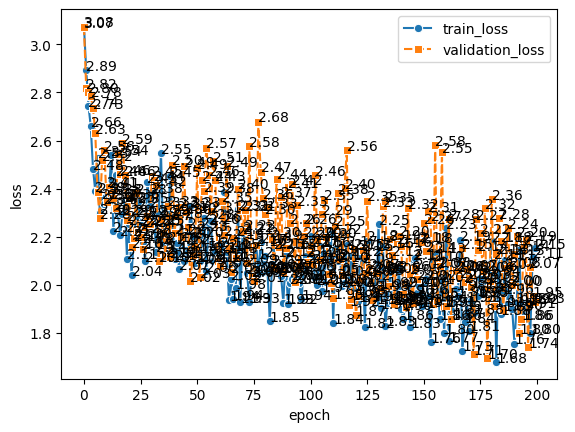

In [533]:
epochs = np.arange(epochs)
ax = sns.lineplot(losses, markers=['o', 's'])
ax.set(xlabel='epoch', ylabel='loss')
for x, y in zip(epochs, losses['validation_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
for x, y in zip(epochs, losses['train_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
plt.show()

### **model name generation**

In [536]:
names = custom_gru_model_name.name_gen(name_nums=10, seq_len = 13, beg_sym='r', temperature=0.9)

In [537]:
names

['ricso', 'rond', 'rey', 'ray', 'rin', 'richena', 'rinie', 'rad', 're', 'rer']

### **model gender prediction**

In [538]:
f_logit, h = custom_gru_model_name.forward(data_test)

In [539]:
probas = custom_gru_model_name.predict_proba(f_logit)

In [540]:
roc_auc = roc_auc_score(test_data['gen_code'].values,probas.detach().cpu().numpy())

In [541]:
roc_auc

np.float64(0.5943774400446179)

# **Model comparison**

**Perplexity (PPL)**  - measures how well a model predicts a sequence.

Perplexity ≈ effective number of choices the model is confused between

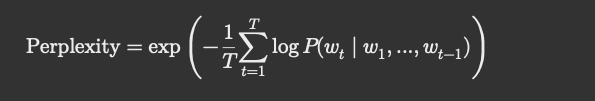

### **Conection to Cross-Entropy**

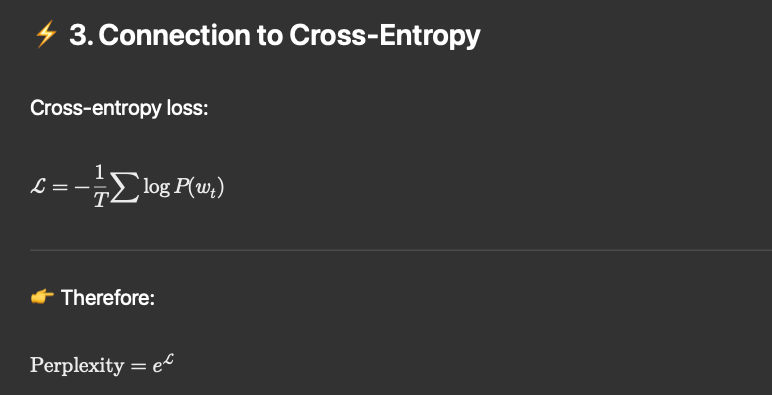

### **2 versions of this metric**

In [104]:
def cross_ppl(loss):
  # loss is cross_entropy loss per batch
  # here loss is total_loss averaged per timestep
  return torch.exp(loss).item()

def non_cross_ppl(probs):
  # probs is averaged over batch for each token (voc_size,)
  return (1/torch.prod(input=probs).item())**(1/probs.shape[0])

### **Derive the value of this metric for a "random" model that returns the same probability for each letter**

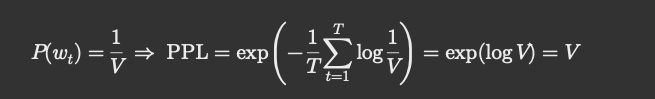

In [105]:
voc_size = 26
exclude = [0, 1, 2]
tokens = np.array([tok for tok in range(26)])
probs = np.array([(1/voc_size)] *voc_size)

In [106]:
tokens = torch.tensor(tokens)
probs = torch.tensor(probs)

In [107]:
probs.shape[0]

26

In [108]:
tokens

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25])

In [109]:
loss_fn = nn.CrossEntropyLoss()

In [110]:
total_loss = 0.0
for tok in range(len(tokens)):
    loss = loss_fn(probs, tokens[tok])
    total_loss = total_loss + loss
total_loss = total_loss / voc_size


In [111]:
ppl = cross_ppl(total_loss)

In [112]:
ppl, voc_size

(25.99999999999998, 26)

In [113]:
ppl = non_cross_ppl(probs)

In [114]:
ppl, voc_size

(26.000000000000004, 26)

### **Compute the value of this metric for a "most popular letters" model that returns the frequency of letters**

In [115]:
counts = [cnt for cnt in letters_count.values()]

In [116]:
total_count = np.array(counts).sum()

In [117]:
probs = counts / total_count

In [118]:
probs = torch.tensor(probs)

In [119]:
probs

tensor([0.1391, 0.0167, 0.0264, 0.0381, 0.1253, 0.0075, 0.0131, 0.0300, 0.0812,
        0.0125, 0.0153, 0.0810, 0.0310, 0.0876, 0.0515, 0.0066, 0.0015, 0.0764,
        0.0416, 0.0434, 0.0176, 0.0122, 0.0067, 0.0018, 0.0309, 0.0049],
       dtype=torch.float64)

In [120]:
loss_fn = nn.CrossEntropyLoss()

In [121]:
total_loss = 0.0
for tok in range(len(tokens)):
    loss = loss_fn(probs, tokens[tok])
    total_loss = total_loss + loss
total_loss = total_loss / voc_size


In [122]:
ppl = cross_ppl(total_loss)

In [123]:
ppl

26.01826837713244

In [124]:
ppl = non_cross_ppl(probs)

In [125]:
ppl

45.41068457500095

**rnn validation**

In [ ]:
ppl_rnn = cross_ppl(torch.tensor(min(validation_loss_rnn), dtype=torch.float64))

In [519]:
ppl_rnn

5.617156832625998

**lstm validation**

In [522]:
ppl_lstm = cross_ppl(torch.tensor(min(validation_loss_lstm), dtype=torch.float64))

In [523]:
ppl_lstm

5.89351170873867

**gru validation**

In [542]:
ppl_gru = cross_ppl(torch.tensor(min(validation_loss_gru), dtype=torch.float64))

In [543]:
ppl_gru

5.453118626333575

# **Gender classification**

### **RNN**

In [132]:
def train_loop_rnn_gen(dataloader, model, optimizer, loss_fn, device) -> None:

    size = len(dataloader.dataset)
    model.train()
    current_loss = 0.0
    for batch, (X, y) in enumerate(dataloader):

          X = model.input_transform(X) # ?

          batch_tokens = X

          x_batch = model.embed_matrix[batch_tokens.long()]
          batch_size, seq_len, _ = x_batch.shape

          h = torch.zeros(batch_size, model.weights_h.shape[0], dtype=x_batch.dtype, device=x_batch.device)
          total_loss = 0.0

          for t in range(seq_len):
              _ , h = model.rnn_sequential(x_batch[:, t, :], h)
              #loss = loss_fn(logit, batch_tokens[:, t + 1])
              #total_loss = total_loss + loss

          logit = model.fin_output(h) # (batch_size, out_dim)
          loss = loss_fn(logit, y.unsqueeze(1).to(x_batch.device))

          # Backpropagation
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          if batch % 24 == 0:
            loss_val, current  = loss.item(), batch * dataloader.batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

          current_loss = loss_val

    return current_loss

def validation_loop_rnn_gen(dataloader, model, loss_fn, device) -> None:

    size = len(dataloader.dataset)
    model.eval()
    current_loss = 0.0
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            total_loss = 0.0
            X = model.input_transform(X) # ?

            batch_tokens = X

            x_batch = model.embed_matrix[batch_tokens.long()]
            batch_size, seq_len, _ = x_batch.shape

            h = torch.zeros(batch_size, model.weights_h.shape[0], dtype=x_batch.dtype, device=x_batch.device)

            for t in range(seq_len):
                _ , h = model.rnn_sequential(x_batch[:, t, :], h)
                #loss = loss_fn(logit, batch_tokens[:, t + 1])
                #total_loss = total_loss + loss

            logit = model.fin_output(h) # (batch_size, out_dim)
            loss = loss_fn(logit, y.unsqueeze(1).to(x_batch.device))

            current_loss = loss.item()

            if batch == (len(dataloader) - 1):
              print(f'Validation loss is {current_loss:>7f}')

    return current_loss

In [133]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f"Using {device} device")

Using cpu device


In [134]:
voc_size = 26 + 3
in_dim = 128
hidden_dim = 16
out_dim = 1

In [135]:
custom_rnn_model_gen = rnn_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [136]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(custom_rnn_model_gen.parameters(), lr = 0.025)

In [137]:
epochs = 60
train_loss_rnn = []
validation_loss_rnn = []

for epoch in range(epochs):
  print(f"Epoch {epoch+1}\n-------------------------------")
  train_loss_rnn.append(train_loop_rnn_gen(model=custom_rnn_model_gen, dataloader=train_dataloader, optimizer=optimizer, loss_fn=loss_fn, device=device))
  validation_loss_rnn.append(validation_loop_rnn_gen(model=custom_rnn_model_gen, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))
print("Done!")

Epoch 1
-------------------------------
loss: 0.730021  [   32/ 5425]
loss: 0.650252  [  800/ 5425]
loss: 0.669073  [ 1568/ 5425]
loss: 0.678004  [ 2336/ 5425]
loss: 0.643339  [ 3104/ 5425]
loss: 0.619991  [ 3872/ 5425]
loss: 0.585360  [ 4640/ 5425]
loss: 0.629581  [ 5408/ 5425]
Validation loss is 0.646198
Epoch 2
-------------------------------
loss: 0.553800  [   32/ 5425]
loss: 0.649942  [  800/ 5425]
loss: 0.590840  [ 1568/ 5425]
loss: 0.514066  [ 2336/ 5425]
loss: 0.738104  [ 3104/ 5425]
loss: 0.571424  [ 3872/ 5425]
loss: 0.468613  [ 4640/ 5425]
loss: 0.491375  [ 5408/ 5425]
Validation loss is 0.415835
Epoch 3
-------------------------------
loss: 0.691104  [   32/ 5425]
loss: 0.556912  [  800/ 5425]
loss: 0.414317  [ 1568/ 5425]
loss: 0.477843  [ 2336/ 5425]
loss: 0.490941  [ 3104/ 5425]
loss: 0.524467  [ 3872/ 5425]
loss: 0.527254  [ 4640/ 5425]
loss: 0.488579  [ 5408/ 5425]
Validation loss is 0.369899
Epoch 4
-------------------------------
loss: 0.573880  [   32/ 5425]
loss: 

In [138]:
losses = pd.DataFrame(columns=['train_loss', 'validation_loss'])

In [139]:
losses['train_loss'] = train_loss_rnn
losses['validation_loss'] = validation_loss_rnn

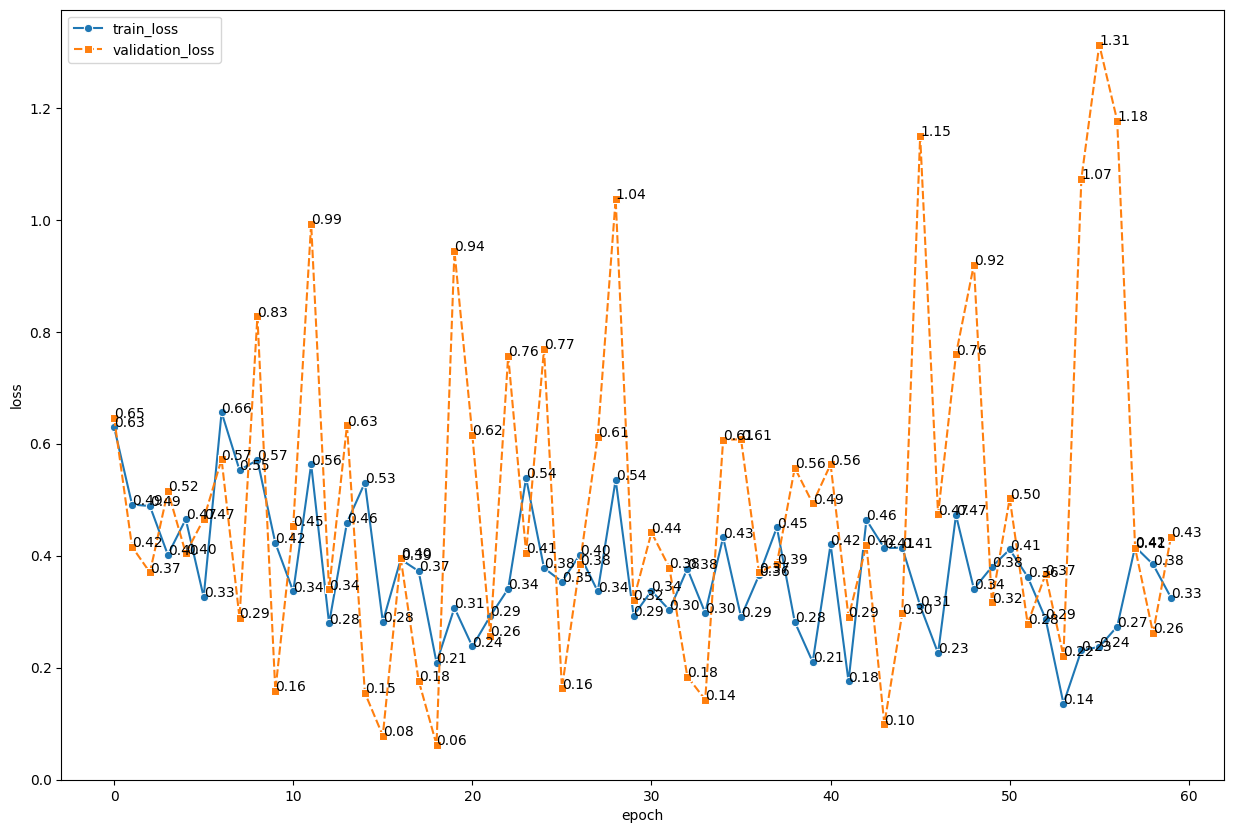

In [140]:
epochs = 60
epochs = np.arange(epochs)
plt.figure(figsize=(15, 10))
ax = sns.lineplot(losses, markers=['o', 's'])
ax.set(xlabel='epoch', ylabel='loss')
for x, y in zip(epochs, losses['validation_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
for x, y in zip(epochs, losses['train_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
plt.show()

In [141]:
f_logit, h = custom_rnn_model_gen.forward(data_test)

In [142]:
probas = custom_rnn_model_gen.predict_proba(f_logit)

In [143]:
roc_auc = roc_auc_score(test_data['gen_code'].values,probas.detach().cpu().numpy())

In [144]:
roc_auc

np.float64(0.9016313441160066)

In [145]:
names = custom_rnn_model_gen.name_gen(name_nums=5, seq_len = 13, beg_sym='g', temperature=40.9)

In [146]:
names

['gmqvpggfb', 'gleaogmgbe', 'gry', 'gfhadocajjk', 'gobvzybjkotb']

### **LSTM**

In [147]:
def train_loop_lstm_gen(dataloader, model, optimizer, loss_fn, device) -> None:

    size = len(dataloader.dataset)
    model.train()
    current_loss = 0.0
    for batch, (X, y) in enumerate(dataloader):

          X = model.input_transform(X) # ?

          batch_tokens = X

          x_batch = model.embed_matrix[batch_tokens.long()]
          batch_size, seq_len, _ = x_batch.shape

          h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          c = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          total_loss = 0.0

          for t in range(seq_len):
              _, h, c = model.lstm_block(x_batch[:, t, :], h , c)
              #loss = loss_fn(logit, batch_tokens[:, t + 1])
              #total_loss = total_loss + loss

          logit = model.fin_output(h) # (batch_size, out_dim)
          loss = loss_fn(logit, y.unsqueeze(1).to(x_batch.device))

          # Backpropagation
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          if batch % 24 == 0:
            loss_val, current  = loss.item(), batch * dataloader.batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

          current_loss = loss_val

    return current_loss

def validation_loop_lstm_gen(dataloader, model, loss_fn, device) -> None:

    size = len(dataloader.dataset)
    model.eval()
    current_loss = 0.0
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            total_loss = 0.0
            X = model.input_transform(X) # ?

            batch_tokens = X

            x_batch = model.embed_matrix[batch_tokens.long()]
            batch_size, seq_len, _ = x_batch.shape

            h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
            c = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)

            for t in range(seq_len):
              _, h, c = model.lstm_block(x_batch[:, t, :], h , c)
              #loss = loss_fn(logit, batch_tokens[:, t + 1])
              #total_loss = total_loss + loss

            logit = model.fin_output(h) # (batch_size, out_dim)
            loss = loss_fn(logit, y.unsqueeze(1).to(x_batch.device))

            current_loss = loss.item()

            if batch == (len(dataloader) - 1):
              print(f'Validation loss is {current_loss:>7f}')

    return current_loss

In [148]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f"Using {device} device")

Using cpu device


In [149]:
voc_size = 26 + 3
in_dim = 128
hidden_dim = 16
out_dim = 1

In [150]:
custom_lstm_model_gen = lstm_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [151]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(custom_lstm_model_gen.parameters(), lr = 0.025)

In [152]:
epochs = 60
train_loss_lstm = []
validation_loss_lstm = []

for epoch in range(epochs):
  print(f"Epoch {epoch+1}\n-------------------------------")
  train_loss_lstm.append(train_loop_lstm_gen(model=custom_lstm_model_gen, dataloader=train_dataloader, optimizer=optimizer, loss_fn=loss_fn, device=device))
  validation_loss_lstm.append(validation_loop_lstm_gen(model=custom_lstm_model_gen, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))
print("Done!")

Epoch 1
-------------------------------
loss: 0.717815  [   32/ 5425]
loss: 0.691439  [  800/ 5425]
loss: 0.690926  [ 1568/ 5425]
loss: 0.705975  [ 2336/ 5425]
loss: 0.695283  [ 3104/ 5425]
loss: 0.688892  [ 3872/ 5425]
loss: 0.690313  [ 4640/ 5425]
loss: 0.693360  [ 5408/ 5425]
Validation loss is 0.656917
Epoch 2
-------------------------------
loss: 0.708449  [   32/ 5425]
loss: 0.692185  [  800/ 5425]
loss: 0.695312  [ 1568/ 5425]
loss: 0.696334  [ 2336/ 5425]
loss: 0.677231  [ 3104/ 5425]
loss: 0.692690  [ 3872/ 5425]
loss: 0.682771  [ 4640/ 5425]
loss: 0.686159  [ 5408/ 5425]
Validation loss is 0.684699
Epoch 3
-------------------------------
loss: 0.695393  [   32/ 5425]
loss: 0.691863  [  800/ 5425]
loss: 0.681685  [ 1568/ 5425]
loss: 0.689690  [ 2336/ 5425]
loss: 0.684284  [ 3104/ 5425]
loss: 0.687929  [ 3872/ 5425]
loss: 0.685835  [ 4640/ 5425]
loss: 0.690252  [ 5408/ 5425]
Validation loss is 0.680492
Epoch 4
-------------------------------
loss: 0.702745  [   32/ 5425]
loss: 

In [153]:
losses = pd.DataFrame(columns=['train_loss', 'validation_loss'])

In [154]:
losses['train_loss'] = train_loss_lstm
losses['validation_loss'] = validation_loss_lstm

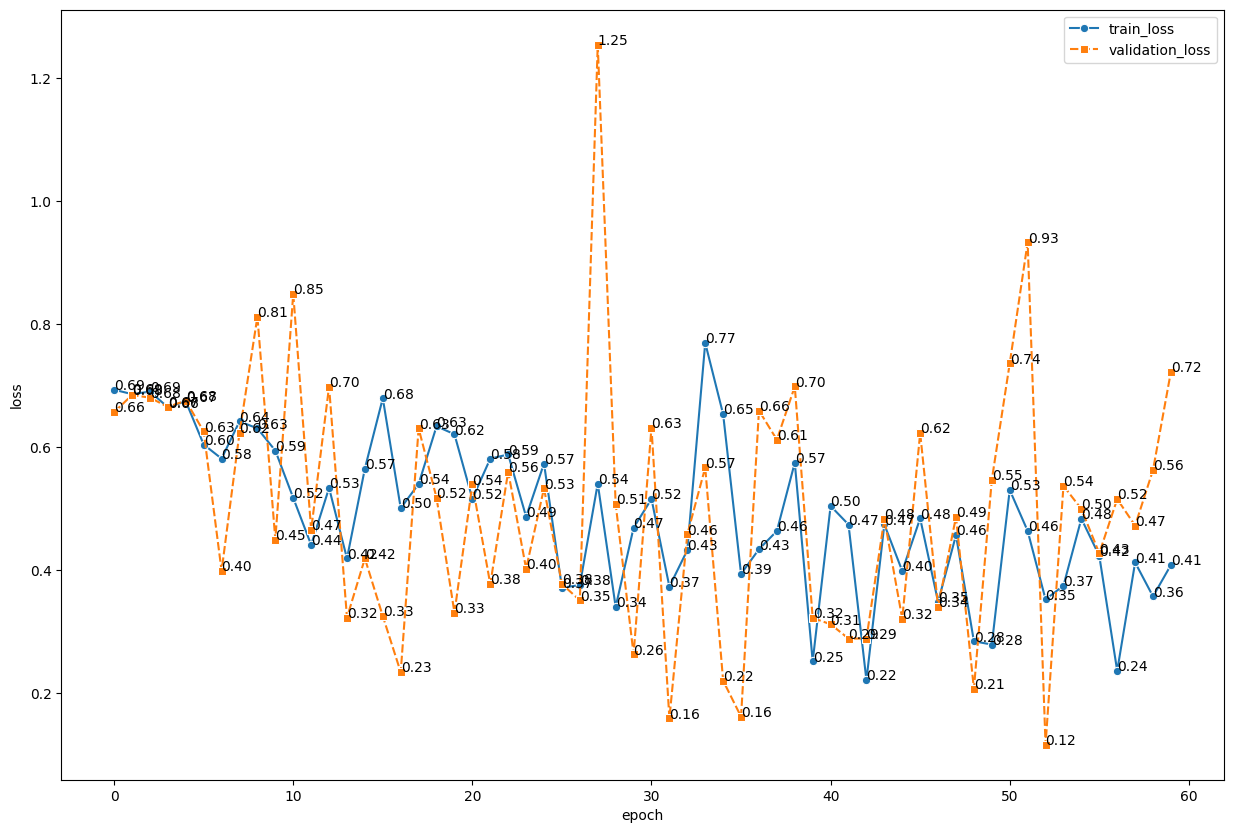

In [155]:
epochs = 60
epochs = np.arange(epochs)
plt.figure(figsize=(15, 10))
ax = sns.lineplot(losses, markers=['o', 's'])
ax.set(xlabel='epoch', ylabel='loss')
for x, y in zip(epochs, losses['validation_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
for x, y in zip(epochs, losses['train_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
plt.show()

In [156]:
f_logit, h = custom_lstm_model_gen.forward(data_test)

In [157]:
probas = custom_lstm_model_gen.predict_proba(f_logit)

In [158]:
roc_auc = roc_auc_score(test_data['gen_code'].values,probas.detach().cpu().numpy())

In [159]:
roc_auc

np.float64(0.8905901422197434)

In [160]:
names = custom_lstm_model_gen.name_gen(name_nums=5, seq_len = 13, beg_sym='g', temperature=40.9)

In [161]:
names

['gjiuhmpyeac', 'gcanoeanbuxr', 'gvfmivwmv', 'gmtiekpaudv', 'gnidosuzqpqu']

### **GRU**

In [162]:
def train_loop_gru_gen(dataloader, model, optimizer, loss_fn, device) -> None:

    size = len(dataloader.dataset)
    model.train()
    current_loss = 0.0
    for batch, (X, y) in enumerate(dataloader):

          X = model.input_transform(X) # ?

          batch_tokens = X

          x_batch = model.embed_matrix[batch_tokens.long()]
          batch_size, seq_len, _ = x_batch.shape

          h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          total_loss = 0.0

          for t in range(seq_len - 1):
              logit, h = model.gru_block(x_batch[:, t, :], h)
              #loss = loss_fn(logit, batch_tokens[:, t + 1])
              #total_loss = total_loss + loss

          logit = model.fin_output(h) # (batch_size, out_dim)
          loss = loss_fn(logit, y.unsqueeze(1).to(x_batch.device))

          # Backpropagation
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          if batch % 24 == 0:
            loss_val, current  = loss.item(), batch * dataloader.batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

          current_loss = loss_val

    return current_loss

def validation_loop_gru_gen(dataloader, model, loss_fn, device) -> None:

    size = len(dataloader.dataset)
    model.eval()
    current_loss = 0.0
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            total_loss = 0.0
            X = model.input_transform(X) # ?

            batch_tokens = X

            x_batch = model.embed_matrix[batch_tokens.long()]
            batch_size, seq_len, _ = x_batch.shape

            h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)

            for t in range(seq_len - 1):
                logit, h = model.gru_block(x_batch[:, t, :], h)
                #loss = loss_fn(logit, batch_tokens[:, t + 1])
                #total_loss = total_loss + loss.item()

            logit = model.fin_output(h) # (batch_size, out_dim)
            loss = loss_fn(logit, y.unsqueeze(1).to(x_batch.device))

            current_loss = loss.item()

            if batch == (len(dataloader) - 1):
              print(f'Validation loss is {current_loss:>7f}')

    return current_loss

In [163]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f"Using {device} device")

Using cpu device


In [164]:
voc_size = 26 + 3
in_dim = 128
hidden_dim = 16
out_dim = 1

In [165]:
custom_gru_model_gen = gru_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [166]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(custom_gru_model_gen.parameters(), lr = 0.025)

In [167]:
epochs = 60
train_loss_gru = []
validation_loss_gru = []

for epoch in range(epochs):
  print(f"Epoch {epoch+1}\n-------------------------------")
  train_loss_gru.append(train_loop_gru_gen(model=custom_gru_model_gen, dataloader=train_dataloader, optimizer=optimizer, loss_fn=loss_fn, device=device))
  validation_loss_gru.append(validation_loop_gru_gen(model=custom_gru_model_gen, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))
print("Done!")

Epoch 1
-------------------------------
loss: 0.686353  [   32/ 5425]
loss: 0.701167  [  800/ 5425]
loss: 0.698219  [ 1568/ 5425]
loss: 0.696601  [ 2336/ 5425]
loss: 0.698671  [ 3104/ 5425]
loss: 0.692011  [ 3872/ 5425]
loss: 0.688576  [ 4640/ 5425]
loss: 0.696862  [ 5408/ 5425]
Validation loss is 0.696747
Epoch 2
-------------------------------
loss: 0.699805  [   32/ 5425]
loss: 0.689417  [  800/ 5425]
loss: 0.691667  [ 1568/ 5425]
loss: 0.692954  [ 2336/ 5425]
loss: 0.691860  [ 3104/ 5425]
loss: 0.687058  [ 3872/ 5425]
loss: 0.687219  [ 4640/ 5425]
loss: 0.678765  [ 5408/ 5425]
Validation loss is 0.678035
Epoch 3
-------------------------------
loss: 0.680017  [   32/ 5425]
loss: 0.693330  [  800/ 5425]
loss: 0.693625  [ 1568/ 5425]
loss: 0.684886  [ 2336/ 5425]
loss: 0.685358  [ 3104/ 5425]
loss: 0.664085  [ 3872/ 5425]
loss: 0.681542  [ 4640/ 5425]
loss: 0.689236  [ 5408/ 5425]
Validation loss is 0.697179
Epoch 4
-------------------------------
loss: 0.687543  [   32/ 5425]
loss: 

In [168]:
losses = pd.DataFrame(columns=['train_loss', 'validation_loss'])

In [169]:
losses['train_loss'] = train_loss_gru
losses['validation_loss'] = validation_loss_gru

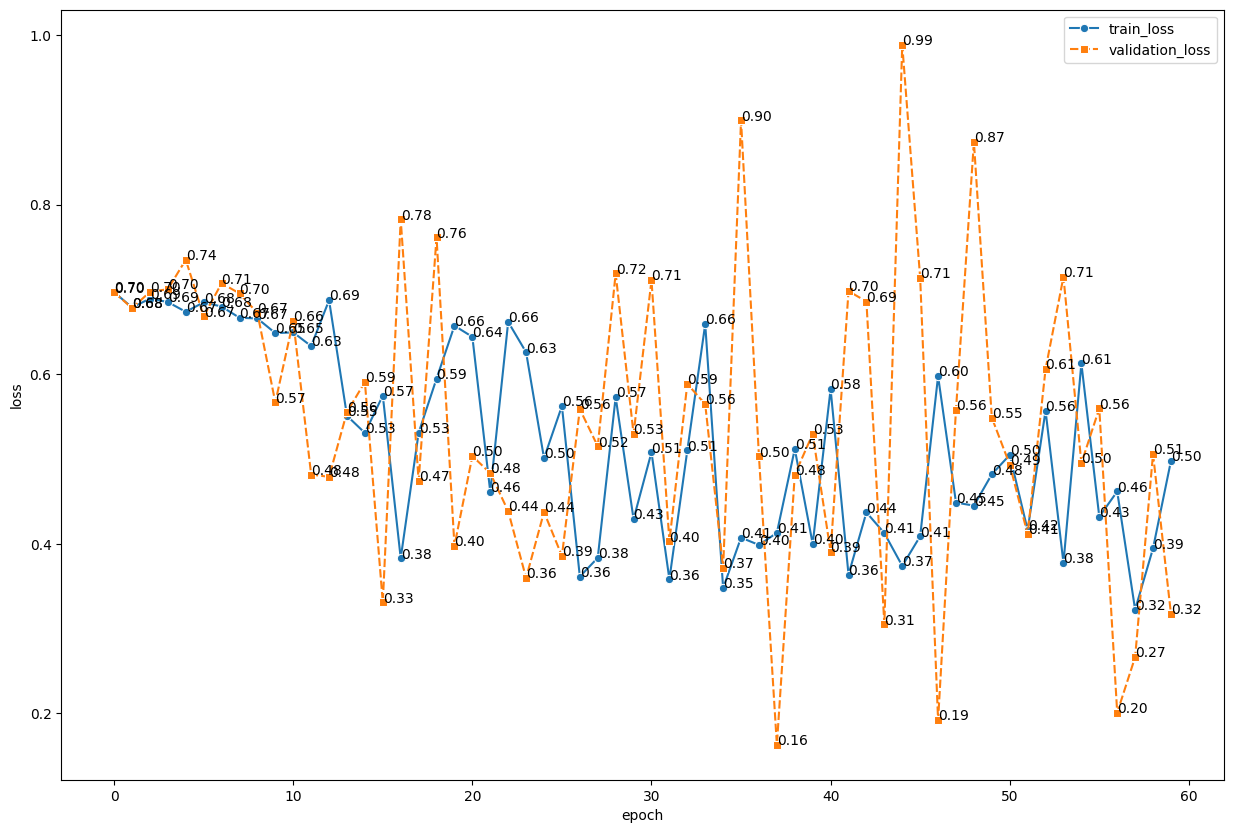

In [170]:
epochs = 60
epochs = np.arange(epochs)
plt.figure(figsize=(15, 10))
ax = sns.lineplot(losses, markers=['o', 's'])
ax.set(xlabel='epoch', ylabel='loss')
for x, y in zip(epochs, losses['validation_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
for x, y in zip(epochs, losses['train_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
plt.show()

In [171]:
f_logit, h = custom_gru_model_gen.forward(data_test)

In [172]:
probas = custom_gru_model_gen.predict_proba(f_logit)

In [173]:
roc_auc = roc_auc_score(test_data['gen_code'].values,probas.detach().cpu().numpy())

In [174]:
roc_auc

np.float64(0.8968383993307305)

# **Vanishing Gradient**

In [175]:
from scipy import stats as st

In [176]:
name_mode = st.mode(np.array([elem for elem in train_data['name_length'].values]))

In [177]:
name_mode.mode

np.int64(6)

In [178]:
req_train_data = train_data[train_data['name_length'] == name_mode.mode]

In [179]:
req_train_data

,Name,Gender,letters,name_length,gen_code,encoded_names
1631,<SOS>julien<EOS>,boy,"[j, u, l, i, e, n]",6,1.0,"[1, 12, 23, 14, 11, 7, 16, 2, 0, 0, 0, 0, 0]"
5604,<SOS>alyssa<EOS>,girl,"[a, l, y, s, s, a]",6,0.0,"[1, 3, 14, 27, 21, 21, 3, 2, 0, 0, 0, 0, 0]"
4757,<SOS>portia<EOS>,girl,"[p, o, r, t, i, a]",6,0.0,"[1, 18, 17, 20, 22, 11, 3, 2, 0, 0, 0, 0, 0]"
4026,<SOS>zilpha<EOS>,girl,"[z, i, l, p, h, a]",6,0.0,"[1, 28, 11, 14, 18, 10, 3, 2, 0, 0, 0, 0, 0]"
2306,<SOS>judith<EOS>,boy,"[j, u, d, i, t, h]",6,1.0,"[1, 12, 23, 6, 11, 22, 10, 2, 0, 0, 0, 0, 0]"
...,...,...,...,...,...,...
5482,<SOS>shawna<EOS>,girl,"[s, h, a, w, n, a]",6,0.0,"[1, 21, 10, 3, 25, 16, 3, 2, 0, 0, 0, 0, 0]"
3800,<SOS>mammie<EOS>,girl,"[m, a, m, m, i, e]",6,0.0,"[1, 15, 3, 15, 15, 11, 7, 2, 0, 0, 0, 0, 0]"
3078,<SOS>adonis<EOS>,boy,"[a, d, o, n, i, s]",6,1.0,"[1, 3, 6, 17, 16, 11, 21, 2, 0, 0, 0, 0, 0]"
630,<SOS>sumner<EOS>,boy,"[s, u, m, n, e, r]",6,1.0,"[1, 21, 23, 15, 16, 7, 20, 2, 0, 0, 0, 0, 0]"


In [ ]:
req_train_data.to_csv('./data/req_train_data.csv')

In [ ]:
req_train_data = CustomDataset(src_file='./data/req_train_data.csv')

In [182]:
req_train_data_dataloader = DataLoader(req_train_data, batch_size=1, shuffle=True)

In [183]:
next(iter(req_train_data_dataloader))

[tensor([[ 1.,  6.,  7., 14., 11., 14.,  3.,  2.,  0.,  0.,  0.,  0.,  0.]]),
 tensor([0.])]

### **Implement the collection of gradients during model fitting for the embedding layer**

In [184]:
class GradCollector():
  def __init__(self, epochs, max_name_length, n_tokens, embedding_size):
    self.storage = torch.zeros(epochs, max_name_length, n_tokens, embedding_size)
    self.counts = torch.zeros(epochs, max_name_length, n_tokens)
    self.current_epoch = 0
    self.tok_list = None
    self.n_tokens = n_tokens

  def hook(self, grad):
    for b in range(grad.shape[0]):
      for t in range(grad.shape[1]):
        token_id = self.tok_list[b, t].item()
        self.storage[self.current_epoch, t, token_id, :] += grad[b, t, :].detach().cpu()
        self.counts[self.current_epoch, t, token_id] +=1
    return grad

**architecture design: train_one_epoch -> collect_grad_one_epoch -> store_collected_grads**

In [185]:
def train_one_epoch_gen(model, model_type: str, dataloader, optimizer, loss_fn, device="cpu"):
    size = len(dataloader.dataset)
    model.train()
    current_loss = 0.0
    for batch, (X, y) in enumerate(dataloader):

          X = model.input_transform(X) # ?

          batch_tokens = X

          x_batch = model.embed_matrix[batch_tokens.long()]
          batch_size, seq_len, _ = x_batch.shape

          h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          if model_type == 'lstm':
            c = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)

          for t in range(seq_len):
            if model_type == 'rnn':
              _ , h = model.rnn_sequential(x_batch[:, t, :], h)
            if model_type == 'lstm':
              _, h, c = model.lstm_block(x_batch[:, t, :], h , c)
            if model_type == 'gru':
              _, h = model.gru_block(x_batch[:, t, :], h)

          logit = model.fin_output(h) # (batch_size, out_dim)
          loss = loss_fn(logit, y.unsqueeze(1).to(x_batch.device))

          # Backpropagation
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          if batch % 24 == 0:
            loss_val, current  = loss.item(), batch * dataloader.batch_size + len(X)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")

          current_loss = loss_val

    return current_loss


def collect_epoch_embedding_grads(model, model_type: str, dataloader, collector, loss_fn, max_name_length, n_tokens, embedding_size, device) -> None:
  model.eval()

  for batch, (X, y) in enumerate(dataloader):

    X = model.input_transform(X)

    batch_size, seq_len = X.shape

    batch_tokens = X

    # x_batch = torch.zeros(batch_size, seq_len, voc_size, in_dim)

    x_batch = model.embed_matrix[batch_tokens.long()]

    handle = x_batch.register_hook(collector.hook)
    collector.tok_list = batch_tokens.long()
    x_batch.retain_grad()

    h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=device)
    if model_type == 'lstm':
      c = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=device)

    for t in range(seq_len):

      if model_type == 'rnn':
        logit, h = model.rnn_sequential(x_batch[:, t, :], h)
      if model_type == 'lstm':
        logit, h, c = model.lstm_block(x_batch[:, t, :], h , c)
      if model_type == 'gru':
        logit, h = model.gru_block(x_batch[:, t, :], h)

    logit = model.fin_output(h) # (batch_size, out_dim)
    loss = loss_fn(logit, y.unsqueeze(1).to(device))
    model.zero_grad()
    loss.backward()

    handle.remove()

  collector.storage[collector.current_epoch] /= collector.counts[collector.current_epoch].unsqueeze(-1).clamp(min=1)


def fit_and_collect_grads_train_loop_rnn_gen(model, model_type: str, dataloader, collector, optimizer, loss_fn_1, loss_fn_2, max_name_length, n_tokens, embedding_size, device="cpu", train = True, grad_collection = True):

            train_loss = 0.0

            if train == True:

              train_loss = train_one_epoch_gen(
              model=model,
              model_type=model_type,
              dataloader=dataloader,
              optimizer=optimizer,
              loss_fn=loss_fn_1,
              device=device
              )

            if grad_collection == True:

              collect_epoch_embedding_grads(
              model=model,
              model_type=model_type,
              dataloader=dataloader,
              collector = collector,
              loss_fn=loss_fn_2,
              max_name_length=max_name_length,
              n_tokens=n_tokens,
              embedding_size=embedding_size,
              device=device
              )

            collector.current_epoch = collector.current_epoch + 1

            return train_loss


In [186]:
voc_size = 26 + 3
seq_len = 13
in_dim = 128
hidden_dim = 16
out_dim = 1

In [187]:
rnn_model_testing = rnn_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [188]:
loss_fn_1 = nn.BCEWithLogitsLoss()
loss_fn_2 = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(rnn_model_testing.parameters(), lr = 0.025)

In [189]:
epochs = 1
collector = GradCollector(epochs=epochs, max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim)

train = True
grad_collection = True

train_loss_rnn = []
validation_loss_rnn = []

for epoch in range(epochs):
  print(f"Epoch {epoch+1}\n-------------------------------")

  train_loss_rnn.append(fit_and_collect_grads_train_loop_rnn_gen(
    model=rnn_model_testing, model_type = 'rnn', dataloader=req_train_data_dataloader, collector=collector, optimizer=optimizer,
    loss_fn_1=loss_fn_1, loss_fn_2=loss_fn_2,
    max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim, device=device, train=train, grad_collection=grad_collection))

  #validation_loss_rnn.append(validation_loop_rnn_gen(model=rnn_model_testing, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))

print("Done!")

Epoch 1
-------------------------------
loss: 0.501059  [    1/ 1585]
loss: 0.617874  [   25/ 1585]
loss: 0.910451  [   49/ 1585]
loss: 0.798716  [   73/ 1585]
loss: 0.909736  [   97/ 1585]
loss: 0.301370  [  121/ 1585]
loss: 1.109480  [  145/ 1585]
loss: 0.477501  [  169/ 1585]
loss: 0.354293  [  193/ 1585]
loss: 0.307806  [  217/ 1585]
loss: 0.386568  [  241/ 1585]
loss: 1.325666  [  265/ 1585]
loss: 0.445073  [  289/ 1585]
loss: 0.748316  [  313/ 1585]
loss: 1.044412  [  337/ 1585]
loss: 0.866544  [  361/ 1585]
loss: 0.241938  [  385/ 1585]
loss: 0.138212  [  409/ 1585]
loss: 0.193299  [  433/ 1585]
loss: 0.115477  [  457/ 1585]
loss: 0.149387  [  481/ 1585]
loss: 0.171028  [  505/ 1585]
loss: 0.249293  [  529/ 1585]
loss: 1.135866  [  553/ 1585]
loss: 1.688181  [  577/ 1585]
loss: 0.290701  [  601/ 1585]
loss: 0.761548  [  625/ 1585]
loss: 0.135636  [  649/ 1585]
loss: 0.095477  [  673/ 1585]
loss: 0.186505  [  697/ 1585]
loss: 0.138523  [  721/ 1585]
loss: 0.139377  [  745/ 1585]


In [190]:
collector.storage.shape

torch.Size([1, 13, 29, 128])

In [191]:
grad_norm = torch.norm(collector.storage, dim=-1, p=2)

In [192]:
grad_norm

tensor([[[0.0000, 0.0136, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0072, 0.0296, 0.0204, 0.0168, 0.0212,
          0.0860, 0.0530, 0.0172, 0.0370, 0.0081, 0.0169, 0.0133, 0.0194,
          0.0343, 0.0196, 0.0223, 0.0856, 0.0581, 0.0291, 0.0588, 0.1663,
          0.0453, 0.0426, 0.0121, 0.0476, 0.0364],
         [0.0000, 0.0000, 0.0000, 0.0070, 0.0528, 0.2001, 0.0191, 0.0111,
          0.0443, 0.0133, 0.0395, 0.0210, 0.0000, 0.3089, 0.0151, 0.0208,
          0.0596, 0.0483, 0.5493, 1.5592, 0.0206, 0.1142, 0.1569, 0.0217,
          0.0699, 0.2802, 0.0000, 0.0612, 0.0700],
         [0.0000, 0.0000, 0.0000, 0.0073, 0.0394, 0.0697, 0.0170, 0.0496,
          0.0988, 0.0893, 0.0497, 0.0198, 0.3312, 0.0779, 0.0200, 0.0411,
          0.0216, 0.0784, 0.0576,

Text(0.5, 1.0, 'Gradient norms (epoch 0)')

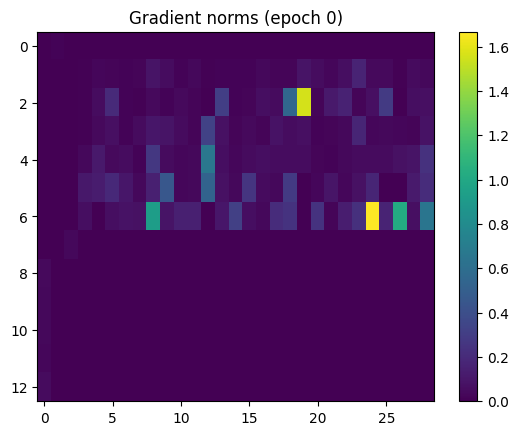

In [193]:
import matplotlib.pyplot as plt

plt.imshow(grad_norm[0], aspect='auto')
plt.colorbar()
plt.title("Gradient norms (epoch 0)")

In [194]:
forb_norm = torch.norm(input=collector.storage, p='fro', dim=(2, 3))

In [195]:
forb_norm

tensor([[0.0136, 0.2592, 1.7358, 0.4518, 0.7919, 0.9241, 2.3556, 0.0330, 0.0430,
         0.0360, 0.0343, 0.0313, 0.0500]])

Text(0.5, 1.0, 'Gradient norms (epoch 0)')

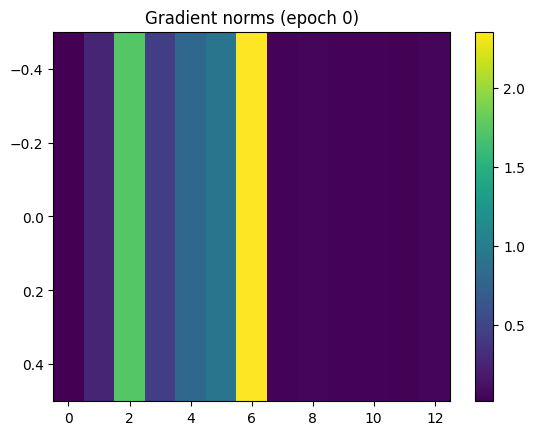

In [196]:
import matplotlib.pyplot as plt

plt.imshow(forb_norm[0].unsqueeze(0), aspect='auto')
plt.colorbar()
plt.title("Gradient norms (epoch 0)")

In [197]:
forb_mean = torch.mean(forb_norm, dim=1)

In [198]:
forb_mean  # padding affects a lot

tensor([0.5200])

### **Train models for the gender classification task: RNN, LSTM, GRU**

In [199]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f"Using {device} device")

Using cpu device


In [200]:
voc_size = 26 + 3
seq_len = 13
in_dim = 128
hidden_dim = 16
out_dim = 1

**RNN**

In [201]:
req_train_data_dataloader = DataLoader(req_train_data, batch_size=32, shuffle=True)

In [202]:
rnn_model_testing = rnn_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [203]:
loss_fn_1 = nn.BCEWithLogitsLoss()
loss_fn_2 = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(rnn_model_testing.parameters(), lr = 0.025)

In [204]:
epochs = 60
collector_rnn = GradCollector(epochs=epochs, max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim)

train = True
grad_collection = True

train_loss_rnn = []
validation_loss_rnn = []

for epoch in range(epochs):
  print(f"Epoch {epoch+1}\n-------------------------------")

  train_loss_rnn.append(fit_and_collect_grads_train_loop_rnn_gen(
    model=rnn_model_testing, model_type = 'rnn', dataloader=req_train_data_dataloader, collector=collector_rnn, optimizer=optimizer,
    loss_fn_1=loss_fn_1, loss_fn_2=loss_fn_2,
    max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim, device=device, train=train, grad_collection=grad_collection))

  #validation_loss_rnn.append(validation_loop_rnn_gen(model=rnn_model_testing, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))

print("Done!")

Epoch 1
-------------------------------
loss: 0.748815  [   32/ 1585]
loss: 0.688569  [  800/ 1585]
loss: 0.656298  [ 1568/ 1585]
Epoch 2
-------------------------------
loss: 0.612348  [   32/ 1585]
loss: 0.635284  [  800/ 1585]
loss: 0.572747  [ 1568/ 1585]
Epoch 3
-------------------------------
loss: 0.466064  [   32/ 1585]
loss: 0.617185  [  800/ 1585]
loss: 0.529413  [ 1568/ 1585]
Epoch 4
-------------------------------
loss: 0.512615  [   32/ 1585]
loss: 0.553589  [  800/ 1585]
loss: 0.572452  [ 1568/ 1585]
Epoch 5
-------------------------------
loss: 0.399436  [   32/ 1585]
loss: 0.468723  [  800/ 1585]
loss: 0.485047  [ 1568/ 1585]
Epoch 6
-------------------------------
loss: 0.511670  [   32/ 1585]
loss: 0.580316  [  800/ 1585]
loss: 0.453996  [ 1568/ 1585]
Epoch 7
-------------------------------
loss: 0.378645  [   32/ 1585]
loss: 0.332538  [  800/ 1585]
loss: 0.634454  [ 1568/ 1585]
Epoch 8
-------------------------------
loss: 0.418845  [   32/ 1585]
loss: 0.315196  [  8

In [205]:
forb_norm_rnn = torch.norm(input=collector_rnn.storage, p='fro', dim=(2, 3))

In [206]:
forb_norm_rnn.shape

torch.Size([60, 13])

In [207]:
forb_norm_rnn_mean = torch.mean(forb_norm_rnn, dim=0).unsqueeze(0)

In [208]:
forb_norm_rnn_mean

tensor([[0.0048, 0.0429, 0.1034, 0.0516, 0.0903, 0.1278, 0.1004, 0.0051, 0.0043,
         0.0042, 0.0041, 0.0036, 0.0029]])

Text(0.5, 1.0, 'Gradient norms')

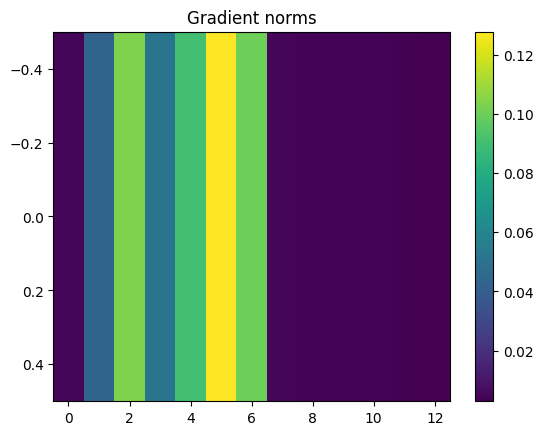

In [209]:
import matplotlib.pyplot as plt

plt.imshow(forb_norm_rnn_mean, aspect='auto')
plt.colorbar()
plt.title("Gradient norms")

**LSTM**

In [210]:
voc_size = 26 + 3
seq_len = 13
in_dim = 128
hidden_dim = 32
out_dim = 1

In [211]:
lstm_model_testing = lstm_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [212]:
loss_fn_1 = nn.BCEWithLogitsLoss()
loss_fn_2 = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(lstm_model_testing.parameters(), lr = 0.025)

In [213]:
epochs = 250
collector_lstm = GradCollector(epochs=epochs, max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim)

train = True
grad_collection = True

train_loss_lstm = []
validation_loss_lstm = []

for epoch in range(epochs):
  print(f"Epoch {epoch+1}\n-------------------------------")

  train_loss_lstm.append(fit_and_collect_grads_train_loop_rnn_gen(
    model=lstm_model_testing, model_type = 'lstm', dataloader=req_train_data_dataloader, collector=collector_lstm, optimizer=optimizer,
    loss_fn_1=loss_fn_1, loss_fn_2=loss_fn_2,
    max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim, device=device, train=train, grad_collection=grad_collection))

  #validation_loss_rnn.append(validation_loop_rnn_gen(model=rnn_model_testing, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))

print("Done!")

Epoch 1
-------------------------------
loss: 0.688120  [   32/ 1585]
loss: 0.693024  [  800/ 1585]
loss: 0.692413  [ 1568/ 1585]
Epoch 2
-------------------------------
loss: 0.688157  [   32/ 1585]
loss: 0.691128  [  800/ 1585]
loss: 0.691963  [ 1568/ 1585]
Epoch 3
-------------------------------
loss: 0.697589  [   32/ 1585]
loss: 0.691312  [  800/ 1585]
loss: 0.690783  [ 1568/ 1585]
Epoch 4
-------------------------------
loss: 0.690448  [   32/ 1585]
loss: 0.686761  [  800/ 1585]
loss: 0.694639  [ 1568/ 1585]
Epoch 5
-------------------------------
loss: 0.689812  [   32/ 1585]
loss: 0.695149  [  800/ 1585]
loss: 0.693482  [ 1568/ 1585]
Epoch 6
-------------------------------
loss: 0.687573  [   32/ 1585]
loss: 0.706645  [  800/ 1585]
loss: 0.685075  [ 1568/ 1585]
Epoch 7
-------------------------------
loss: 0.687146  [   32/ 1585]
loss: 0.690224  [  800/ 1585]
loss: 0.694165  [ 1568/ 1585]
Epoch 8
-------------------------------
loss: 0.695404  [   32/ 1585]
loss: 0.688398  [  8

In [214]:
collector_lstm.storage

tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [-5.6899e-07,  2.4905e-08,  2.4515e-07,  ..., -3.2415e-07,
            1.4402e-07, -9.3864e-07],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          ...,
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          ...,
     

In [215]:
forb_norm_lstm= torch.norm(input=collector_lstm.storage, p='fro', dim=(2, 3))

In [216]:
forb_norm_lstm

tensor([[5.1944e-06, 9.1053e-04, 1.5013e-03,  ..., 3.9395e-05, 5.0303e-05,
         6.9074e-05],
        [2.8362e-06, 9.2238e-04, 1.5204e-03,  ..., 1.3307e-05, 1.5125e-05,
         2.5109e-05],
        [3.3421e-06, 9.1566e-04, 1.5411e-03,  ..., 2.1019e-05, 2.5646e-05,
         3.7437e-05],
        ...,
        [1.6112e-03, 2.6070e-02, 4.9448e-02,  ..., 6.1688e-04, 4.1610e-04,
         3.7466e-04],
        [6.6271e-04, 2.1070e-02, 5.1950e-02,  ..., 3.5796e-04, 1.9760e-04,
         1.0676e-04],
        [3.2413e-03, 3.9163e-02, 5.4651e-02,  ..., 3.1006e-03, 2.2338e-03,
         1.7094e-03]])

In [217]:
forb_norm_lstm_mean = torch.mean(forb_norm_lstm, dim=0).unsqueeze(0)

In [218]:
forb_norm_lstm_mean

tensor([[0.0015, 0.0176, 0.0340, 0.0239, 0.0386, 0.0553, 0.0438, 0.0046, 0.0037,
         0.0029, 0.0023, 0.0017, 0.0013]])

Text(0.5, 1.0, 'Gradient norms')

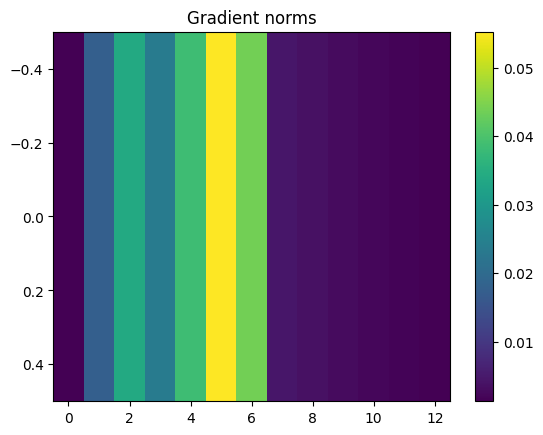

In [219]:
import matplotlib.pyplot as plt

plt.imshow(forb_norm_lstm_mean, aspect='auto')
plt.colorbar()
plt.title("Gradient norms")

**GRU**

In [220]:
gru_model_testing = gru_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [221]:
loss_fn_1 = nn.BCEWithLogitsLoss()
loss_fn_2 = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(gru_model_testing.parameters(), lr = 0.025)

In [222]:
epochs = 150
collector_gru = GradCollector(epochs=epochs, max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim)

train = True
grad_collection = True

train_loss_gru = []
validation_loss_gru = []

for epoch in range(epochs):
  print(f"Epoch {epoch+1}\n-------------------------------")

  train_loss_gru.append(fit_and_collect_grads_train_loop_rnn_gen(
    model=gru_model_testing, model_type = 'gru', dataloader=req_train_data_dataloader, collector=collector_gru, optimizer=optimizer,
    loss_fn_1=loss_fn_1, loss_fn_2=loss_fn_2,
    max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim, device=device, train=train, grad_collection=grad_collection))

  #validation_loss_rnn.append(validation_loop_rnn_gen(model=rnn_model_testing, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))

print("Done!")

Epoch 1
-------------------------------
loss: 0.699466  [   32/ 1585]
loss: 0.695078  [  800/ 1585]
loss: 0.692412  [ 1568/ 1585]
Epoch 2
-------------------------------
loss: 0.689481  [   32/ 1585]
loss: 0.692804  [  800/ 1585]
loss: 0.697582  [ 1568/ 1585]
Epoch 3
-------------------------------
loss: 0.691505  [   32/ 1585]
loss: 0.694818  [  800/ 1585]
loss: 0.693900  [ 1568/ 1585]
Epoch 4
-------------------------------
loss: 0.703973  [   32/ 1585]
loss: 0.693663  [  800/ 1585]
loss: 0.687816  [ 1568/ 1585]
Epoch 5
-------------------------------
loss: 0.690440  [   32/ 1585]
loss: 0.690730  [  800/ 1585]
loss: 0.696719  [ 1568/ 1585]
Epoch 6
-------------------------------
loss: 0.689751  [   32/ 1585]
loss: 0.689114  [  800/ 1585]
loss: 0.691574  [ 1568/ 1585]
Epoch 7
-------------------------------
loss: 0.697216  [   32/ 1585]
loss: 0.694550  [  800/ 1585]
loss: 0.693619  [ 1568/ 1585]
Epoch 8
-------------------------------
loss: 0.691384  [   32/ 1585]
loss: 0.692149  [  8

In [223]:
forb_norm_gru= torch.norm(input=collector_gru.storage, p='fro', dim=(2, 3))

In [224]:
forb_norm_gru

tensor([[8.3082e-07, 7.7405e-05, 1.6051e-04,  ..., 1.3115e-04, 2.3128e-04,
         4.7558e-04],
        [4.7097e-07, 7.4101e-05, 1.6326e-04,  ..., 6.6594e-05, 1.1685e-04,
         2.3989e-04],
        [9.7884e-07, 7.4438e-05, 1.6702e-04,  ..., 1.5485e-04, 2.7291e-04,
         5.6075e-04],
        ...,
        [6.7589e-04, 8.0583e-03, 2.3882e-02,  ..., 1.9940e-03, 1.6729e-03,
         1.6480e-03],
        [1.3473e-03, 1.3485e-02, 2.8604e-02,  ..., 3.9773e-03, 3.3292e-03,
         3.1824e-03],
        [1.0594e-03, 9.4311e-03, 2.5134e-02,  ..., 2.8632e-03, 2.4206e-03,
         2.4613e-03]])

In [225]:
forb_norm_gru_mean = torch.mean(forb_norm_gru, dim=0).unsqueeze(0)

In [226]:
forb_norm_gru_mean

tensor([[0.0003, 0.0049, 0.0105, 0.0105, 0.0208, 0.0303, 0.0362, 0.0033, 0.0024,
         0.0023, 0.0021, 0.0018, 0.0016]])

Text(0.5, 1.0, 'Gradient norms')

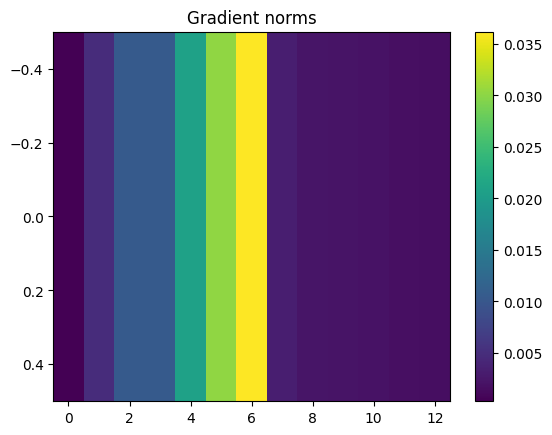

In [227]:
import matplotlib.pyplot as plt

plt.imshow(forb_norm_gru_mean, aspect='auto')
plt.colorbar()
plt.title("Gradient norms")

### **Repeat steps b-f when training the model for the next letter prediction task**

In [228]:
class GradCollector():
  def __init__(self, epochs, max_name_length, n_tokens, embedding_size):
    self.storage = torch.zeros(epochs, max_name_length, n_tokens, embedding_size)
    self.counts = torch.zeros(epochs, max_name_length, n_tokens)
    self.current_epoch = 0
    self.tok_list = None

  def hook(self, grad):
    for b in range(grad.shape[0]):
      for t in range(grad.shape[1]):
        token_id = self.tok_list[b, t].item()
        self.storage[self.current_epoch, t, token_id, :] += grad[b, t, :].detach().cpu()
      return grad

In [229]:
def train_one_epoch_name(model, model_type: str, dataloader, optimizer, loss_fn, device="cpu"):
    size = len(dataloader.dataset)
    model.train()
    current_loss = 0.0
    for batch, (X, y) in enumerate(dataloader):

          X = model.input_transform(X) # ?

          batch_tokens = X

          x_batch = model.embed_matrix[batch_tokens.long()]
          batch_size, seq_len, _ = x_batch.shape

          h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          if model_type == 'lstm':
            c = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)

          total_loss = 0.0
          for t in range(seq_len - 1):
            if model_type == 'rnn':
              logit , h = model.rnn_sequential(x_batch[:, t, :], h)
            elif model_type == 'lstm':
              logit, h, c = model.lstm_block(x_batch[:, t, :], h , c)
            elif model_type == 'gru':
              logit, h = model.gru_block(x_batch[:, t, :], h)

            loss = loss_fn(logit, batch_tokens[:, t + 1].to(torch.long))
            total_loss = total_loss + loss

          # Backpropagation
          optimizer.zero_grad()
          total_loss.backward()
          optimizer.step()

          if batch % 24 == 0:
            loss_val, current  = total_loss.item(), batch * dataloader.batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

          current_loss = loss_val / (seq_len - 1)

    return current_loss


def collect_epoch_embedding_grads(model, model_type: str, dataloader, collector, loss_fn, max_name_length, n_tokens, embedding_size, device) -> None:
  model.eval()

  for batch, (X, y) in enumerate(dataloader):

    X = model.input_transform(X)

    batch_tokens = X

    x_batch = model.embed_matrix[batch_tokens.long()]
    batch_size, seq_len, _ = x_batch.shape

    handle = x_batch.register_hook(collector.hook)
    collector.tok_list = batch_tokens.long()
    x_batch.retain_grad()

    h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
    if model_type == 'lstm':
      c = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)


    total_loss = 0.0
    for t in range(seq_len-1):

      if model_type == 'rnn':
        logit, h = model.rnn_sequential(x_batch[:, t, :], h)
      elif model_type == 'lstm':
        logit, h, c = model.lstm_block(x_batch[:, t, :], h , c)
      elif model_type == 'gru':
        logit, h = model.gru_block(x_batch[:, t, :], h)

      loss = loss_fn(logit, batch_tokens[:, t + 1].to(torch.long))
      total_loss = total_loss + loss

    model.zero_grad()
    total_loss.backward()


  handle.remove()

  collector.storage[collector.current_epoch] /= collector.counts[collector.current_epoch].unsqueeze(-1).clamp(min=1)


def fit_and_collect_grads_train_loop_rnn_name(model, model_type: str, dataloader, collector, optimizer, loss_fn_1, loss_fn_2, max_name_length, n_tokens, embedding_size, device="cpu", train = True, grad_collection = True):

            train_loss = 0.0

            if train == True:

              train_loss = train_one_epoch_name(
              model=model,
              model_type=model_type,
              dataloader=dataloader,
              optimizer=optimizer,
              loss_fn=loss_fn_1,
              device=device
              )

            if grad_collection == True:

              collect_epoch_embedding_grads(
              model=model,
              model_type=model_type,
              dataloader=dataloader,
              collector = collector,
              loss_fn=loss_fn_2,
              max_name_length=max_name_length,
              n_tokens=n_tokens,
              embedding_size=embedding_size,
              device=device
              )

            collector.current_epoch = collector.current_epoch + 1

            return train_loss

**RNN**

In [230]:
rnn_model_testing_name = rnn_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [231]:
loss_fn_1 = nn.CrossEntropyLoss()
loss_fn_2 = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(rnn_model_testing_name.parameters(), lr = 0.025)

In [232]:
epochs = 60
collector_rnn_name = GradCollector(epochs=epochs, max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim)

train = True
grad_collection = True

train_loss_rnn = []
validation_loss_rnn = []

for epoch in range(epochs):
  print(f"Epoch {epoch+1}\n-------------------------------")

  train_loss_rnn.append(fit_and_collect_grads_train_loop_rnn_name(
    model=rnn_model_testing_name, model_type = 'rnn', dataloader=req_train_data_dataloader, collector=collector_rnn_name, optimizer=optimizer,
    loss_fn_1=loss_fn_1, loss_fn_2=loss_fn_2,
    max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim, device=device, train=train, grad_collection=grad_collection))

  #validation_loss_rnn.append(validation_loop_rnn_gen(model=rnn_model_testing, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))

print("Done!")

Epoch 1
-------------------------------
loss: 3.365212  [   32/ 1585]
loss: 0.020606  [  800/ 1585]
loss: 0.007480  [ 1568/ 1585]
Epoch 2
-------------------------------
loss: 0.007020  [   32/ 1585]
loss: 0.004487  [  800/ 1585]
loss: 0.003228  [ 1568/ 1585]
Epoch 3
-------------------------------
loss: 0.003216  [   32/ 1585]
loss: 0.002558  [  800/ 1585]
loss: 0.002204  [ 1568/ 1585]
Epoch 4
-------------------------------
loss: 0.002153  [   32/ 1585]
loss: 0.001900  [  800/ 1585]
loss: 0.001645  [ 1568/ 1585]
Epoch 5
-------------------------------
loss: 0.001658  [   32/ 1585]
loss: 0.001457  [  800/ 1585]
loss: 0.001329  [ 1568/ 1585]
Epoch 6
-------------------------------
loss: 0.001308  [   32/ 1585]
loss: 0.001215  [  800/ 1585]
loss: 0.001108  [ 1568/ 1585]
Epoch 7
-------------------------------
loss: 0.001116  [   32/ 1585]
loss: 0.001017  [  800/ 1585]
loss: 0.000970  [ 1568/ 1585]
Epoch 8
-------------------------------
loss: 0.000952  [   32/ 1585]
loss: 0.000905  [  8

In [233]:
grad_norm_rnn_name = torch.norm(collector_rnn_name.storage, dim=-1, p=2)

In [234]:
grad_norm_rnn_name.shape

torch.Size([60, 13, 29])

Text(0.5, 1.0, 'Gradient norms (epoch 0)')

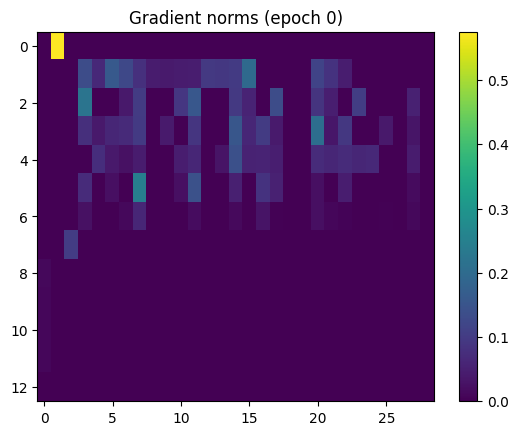

In [235]:
import matplotlib.pyplot as plt

plt.imshow(grad_norm_rnn_name[0], aspect='auto')
plt.colorbar()
plt.title("Gradient norms (epoch 0)")

In [236]:
forb_norm_rnn_name = torch.norm(input=collector_rnn_name.storage, p='fro', dim=(2, 3))

In [237]:
forb_norm_rnn_name

tensor([[5.7517e-01, 4.0747e-01, 3.8357e-01, 3.5878e-01, 2.6132e-01, 3.1968e-01,
         8.4238e-02, 1.0275e-01, 1.1594e-02, 9.3649e-03, 9.9290e-03, 9.3002e-03,
         0.0000e+00],
        [5.2015e-01, 4.2349e-01, 4.6937e-01, 3.3579e-01, 2.5000e-01, 2.5561e-01,
         3.5849e-02, 2.8366e-02, 5.7658e-03, 5.6123e-03, 4.5448e-03, 4.4790e-03,
         0.0000e+00],
        [7.4783e-01, 4.8397e-01, 4.4536e-01, 3.3138e-01, 2.8442e-01, 3.1702e-01,
         3.3904e-02, 1.7693e-02, 5.0407e-03, 4.7721e-03, 3.0613e-03, 3.1938e-03,
         0.0000e+00],
        [7.3113e-01, 4.2655e-01, 4.4977e-01, 3.5324e-01, 3.0947e-01, 3.1906e-01,
         2.2512e-02, 8.2647e-03, 4.6837e-03, 4.7540e-03, 2.4107e-03, 2.6604e-03,
         0.0000e+00],
        [6.4895e-01, 4.6730e-01, 4.8372e-01, 3.9354e-01, 3.0239e-01, 4.2056e-01,
         3.3613e-02, 1.5162e-02, 4.8675e-03, 4.6150e-03, 1.9471e-03, 2.1950e-03,
         0.0000e+00],
        [6.8110e-01, 4.6917e-01, 4.0832e-01, 4.6146e-01, 3.4921e-01, 3.7962e-01,

In [238]:
forb_norm_rnn_name_mean = torch.mean(forb_norm_rnn_name, dim=0).unsqueeze(0)

In [239]:
forb_norm_rnn_name_mean

tensor([[0.9693, 0.6933, 0.6459, 0.6004, 0.4929, 0.4359, 0.0216, 0.0112, 0.0039,
         0.0026, 0.0015, 0.0012, 0.0000]])

Text(0.5, 1.0, 'Gradient norms')

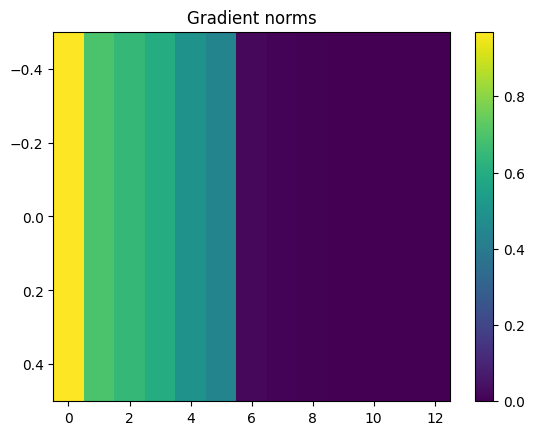

In [240]:
import matplotlib.pyplot as plt

plt.imshow(forb_norm_rnn_name_mean, aspect='auto')
plt.colorbar()
plt.title("Gradient norms")

**LSTM**

In [241]:
lstm_model_testing_name = lstm_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [242]:
loss_fn_1 = nn.CrossEntropyLoss()
loss_fn_2 = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(lstm_model_testing_name.parameters(), lr = 0.025)

In [243]:
epochs = 150
collector_lstm_name = GradCollector(epochs=epochs, max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim)

train = True
grad_collection = True

train_loss_lstm = []
validation_loss_lstm = []

for epoch in range(epochs):
  print(f"Epoch {epoch+1}\n-------------------------------")

  train_loss_lstm.append(fit_and_collect_grads_train_loop_rnn_name(
    model=lstm_model_testing_name, model_type = 'lstm', dataloader=req_train_data_dataloader, collector=collector_lstm_name, optimizer=optimizer,
    loss_fn_1=loss_fn_1, loss_fn_2=loss_fn_2,
    max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim, device=device, train=train, grad_collection=grad_collection))

  #validation_loss_rnn.append(validation_loop_rnn_gen(model=rnn_model_testing, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))

print("Done!")

Epoch 1
-------------------------------
loss: 3.432721  [   32/ 1585]
loss: 0.121484  [  800/ 1585]
loss: 0.027840  [ 1568/ 1585]
Epoch 2
-------------------------------
loss: 0.026424  [   32/ 1585]
loss: 0.009658  [  800/ 1585]
loss: 0.004847  [ 1568/ 1585]
Epoch 3
-------------------------------
loss: 0.004503  [   32/ 1585]
loss: 0.002884  [  800/ 1585]
loss: 0.002075  [ 1568/ 1585]
Epoch 4
-------------------------------
loss: 0.002032  [   32/ 1585]
loss: 0.001594  [  800/ 1585]
loss: 0.001240  [ 1568/ 1585]
Epoch 5
-------------------------------
loss: 0.001220  [   32/ 1585]
loss: 0.000947  [  800/ 1585]
loss: 0.000773  [ 1568/ 1585]
Epoch 6
-------------------------------
loss: 0.000755  [   32/ 1585]
loss: 0.000624  [  800/ 1585]
loss: 0.000562  [ 1568/ 1585]
Epoch 7
-------------------------------
loss: 0.000551  [   32/ 1585]
loss: 0.000477  [  800/ 1585]
loss: 0.000430  [ 1568/ 1585]
Epoch 8
-------------------------------
loss: 0.000423  [   32/ 1585]
loss: 0.000382  [  8

In [244]:
grad_norm_lstm_name = torch.norm(collector_lstm_name.storage, dim=-1, p=2)

In [245]:
grad_norm_lstm_name.shape

torch.Size([150, 13, 29])

Text(0.5, 1.0, 'Gradient norms (epoch 0)')

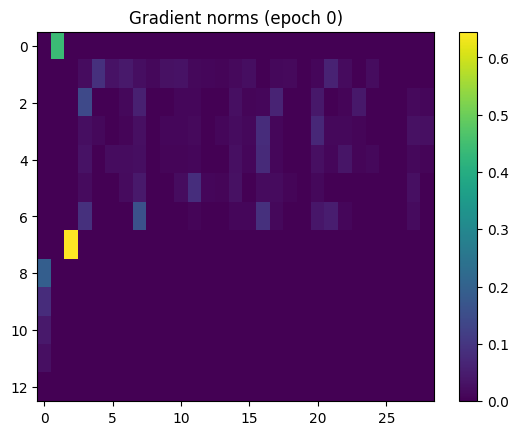

In [246]:
import matplotlib.pyplot as plt

plt.imshow(grad_norm_lstm_name[0], aspect='auto')
plt.colorbar()
plt.title("Gradient norms (epoch 0)")

In [247]:
forb_norm_lstm_name = torch.norm(input=collector_lstm_name.storage, p='fro', dim=(2, 3))

In [248]:
forb_norm_lstm_name

tensor([[4.3853e-01, 1.4273e-01, 1.8111e-01,  ..., 4.3789e-02, 2.5402e-02,
         0.0000e+00],
        [3.7706e-01, 1.3960e-01, 1.5127e-01,  ..., 7.5651e-03, 4.5437e-03,
         0.0000e+00],
        [3.6908e-01, 1.5577e-01, 1.5975e-01,  ..., 3.0426e-03, 1.9835e-03,
         0.0000e+00],
        ...,
        [2.2908e-01, 5.5898e-01, 4.7894e-01,  ..., 1.9650e-04, 1.3856e-04,
         0.0000e+00],
        [2.2166e-01, 5.6940e-01, 5.8954e-01,  ..., 1.8719e-04, 1.3421e-04,
         0.0000e+00],
        [2.4777e-01, 4.9468e-01, 5.2722e-01,  ..., 1.9234e-04, 1.3524e-04,
         0.0000e+00]])

In [249]:
forb_norm_lstm_name_mean = torch.mean(forb_norm_lstm_name, dim=0).unsqueeze(0)

In [250]:
forb_norm_lstm_name_mean

tensor([[3.0293e-01, 4.0447e-01, 4.2543e-01, 4.1241e-01, 3.9332e-01, 3.3125e-01,
         2.6280e-02, 1.6675e-02, 2.7502e-03, 1.0711e-03, 6.0085e-04, 3.7957e-04,
         0.0000e+00]])

Text(0.5, 1.0, 'Gradient norms')

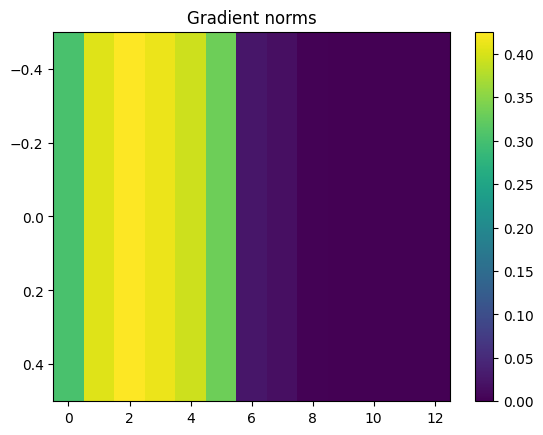

In [251]:
import matplotlib.pyplot as plt

plt.imshow(forb_norm_lstm_name_mean, aspect='auto')
plt.colorbar()
plt.title("Gradient norms")

**GRU**

In [252]:
gru_model_testing_name = gru_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [253]:
loss_fn_1 = nn.CrossEntropyLoss()
loss_fn_2 = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(gru_model_testing_name.parameters(), lr = 0.025)

In [254]:
epochs = 150
collector_gru_name = GradCollector(epochs=epochs, max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim)

train = True
grad_collection = True

train_loss_lstm = []
validation_loss_lstm = []

for epoch in range(epochs):
  print(f"Epoch {epoch+1}\n-------------------------------")

  train_loss_lstm.append(fit_and_collect_grads_train_loop_rnn_name(
    model=gru_model_testing_name, model_type = 'gru', dataloader=req_train_data_dataloader, collector=collector_gru_name, optimizer=optimizer,
    loss_fn_1=loss_fn_1, loss_fn_2=loss_fn_2,
    max_name_length=seq_len, n_tokens=voc_size, embedding_size=in_dim, device=device, train=train, grad_collection=grad_collection))

  #validation_loss_rnn.append(validation_loop_rnn_gen(model=rnn_model_testing, dataloader=validation_dataloader, loss_fn=loss_fn, device=device))

print("Done!")

Epoch 1
-------------------------------
loss: 3.375973  [   32/ 1585]
loss: 0.029320  [  800/ 1585]
loss: 0.005299  [ 1568/ 1585]
Epoch 2
-------------------------------
loss: 0.004892  [   32/ 1585]
loss: 0.001770  [  800/ 1585]
loss: 0.000984  [ 1568/ 1585]
Epoch 3
-------------------------------
loss: 0.000947  [   32/ 1585]
loss: 0.000700  [  800/ 1585]
loss: 0.000631  [ 1568/ 1585]
Epoch 4
-------------------------------
loss: 0.000624  [   32/ 1585]
loss: 0.000641  [  800/ 1585]
loss: 0.000694  [ 1568/ 1585]
Epoch 5
-------------------------------
loss: 0.000691  [   32/ 1585]
loss: 0.000703  [  800/ 1585]
loss: 0.000688  [ 1568/ 1585]
Epoch 6
-------------------------------
loss: 0.000692  [   32/ 1585]
loss: 0.000637  [  800/ 1585]
loss: 0.000603  [ 1568/ 1585]
Epoch 7
-------------------------------
loss: 0.000605  [   32/ 1585]
loss: 0.000453  [  800/ 1585]
loss: 0.000394  [ 1568/ 1585]
Epoch 8
-------------------------------
loss: 0.000343  [   32/ 1585]
loss: 0.000339  [  8

In [255]:
grad_norm_gru_name = torch.norm(collector_gru_name.storage, dim=-1, p=2)

In [256]:
grad_norm_gru_name.shape

torch.Size([150, 13, 29])

Text(0.5, 1.0, 'Gradient norms (epoch 0)')

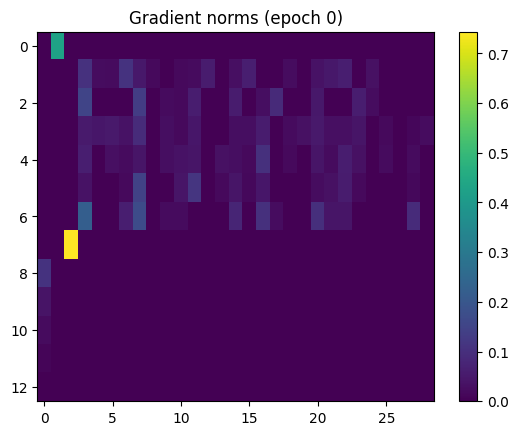

In [257]:
import matplotlib.pyplot as plt

plt.imshow(grad_norm_gru_name[0], aspect='auto')
plt.colorbar()
plt.title("Gradient norms (epoch 0)")

In [258]:
forb_norm_gru_name = torch.norm(input=collector_gru_name.storage, p='fro', dim=(2, 3))

In [259]:
forb_norm_gru_name

tensor([[4.2956e-01, 2.1306e-01, 2.5120e-01,  ..., 2.1165e-02, 1.1500e-02,
         0.0000e+00],
        [3.9036e-01, 2.1774e-01, 2.4953e-01,  ..., 5.4310e-03, 3.0642e-03,
         0.0000e+00],
        [3.4355e-01, 2.1187e-01, 2.9632e-01,  ..., 4.1733e-03, 2.4430e-03,
         0.0000e+00],
        ...,
        [2.0060e-01, 8.4416e-01, 6.1173e-01,  ..., 4.4173e-05, 2.2301e-05,
         0.0000e+00],
        [8.6904e-01, 1.3212e+00, 1.8390e+00,  ..., 4.7611e-05, 2.4350e-05,
         0.0000e+00],
        [3.6470e-01, 5.8513e-01, 6.4933e-01,  ..., 4.5240e-05, 2.3075e-05,
         0.0000e+00]])

In [260]:
forb_norm_gru_name_mean = torch.mean(forb_norm_gru_name, dim=0).unsqueeze(0)

In [261]:
forb_norm_gru_name_mean

tensor([[2.8899e-01, 5.3628e-01, 5.1030e-01, 5.3549e-01, 5.2226e-01, 4.8421e-01,
         3.8747e-02, 1.5114e-02, 2.2296e-03, 8.1996e-04, 4.5684e-04, 2.5296e-04,
         0.0000e+00]])

Text(0.5, 1.0, 'Gradient norms')

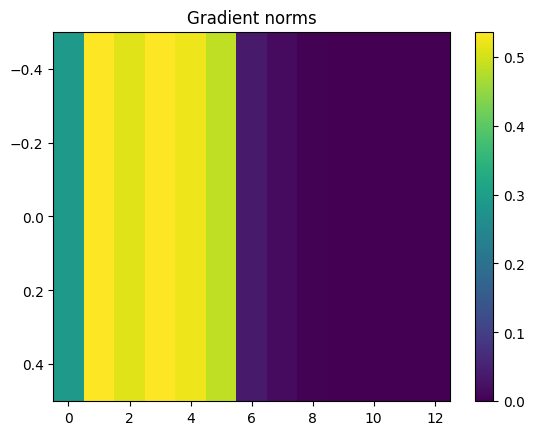

In [262]:
import matplotlib.pyplot as plt

plt.imshow(forb_norm_gru_name_mean, aspect='auto')
plt.colorbar()
plt.title("Gradient norms")

#  **Multitask Learning**

In [263]:
voc_size = 26 + 3
seq_len = 13
in_dim = 128
hidden_dim = 32
out_dim = 1

**LSTM**

In [416]:
def train_loop_lstm_mix(dataloader, model, optimizer_1, optimizer_2, loss_fn_1, loss_fn_2, device) -> None:

    size = len(dataloader.dataset)
    model.train()
    embeds = []
    labels = []
    for batch, (X, y) in enumerate(dataloader):

          X = model.input_transform(X) # ?

          batch_tokens = X

          x_batch = model.embed_matrix[batch_tokens.long()]
          batch_size, seq_len, _ = x_batch.shape

          h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          c = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          current_loss_name = 0.0

          pad_token_id = 0
          validation_steps = 0

          for t in range(seq_len - 1):
              logit, h, c = model.lstm_block(x_batch[:, t, :], h , c)
              target = batch_tokens[:, t + 1].to(torch.long)
              mask = target != pad_token_id

              if mask.any():
                loss_name = loss_fn_1(logit[mask], target[mask])
                current_loss_name = current_loss_name + loss_name
                validation_steps += 1

          _, h, c = model.lstm_block(x_batch[:, -1, :], h , c)

          logit = model.fin_output(h) # (batch_size, out_dim)
          loss_gen = loss_fn_2(logit, y.unsqueeze(1).to(x_batch.device))

          optimizer_1.zero_grad()
          optimizer_2.zero_grad()
          current_loss_name = current_loss_name/validation_steps
          current_loss_name.backward(retain_graph=True)
          loss_gen.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
          optimizer_1.step()
          optimizer_2.step()

          combined_loss = current_loss_name.item() + loss_gen.item()

          if batch % 24 == 0:
            loss_val, current  = combined_loss, batch * dataloader.batch_size + len(X)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")

          current_loss = loss_val

          embeds.append(h)
          labels.append(y)
    H = torch.cat(embeds)
    Y = torch.cat(labels)

    return current_loss, H, Y

def validation_loop_lstm_mix(dataloader, model, loss_fn_1, loss_fn_2, device) -> None:

    size = len(dataloader.dataset)
    model.eval()
    current_loss = 0.0
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
          total_loss = 0.0
          X = model.input_transform(X) # ?

          batch_tokens = X

          x_batch = model.embed_matrix[batch_tokens.long()]
          batch_size, seq_len, _ = x_batch.shape

          h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          c = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          current_loss_name = 0.0

          pad_token_id = 0
          validation_steps = 0

          for t in range(seq_len - 1):
              logit, h, c = model.lstm_block(x_batch[:, t, :], h , c)
              target = batch_tokens[:, t + 1].to(torch.long)
              mask = target != pad_token_id

              if mask.any():
                loss_name = loss_fn_1(logit[mask], target[mask])
                current_loss_name = current_loss_name + loss_name.item()
                validation_steps +=1

          _, h, c = model.lstm_block(x_batch[:, -1, :], h , c)

          logit = model.fin_output(h) # (batch_size, out_dim)
          loss_gen = loss_fn_2(logit, y.unsqueeze(1).to(x_batch.device))

          combined_loss = current_loss_name/validation_steps + loss_gen.item()

          if batch == len(dataloader) - 1:
            print(f"total loss on validation data: {combined_loss:>7f}")

          current_loss = combined_loss

    return current_loss

In [417]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f"Using {device} device")

Using cpu device


In [418]:
custom_ltsm_mix = lstm_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [419]:
loss_fn_1 = nn.CrossEntropyLoss()
loss_fn_2 = nn.BCEWithLogitsLoss()
optimizer_1 = torch.optim.SGD(custom_ltsm_mix.parameters(), lr = 0.01)
optimizer_2 = torch.optim.SGD(custom_ltsm_mix.parameters(), lr = 0.01)

In [420]:
epochs = 175
train_loss_lstm = []
validation_loss_lstm = []

for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    curr_loss , H_lstm, Y_lstm = train_loop_lstm_mix(model=custom_ltsm_mix, dataloader=train_dataloader, optimizer_1=optimizer_1, optimizer_2=optimizer_2, loss_fn_1=loss_fn_1, loss_fn_2=loss_fn_2, device=device)
    train_loss_lstm.append(curr_loss)
    validation_loss_lstm.append(validation_loop_lstm_mix(model=custom_ltsm_mix, dataloader=validation_dataloader, loss_fn_1=loss_fn_1, loss_fn_2=loss_fn_2, device=device))
print("Done!")

Epoch 1
-------------------------------
loss: 4.062384  [   32/ 5425]
loss: 3.964548  [  800/ 5425]
loss: 3.838975  [ 1568/ 5425]
loss: 3.772259  [ 2336/ 5425]
loss: 3.700799  [ 3104/ 5425]
loss: 3.514374  [ 3872/ 5425]
loss: 3.473387  [ 4640/ 5425]
loss: 3.401252  [ 5408/ 5425]
total loss on validation data: 3.585019
Epoch 2
-------------------------------
loss: 3.390533  [   32/ 5425]
loss: 3.291879  [  800/ 5425]
loss: 3.361805  [ 1568/ 5425]
loss: 3.280086  [ 2336/ 5425]
loss: 3.230598  [ 3104/ 5425]
loss: 3.228854  [ 3872/ 5425]
loss: 3.290154  [ 4640/ 5425]
loss: 3.355482  [ 5408/ 5425]
total loss on validation data: 3.230444
Epoch 3
-------------------------------
loss: 3.206963  [   32/ 5425]
loss: 3.244680  [  800/ 5425]
loss: 3.115257  [ 1568/ 5425]
loss: 3.171570  [ 2336/ 5425]
loss: 3.079747  [ 3104/ 5425]
loss: 3.136909  [ 3872/ 5425]
loss: 3.080162  [ 4640/ 5425]
loss: 3.158116  [ 5408/ 5425]
total loss on validation data: 3.459551
Epoch 4
-------------------------------


In [ ]:
torch.save(custom_ltsm_mix.state_dict(), './data/custom_ltsm_mix.pt')

In [ ]:
'''custom_ltsm_mix = lstm_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

custom_ltsm_mix.load_state_dict(torch.load('./data/custom_ltsm_mix.pt'))

custom_ltsm_mix.eval()'''

"custom_ltsm_mix = lstm_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)\n\ncustom_ltsm_mix.load_state_dict(torch.load('/content/custom_ltsm_mix.pt'))\n\ncustom_ltsm_mix.eval()"

In [422]:
losses = pd.DataFrame(columns=['train_loss', 'validation_loss'])

In [423]:
losses['train_loss'] = train_loss_lstm
losses['validation_loss'] = validation_loss_lstm

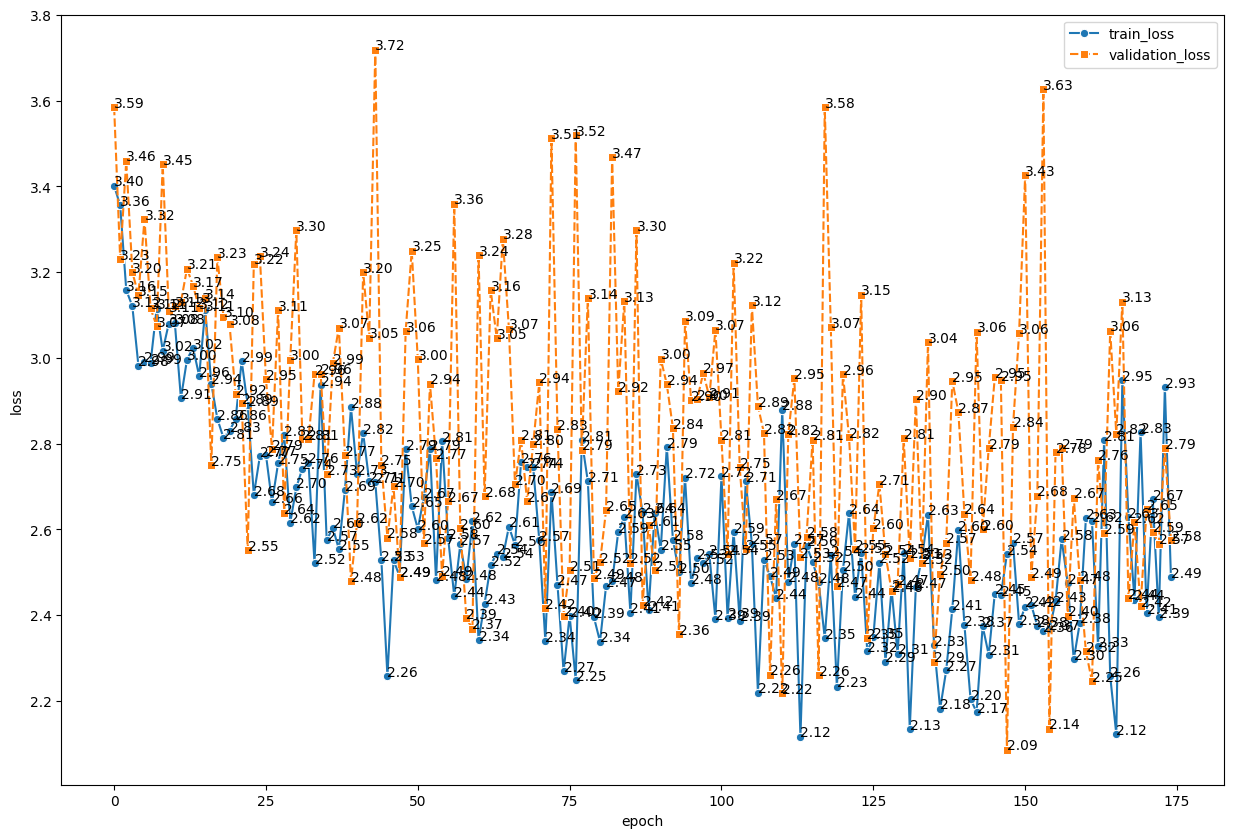

In [425]:
epochs = 175
epochs = np.arange(epochs)
plt.figure(figsize=(15, 10))
ax = sns.lineplot(losses, markers=['o', 's'])
ax.set(xlabel='epoch', ylabel='loss')
for x, y in zip(epochs, losses['validation_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
for x, y in zip(epochs, losses['train_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
plt.show()

In [434]:
names = custom_ltsm_mix.name_gen(name_nums=10, seq_len = 13, beg_sym='a', temperature=0.9)

In [435]:
names

['arte',
 'anka',
 'anmon',
 'alinahe',
 'ad',
 'artain',
 'alda',
 'ardey',
 'anil',
 'alne']

In [436]:
f_logit, h_lstm = custom_ltsm_mix.forward(data_test)

In [437]:
probas = custom_ltsm_mix.predict_proba(f_logit)

In [438]:
roc_auc = roc_auc_score(test_data['gen_code'].values,probas.detach().cpu().numpy())

In [442]:
print(f'{roc_auc:.2f}')

0.91


In [414]:
test_predictions_lstm = pd.DataFrame(probas.detach().cpu().numpy())

In [ ]:
test_predictions_lstm.to_csv('./data/test_predictions_lstm.csv')

**GRU**

In [282]:
voc_size = 26 + 3
seq_len = 13
in_dim = 128
hidden_dim = 16
out_dim = 1

In [283]:
def train_loop_gru_mix(dataloader, model, optimizer_1, optimizer_2, loss_fn_1, loss_fn_2, device) -> None:

    size = len(dataloader.dataset)
    embeds = []
    labels = []
    model.train()
    for batch, (X, y) in enumerate(dataloader):

          X = model.input_transform(X) # ?

          batch_tokens = X

          x_batch = model.embed_matrix[batch_tokens.long()]
          batch_size, seq_len, _ = x_batch.shape

          h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          current_loss_name = 0.0

          pad_token_id = 0
          validation_steps = 0

          for t in range(seq_len - 1):
              logit, h = model.gru_block(x_batch[:, t, :], h)
              target = batch_tokens[:, t + 1].to(torch.long)
              mask = target != pad_token_id

              if mask.any():
                loss_name = loss_fn_1(logit[mask], target[mask])
                current_loss_name = current_loss_name + loss_name
                validation_steps+=1

          _, h = model.gru_block(x_batch[:, -1, :], h)

          logit = model.fin_output(h) # (batch_size, out_dim)
          loss_gen = loss_fn_2(logit, y.unsqueeze(1).to(x_batch.device))

          optimizer_1.zero_grad()
          optimizer_2.zero_grad()
          current_loss_name = current_loss_name/validation_steps
          current_loss_name.backward(retain_graph=True)
          loss_gen.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
          optimizer_1.step()
          optimizer_2.step()

          combined_loss = current_loss_name.item() + loss_gen.item()

          if batch % 24 == 0:
            loss_val, current  = combined_loss, batch * dataloader.batch_size + len(X)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")

          current_loss = loss_val

          embeds.append(h)
          labels.append(y)
    H = torch.cat(embeds)
    Y = torch.cat(labels)

    return current_loss, H, Y

def validation_loop_gru_mix(dataloader, model, loss_fn_1, loss_fn_2, device) -> None:

    size = len(dataloader.dataset)
    model.eval()
    current_loss = 0.0
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
          total_loss = 0.0
          X = model.input_transform(X) # ?

          batch_tokens = X

          x_batch = model.embed_matrix[batch_tokens.long()]
          batch_size, seq_len, _ = x_batch.shape

          h = torch.zeros(batch_size, model.hidden_dim, dtype=x_batch.dtype, device=x_batch.device)
          current_loss_name = 0.0

          pad_token_id = 0
          validation_steps = 0

          for t in range(seq_len - 1):
              logit, h = model.gru_block(x_batch[:, t, :], h)
              target = batch_tokens[:, t + 1].to(torch.long)
              mask = target != pad_token_id

              if mask.any():
                loss_name = loss_fn_1(logit[mask], target[mask])
                current_loss_name = current_loss_name + loss_name.item()
                validation_steps+=1

          _, h = model.gru_block(x_batch[:, -1, :], h)

          logit = model.fin_output(h) # (batch_size, out_dim)
          loss_gen = loss_fn_2(logit, y.unsqueeze(1).to(x_batch.device))

          combined_loss = current_loss_name/validation_steps + loss_gen.item()

          if batch == len(dataloader) - 1:
            print(f"total loss on validation data: {combined_loss:>7f}")

          current_loss = combined_loss

    return current_loss

In [284]:
custom_gru_mix = gru_custom(voc_size, in_dim, hidden_dim, out_dim, device=device, random_state=21)

In [285]:
loss_fn_1 = nn.CrossEntropyLoss()
loss_fn_2 = nn.BCEWithLogitsLoss()
optimizer_1 = torch.optim.SGD(custom_gru_mix.parameters(), lr = 0.01)
optimizer_2 = torch.optim.SGD(custom_gru_mix.parameters(), lr = 0.01)

In [286]:
epochs = 125
train_loss_gru = []
validation_loss_gru = []

for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    curr_loss , H_gru, Y_gru = train_loop_gru_mix(model=custom_gru_mix, dataloader=train_dataloader, optimizer_1=optimizer_1, optimizer_2=optimizer_2, loss_fn_1=loss_fn_1, loss_fn_2=loss_fn_2, device=device)
    train_loss_gru.append(curr_loss)
    validation_loss_gru.append(validation_loop_gru_mix(model=custom_gru_mix, dataloader=validation_dataloader, loss_fn_1=loss_fn_1, loss_fn_2=loss_fn_2, device=device))
print("Done!")

Epoch 1
-------------------------------
loss: 4.075308  [   32/ 5425]
loss: 3.994080  [  800/ 5425]
loss: 3.910283  [ 1568/ 5425]
loss: 3.817754  [ 2336/ 5425]
loss: 3.738120  [ 3104/ 5425]
loss: 3.666749  [ 3872/ 5425]
loss: 3.573356  [ 4640/ 5425]
loss: 3.497426  [ 5408/ 5425]
total loss on validation data: 3.611165
Epoch 2
-------------------------------
loss: 3.514154  [   32/ 5425]
loss: 3.462720  [  800/ 5425]
loss: 3.356212  [ 1568/ 5425]
loss: 3.368678  [ 2336/ 5425]
loss: 3.296783  [ 3104/ 5425]
loss: 3.312011  [ 3872/ 5425]
loss: 3.306729  [ 4640/ 5425]
loss: 3.235339  [ 5408/ 5425]
total loss on validation data: 3.252813
Epoch 3
-------------------------------
loss: 3.197685  [   32/ 5425]
loss: 3.198578  [  800/ 5425]
loss: 3.235417  [ 1568/ 5425]
loss: 3.288163  [ 2336/ 5425]
loss: 3.186368  [ 3104/ 5425]
loss: 3.231430  [ 3872/ 5425]
loss: 3.202223  [ 4640/ 5425]
loss: 3.212382  [ 5408/ 5425]
total loss on validation data: 3.483309
Epoch 4
-------------------------------


In [ ]:
torch.save(custom_gru_mix.state_dict(), './data/custom_gru_mix.pt')

In [288]:
losses = pd.DataFrame(columns=['train_loss', 'validation_loss'])

In [289]:
losses['train_loss'] = train_loss_gru
losses['validation_loss'] = validation_loss_gru

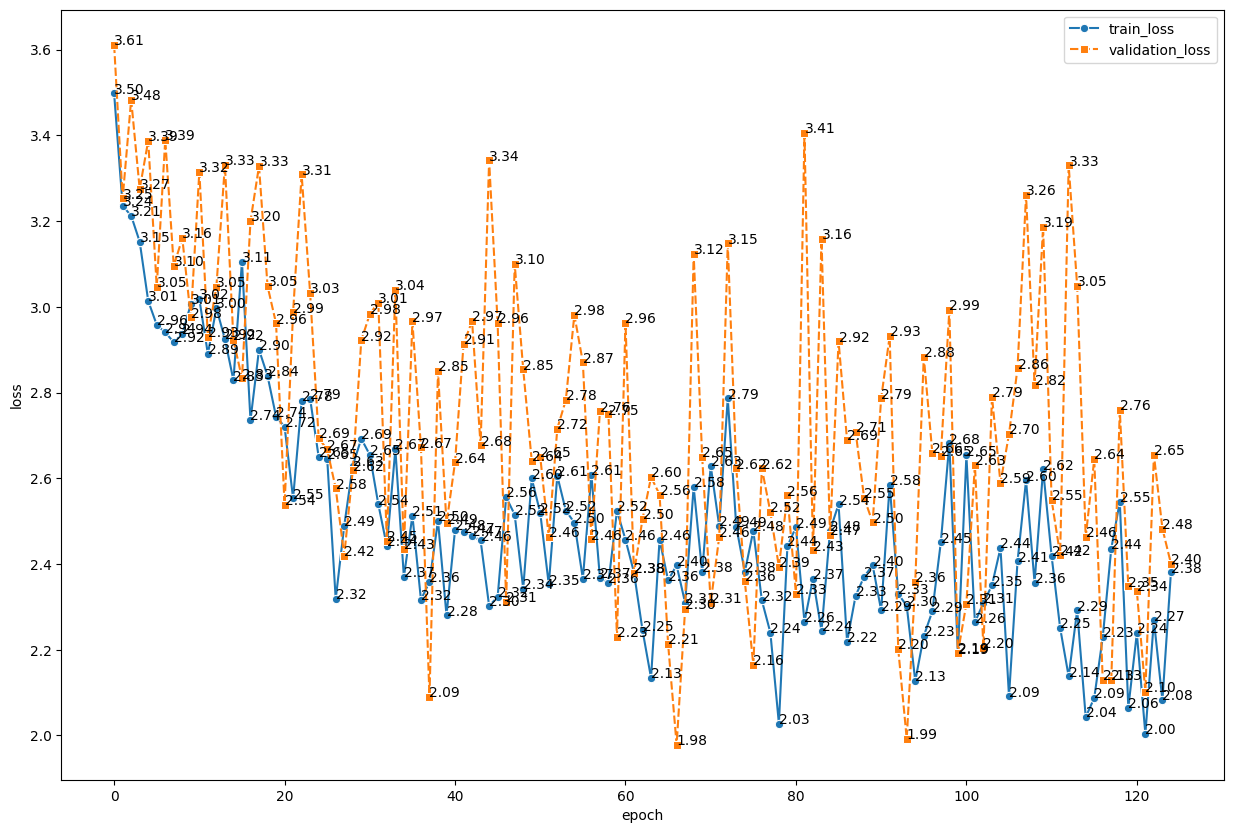

In [290]:
epochs = 125
epochs = np.arange(epochs)
plt.figure(figsize=(15, 10))
ax = sns.lineplot(losses, markers=['o', 's'])
ax.set(xlabel='epoch', ylabel='loss')
for x, y in zip(epochs, losses['validation_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
for x, y in zip(epochs, losses['train_loss']):
    ax.text(x, y, f'{y:.2f}', color='black')
plt.show()

In [291]:
names = custom_gru_mix.name_gen(name_nums=10, seq_len = 13, beg_sym='r', temperature=0.9)

In [292]:
names

['rab',
 'riiny',
 'rarzin',
 'ronneu',
 'rovia',
 'rien',
 'reskw',
 'rirtne',
 'rana',
 'ronne']

In [293]:
f_logit, h_gru = custom_gru_mix.forward(data_test)

In [294]:
probas = custom_gru_mix.predict_proba(f_logit)

In [295]:
roc_auc = roc_auc_score(test_data['gen_code'].values,probas.detach().cpu().numpy())

In [296]:
print(f'{roc_auc:.2f}')

0.92


In [297]:
test_predictions_gru= pd.DataFrame(probas.detach().cpu().numpy())

In [ ]:
test_predictions_gru.to_csv('./data/test_predictions_gru.csv')

# **Visualizing embeddings**

In [299]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

**Get the embeddings of each letter from the model with multitask loss**

In [300]:
import numpy as np

In [301]:
alphabet = np.array(list('abcdefghijklmnopqrstuvwxyz'))

In [302]:
vowels = np.array(list('aeiouy'))

In [303]:
vowels_ids = [tokens_to_id[letter] for letter in vowels]

In [304]:
consonants = np.array(list('bcdfghjklmnpqrstvwxz'))

In [305]:
consonants_ids = [tokens_to_id[letter] for letter in consonants]

In [306]:
tokens = tokens_to_id.keys()

In [307]:
vowels = set(['a','e','i','o','u', 'y'])
is_vowel = np.array([t in vowels for t in tokens])

In [308]:
lstsm_embed = custom_ltsm_mix.embed_matrix.detach().cpu().numpy()

In [309]:
lstsm_embed.shape

(29, 128)

In [310]:
lstsm_embed = StandardScaler().fit_transform(lstsm_embed)

In [311]:
gru_embed = custom_gru_mix.embed_matrix.detach().cpu().numpy()

In [312]:
gru_embed = StandardScaler().fit_transform(gru_embed)

**PCA**

In [313]:
lstsm_embed_pca = PCA(n_components=2).fit_transform(lstsm_embed)

In [314]:
gru_embed_pca = PCA(n_components=2).fit_transform(gru_embed)

**TSNE**

In [315]:
lstsm_embed_tsne = TSNE(
    n_components=2,
    perplexity=5,
    init="pca",
    random_state=21
).fit_transform(lstsm_embed)

In [316]:
gru_embed_tsne = TSNE(
    n_components=2,
    perplexity=5,
    init="pca",
    random_state=21
).fit_transform(gru_embed)

In [317]:
is_vowel.shape

(29,)

**scatterplot to visualize**

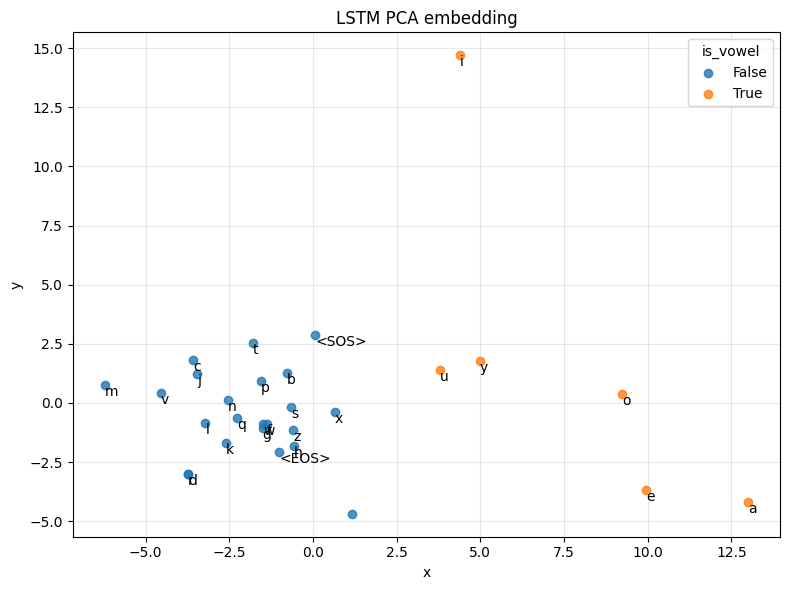

In [318]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

lstsm_embed_pca_consonants = lstsm_embed_pca[~is_vowel]
lstsm_embed_pca_vowels = lstsm_embed_pca[is_vowel]

plt.scatter(lstsm_embed_pca_consonants[:, 0], lstsm_embed_pca_consonants[:, 1],
            label='False', alpha=0.8)

plt.scatter(lstsm_embed_pca_vowels[:, 0], lstsm_embed_pca_vowels[:, 1],
            label='True', alpha=0.8)

for i, token in enumerate(tokens):
    plt.text(lstsm_embed_pca[i, 0], lstsm_embed_pca[i, 1], token,
             fontsize=10,
             ha='left',
             va='top')

plt.xlabel('x')
plt.ylabel('y')
plt.legend(title='is_vowel')
plt.title("LSTM PCA embedding")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

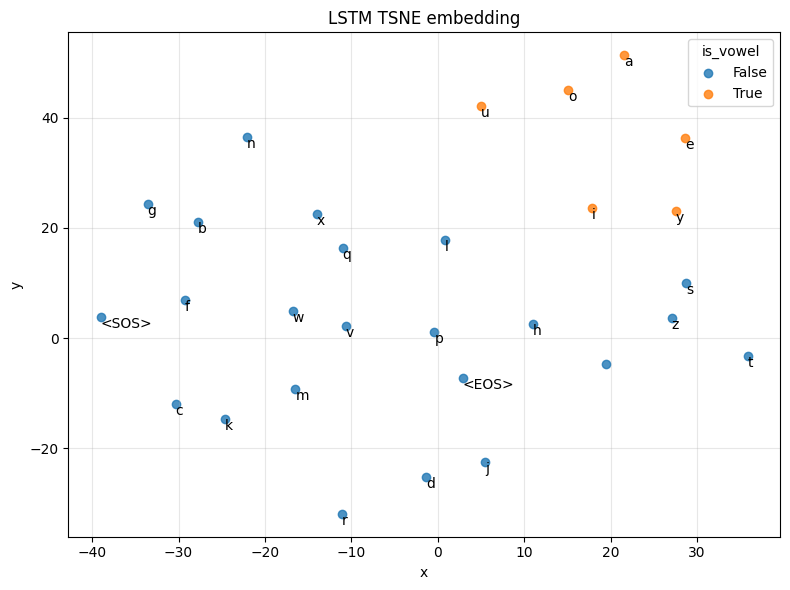

In [319]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

lstsm_embed_tsne_consonants = lstsm_embed_tsne[~is_vowel]
lstsm_embed_tsne_vowels = lstsm_embed_tsne[is_vowel]

plt.scatter(lstsm_embed_tsne_consonants[:, 0], lstsm_embed_tsne_consonants[:, 1],
            label='False', alpha=0.8)

plt.scatter(lstsm_embed_tsne_vowels[:, 0], lstsm_embed_tsne_vowels[:, 1],
            label='True', alpha=0.8)

for i, token in enumerate(tokens):
    plt.text(lstsm_embed_tsne[i, 0], lstsm_embed_tsne[i, 1], token,
             fontsize=10,
             ha='left',
             va='top')

plt.xlabel('x')
plt.ylabel('y')
plt.legend(title='is_vowel')
plt.title("LSTM TSNE embedding")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

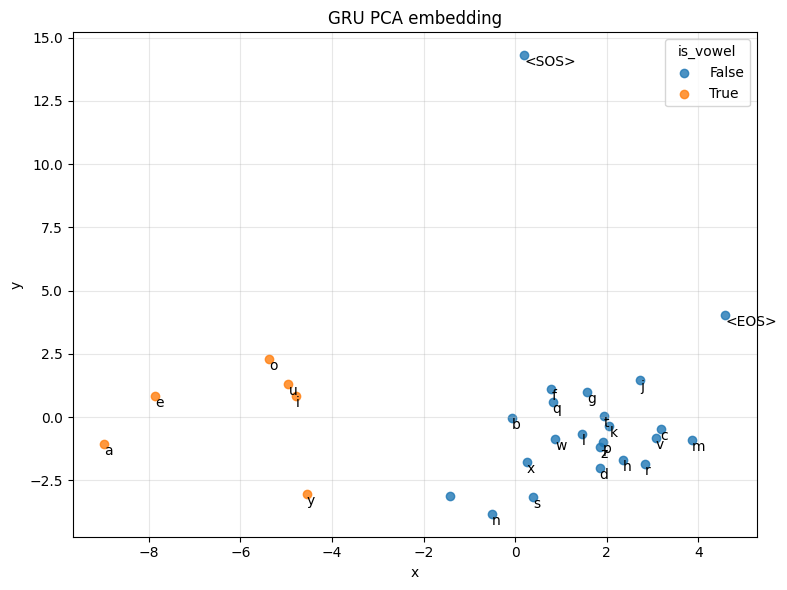

In [320]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

gru_embed_pca_consonants = gru_embed_pca[~is_vowel]
gru_embed_pca_vowels = gru_embed_pca[is_vowel]

plt.scatter(gru_embed_pca_consonants[:, 0], gru_embed_pca_consonants[:, 1],
            label='False', alpha=0.8)

plt.scatter(gru_embed_pca_vowels[:, 0], gru_embed_pca_vowels[:, 1],
            label='True', alpha=0.8)

for i, token in enumerate(tokens):
    plt.text(gru_embed_pca[i, 0], gru_embed_pca[i, 1], token,
             fontsize=10,
             ha='left',
             va='top')

plt.xlabel('x')
plt.ylabel('y')
plt.legend(title='is_vowel')
plt.title("GRU PCA embedding")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

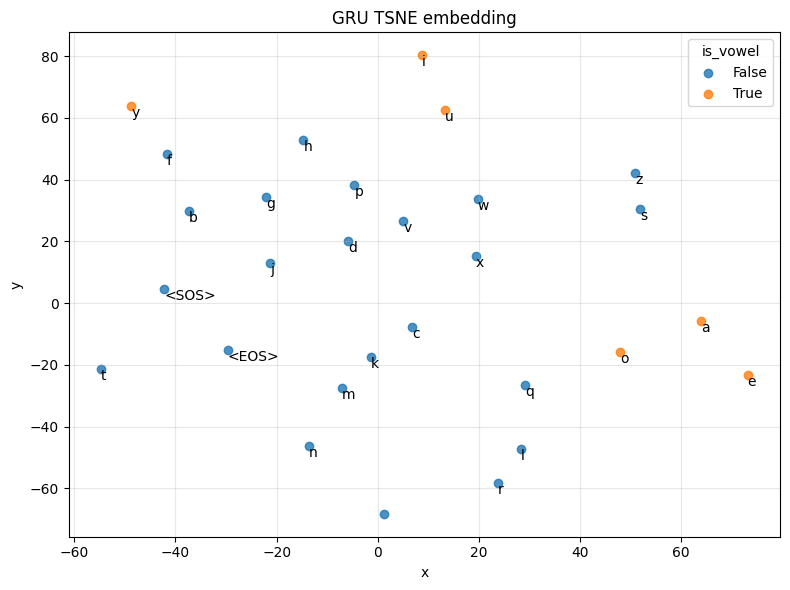

In [321]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

gru_embed_tsne_consonants = gru_embed_tsne[~is_vowel]
gru_embed_tsne_vowels = gru_embed_tsne[is_vowel]

plt.scatter(gru_embed_tsne_consonants[:, 0], gru_embed_tsne_consonants[:, 1],
            label='False', alpha=0.8)

plt.scatter(gru_embed_tsne_vowels[:, 0], gru_embed_tsne_vowels[:, 1],
            label='True', alpha=0.8)

for i, token in enumerate(tokens):
    plt.text(gru_embed_tsne[i, 0], gru_embed_tsne[i, 1], token,
             fontsize=10,
             ha='left',
             va='top')

plt.xlabel('x')
plt.ylabel('y')
plt.legend(title='is_vowel')
plt.title("GRU TSNE embedding")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **Bonus Part**

In [322]:
H_lstm_pca = PCA(n_components=2).fit_transform(H_lstm.detach().cpu().numpy())
H_gru_pca = PCA(n_components=2).fit_transform(H_gru.detach().cpu().numpy())
Y_lstm = Y_lstm.detach().cpu().numpy()
Y_gru = Y_gru.detach().cpu().numpy()

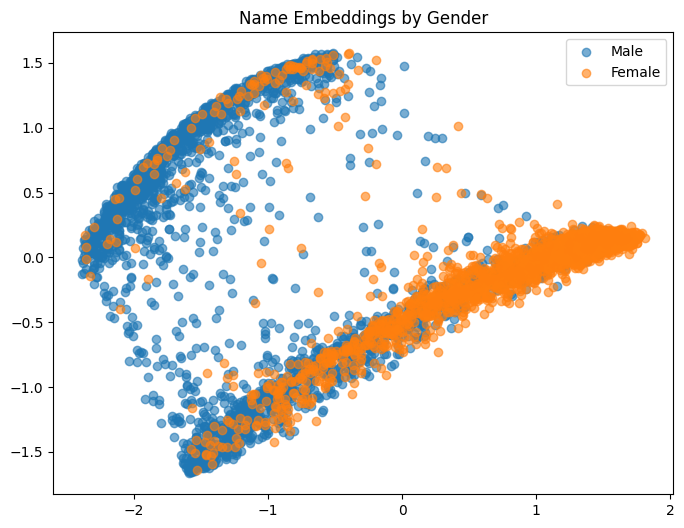

In [323]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(H_lstm_pca[Y_lstm == 0, 0], H_lstm_pca[Y_lstm == 0, 1], label="Male", alpha=0.6)
plt.scatter(H_lstm_pca[Y_lstm == 1, 0], H_lstm_pca[Y_lstm == 1, 1], label="Female", alpha=0.6)

plt.legend()
plt.title("Name Embeddings by Gender")
plt.show()

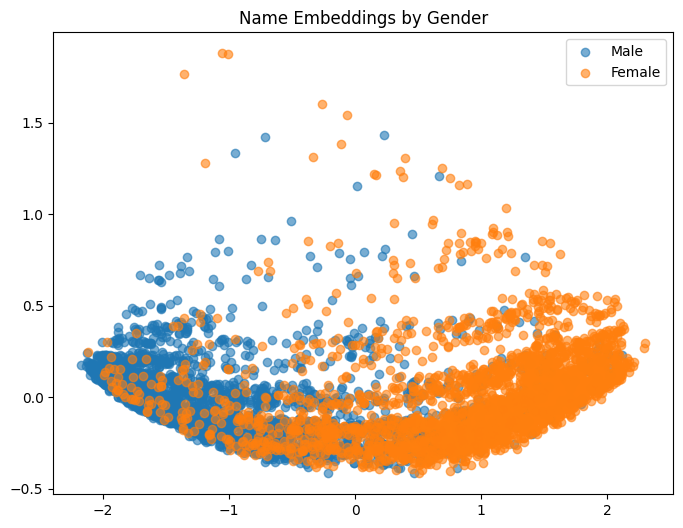

In [324]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(H_gru_pca[Y_gru == 0, 0], H_gru_pca[Y_gru == 0, 1], label="Male", alpha=0.6)
plt.scatter(H_gru_pca[Y_gru == 1, 0], H_gru_pca[Y_gru == 1, 1], label="Female", alpha=0.6)

plt.legend()
plt.title("Name Embeddings by Gender")
plt.show()

**GBDT LSTM**

In [325]:
from lightgbm import LGBMClassifier

clf_lstm = LGBMClassifier(
    n_estimators=200,
    max_depth=-1,
    learning_rate=0.05
)

clf_lstm.fit(H_lstm.detach().cpu().numpy(), Y_lstm)

[LightGBM] [Info] Number of positive: 2773, number of negative: 2652
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8160
[LightGBM] [Info] Number of data points in the train set: 5425, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.511152 -> initscore=0.044616
[LightGBM] [Info] Start training from score 0.044616


LGBMClassifier(learning_rate=0.05, n_estimators=200)

In [326]:
# add returning final h for forward method. It is necessary for gbdt

In [327]:
logit, h_lstm = custom_ltsm_mix.forward(data_test)

In [328]:
probs = clf_lstm.predict_proba(h_lstm.detach().cpu().numpy())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [329]:
probs_positive = probs[:, 1]

In [330]:
roc_auc_lstm = roc_auc_score(test_data['gen_code'].values, probs_positive)

In [331]:
print(f'{roc_auc_lstm:.2f}')

0.90


**GBDT GRU**

In [332]:
clf_gru = LGBMClassifier(
    n_estimators=200,
    max_depth=-1,
    learning_rate=0.05
)

clf_gru.fit(H_gru.detach().cpu().numpy(), Y_gru)

[LightGBM] [Info] Number of positive: 2773, number of negative: 2652
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4080
[LightGBM] [Info] Number of data points in the train set: 5425, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.511152 -> initscore=0.044616
[LightGBM] [Info] Start training from score 0.044616


LGBMClassifier(learning_rate=0.05, n_estimators=200)

In [333]:
logit, h_gru = custom_gru_mix.forward(data_test)

In [334]:
probs = clf_gru.predict_proba(h_gru.detach().cpu().numpy())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [335]:
probs_positive = probs[:, 1]

In [336]:
roc_auc_gru = roc_auc_score(test_data['gen_code'].values, probs_positive)

In [337]:
print(f'{roc_auc_gru:.2f}')

0.91


### **torch RNN, LSTM, GRU**

In [338]:
class MultiTaskRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.gen_head = nn.Linear(hidden_dim, vocab_size) # for name generation
        self.cls_head = nn.Linear(hidden_dim, 1) # for gender classification

    def forward(self, x):
        emb = self.embedding(x)
        out, h_n = self.rnn(emb)
        gen_logits = self.gen_head(out)
        cls_logits = self.cls_head(h_n[-1])
        return gen_logits, cls_logits


    def predict_proba(self, x):
        return torch.sigmoid(x)

In [339]:
voc_size = 26 + 3
seq_len = 13
in_dim = 128
hidden_dim = 64
out_dim = 1

In [340]:
rnn_classifier = MultiTaskRNN(vocab_size=voc_size, embed_dim=voc_size, hidden_dim=hidden_dim)

In [341]:
loss_fn_1 = nn.BCEWithLogitsLoss()
loss_fn_2 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(rnn_classifier.parameters(), lr = 0.001)
optimizer_2 = torch.optim.Adam(rnn_classifier.parameters(), lr = 0.001)

In [342]:
def train_loop_rnn_classifier(model, loss_fn_1, loss_fn_2, optimizer_1, optimizer_2, dataloader):

  for batch, (x, y) in enumerate(dataloader):
      batch_tokens = x
      logits_name, logits_gender = model(x.to(torch.long))
      gender_loss = loss_fn_1(logits_gender, y.unsqueeze(1))
      name_loss = loss_fn_2(logits_name[:, :-1, :].reshape(-1, model.vocab_size), batch_tokens[:, 1:].to(torch.long).reshape(-1))

      optimizer_1.zero_grad()
      optimizer_2.zero_grad()
      gender_loss.backward(retain_graph=True)
      name_loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
      optimizer_1.step()
      optimizer_2.step()

      total_loss = gender_loss.item() + name_loss.item()

      return total_loss

In [343]:
epochs = 1000

train_losses = []

for epoch in range(epochs):
  train_losses.append(train_loop_rnn_classifier(rnn_classifier, loss_fn_1, loss_fn_2, optimizer_1, optimizer_2, train_dataloader))


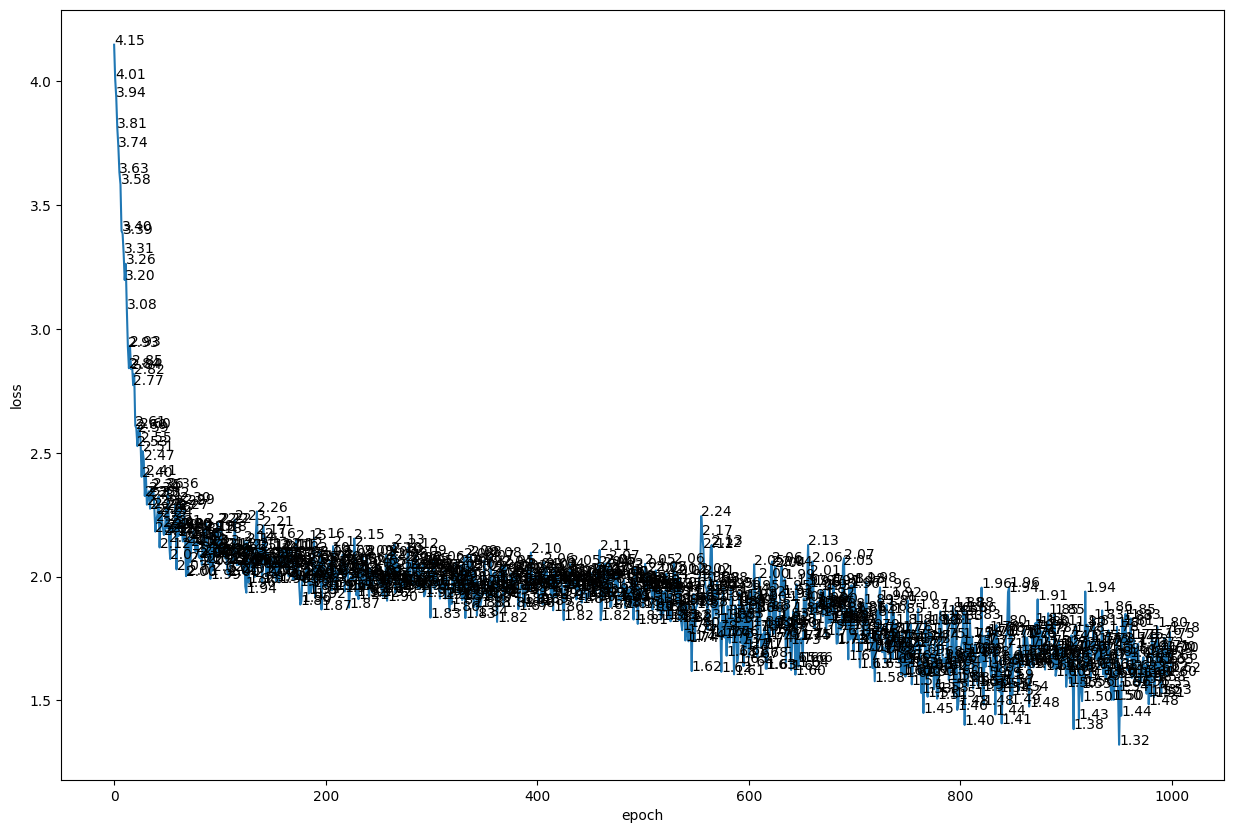

In [344]:
epochs = 1000
epochs = np.arange(epochs)
plt.figure(figsize=(15, 10))
ax = sns.lineplot(train_losses, markers=['o', 's'])
ax.set(xlabel='epoch', ylabel='loss')
for x, y in zip(epochs, train_losses):
    ax.text(x, y, f'{y:.2f}', color='black')
plt.show()

In [345]:
_, class_logits = rnn_classifier(data_test)

In [346]:
probas = rnn_classifier.predict_proba(class_logits)

In [347]:
roc_auc = roc_auc_score(test_data['gen_code'].values,probas.detach().cpu().numpy())

In [348]:
roc_auc

np.float64(0.8927905395984385)

**LSTM**

In [349]:
class MultiTaskLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.gen_head = nn.Linear(hidden_dim, vocab_size) # for name generation
        self.cls_head = nn.Linear(hidden_dim, 1) # for gender classification

    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        gen_logits = self.gen_head(out)
        cls_logits = self.cls_head(h_n[-1])
        return gen_logits, cls_logits


    def predict_proba(self, x):
        return torch.sigmoid(x)

In [350]:
voc_size = 26 + 3
seq_len = 13
in_dim = 128
hidden_dim = 64
out_dim = 1

In [351]:
lstm_classifier = MultiTaskLSTM(vocab_size=voc_size, embed_dim=voc_size, hidden_dim=hidden_dim)

In [352]:
loss_fn_1 = nn.BCEWithLogitsLoss()
loss_fn_2 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(lstm_classifier.parameters(), lr = 0.001)
optimizer_2 = torch.optim.Adam(lstm_classifier.parameters(), lr = 0.001)

In [353]:
def train_loop_lstm_classifier(model, loss_fn_1, loss_fn_2, optimizer_1, optimizer_2, dataloader):

  for batch, (x, y) in enumerate(dataloader):
      batch_tokens = x
      logits_name, logits_gender = model(x.to(torch.long))
      gender_loss = loss_fn_1(logits_gender, y.unsqueeze(1))
      name_loss = loss_fn_2(logits_name[:, :-1, :].reshape(-1, model.vocab_size), batch_tokens[:, 1:].to(torch.long).reshape(-1))

      optimizer_1.zero_grad()
      optimizer_2.zero_grad()
      gender_loss.backward(retain_graph=True)
      name_loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
      optimizer_1.step()
      optimizer_2.step()

      total_loss = gender_loss.item() + name_loss.item()

      return total_loss

In [354]:
epochs = 1000

train_losses = []

for epoch in range(epochs):
  train_losses.append(train_loop_lstm_classifier(lstm_classifier, loss_fn_1, loss_fn_2, optimizer_1, optimizer_2, train_dataloader))


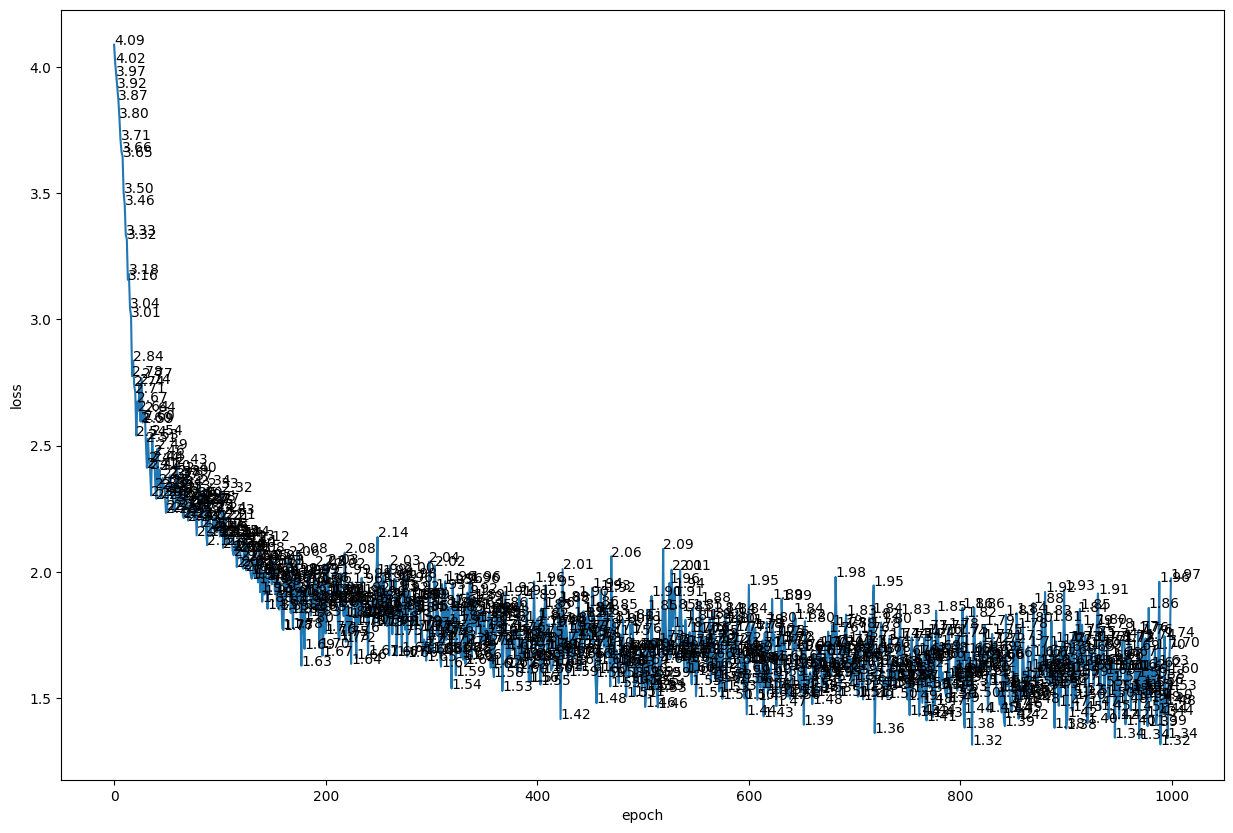

In [355]:
epochs = 1000
epochs = np.arange(epochs)
plt.figure(figsize=(15, 10))
ax = sns.lineplot(train_losses, markers=['o', 's'])
ax.set(xlabel='epoch', ylabel='loss')
for x, y in zip(epochs, train_losses):
    ax.text(x, y, f'{y:.2f}', color='black')
plt.show()

In [356]:
_, class_logits = lstm_classifier(data_test)

In [357]:
probas = lstm_classifier.predict_proba(class_logits)

In [358]:
roc_auc = roc_auc_score(test_data['gen_code'].values,probas.detach().cpu().numpy())

In [359]:
roc_auc

np.float64(0.9055920593976576)

**GRU**

In [360]:
class MultiTaskGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.gen_head = nn.Linear(hidden_dim, vocab_size) # for name generation
        self.cls_head = nn.Linear(hidden_dim, 1) # for gender classification

    def forward(self, x):
        emb = self.embedding(x)
        out, h_n = self.gru(emb)
        gen_logits = self.gen_head(out)
        cls_logits = self.cls_head(h_n[-1])
        return gen_logits, cls_logits


    def predict_proba(self, x):
        return torch.sigmoid(x)

In [361]:
voc_size = 26 + 3
seq_len = 13
in_dim = 128
hidden_dim = 64
out_dim = 1

In [362]:
gru_classifier = MultiTaskGRU(vocab_size=voc_size, embed_dim=voc_size, hidden_dim=hidden_dim)

In [363]:
loss_fn_1 = nn.BCEWithLogitsLoss()
loss_fn_2 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(gru_classifier.parameters(), lr = 0.001)
optimizer_2 = torch.optim.Adam(gru_classifier.parameters(), lr = 0.001)

In [364]:
def train_loop_gru_classifier(model, loss_fn_1, loss_fn_2, optimizer_1, optimizer_2, dataloader):

  for batch, (x, y) in enumerate(dataloader):
      batch_tokens = x
      logits_name, logits_gender = model(x.to(torch.long))
      gender_loss = loss_fn_1(logits_gender, y.unsqueeze(1))
      name_loss = loss_fn_2(logits_name[:, :-1, :].reshape(-1, model.vocab_size), batch_tokens[:, 1:].to(torch.long).reshape(-1))

      optimizer_1.zero_grad()
      optimizer_2.zero_grad()
      gender_loss.backward(retain_graph=True)
      name_loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
      optimizer_1.step()
      optimizer_2.step()

      total_loss = gender_loss.item() + name_loss.item()

      return total_loss

In [365]:
epochs = 1000

train_losses = []

for epoch in range(epochs):
  train_losses.append(train_loop_gru_classifier(gru_classifier, loss_fn_1, loss_fn_2, optimizer_1, optimizer_2, train_dataloader))


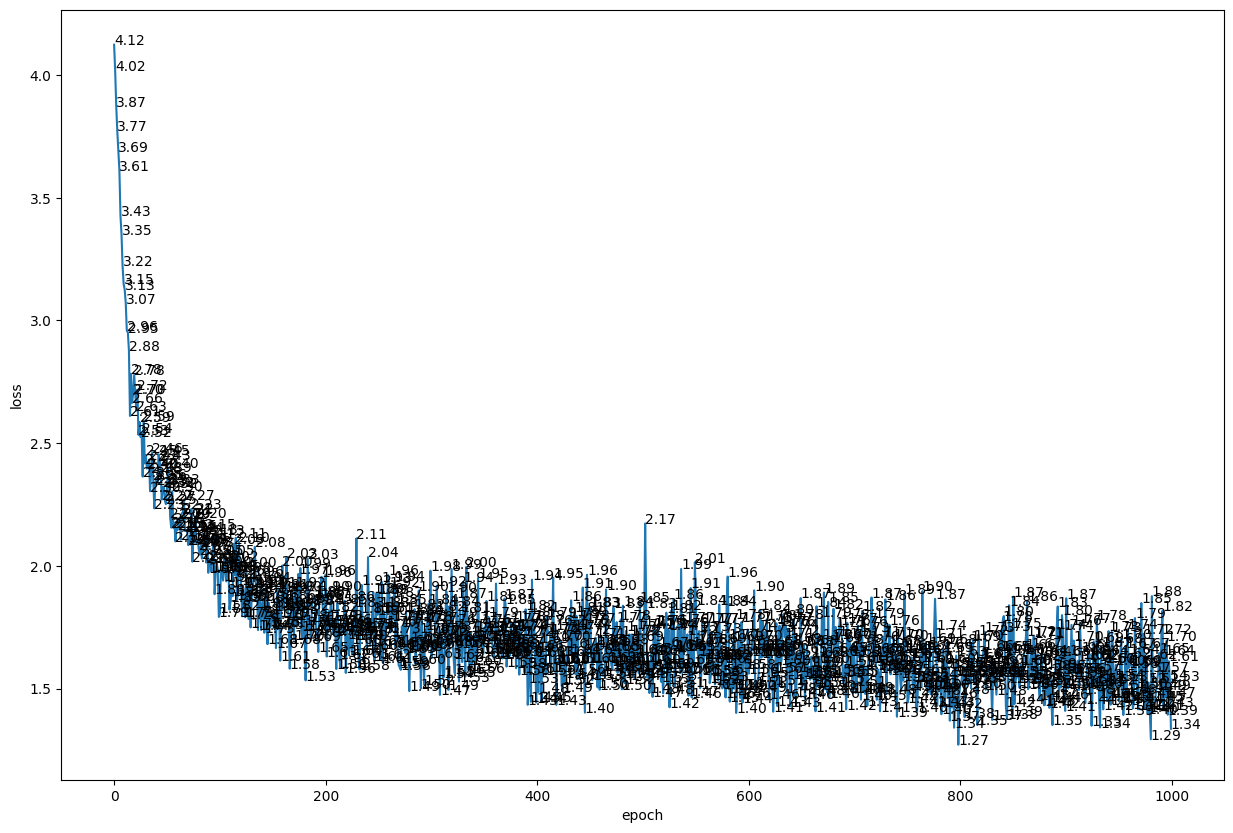

In [366]:
epochs = 1000
epochs = np.arange(epochs)
plt.figure(figsize=(15, 10))
ax = sns.lineplot(train_losses, markers=['o', 's'])
ax.set(xlabel='epoch', ylabel='loss')
for x, y in zip(epochs, train_losses):
    ax.text(x, y, f'{y:.2f}', color='black')
plt.show()

In [367]:
_, class_logits = gru_classifier(data_test)

In [368]:
probas = gru_classifier.predict_proba(class_logits)

In [369]:
roc_auc = roc_auc_score(test_data['gen_code'].values,probas.detach().cpu().numpy())

In [370]:
roc_auc

np.float64(0.9186680842163971)